# 08 Recommendation System - Personalized Recommendation System

## Project Overview

This project builds a personalized recommendation system for an e-commerce platform by combining collaborative filtering and content-based recommendation methods. The system is designed not only to suggest relevant products, but also to support broader business goals such as retention improvement, value growth, and more efficient product exposure.

Unlike a single-algorithm recommendation pipeline, this project develops a hybrid strategy that adapts to different user conditions. It integrates historical interactions, product attributes, user segmentation, churn risk, and predicted customer lifetime value to generate more context-aware recommendations.

## Project Objectives

The main objectives of this project are:

- Build a **user-item rating matrix** using both explicit and implicit feedback
- Implement three recommendation approaches:
  - **User-Based Collaborative Filtering**
  - **Item-Based Collaborative Filtering**
  - **Content-Based Recommendation**
- Design a **hybrid recommendation strategy** for different user types
- Integrate **RFM segmentation**, **churn prediction**, and **CLV prediction**
- Evaluate recommendation quality using offline ranking metrics
- Estimate the potential **business impact** of the recommendation system

## Business Value

A recommendation system can improve the relevance of product exposure and reduce the gap between user demand and platform supply. In business terms, this may contribute to higher click-through rates, better conversion efficiency, stronger repeat purchase behavior, and more balanced traffic allocation across products.

More importantly, recommendation should not be treated as a purely technical ranking problem. Different users carry different business meanings. A high-value user, a churn-risk user, and a cold-start user may require different recommendation logic. This project therefore frames recommendation as both a **modeling task** and a **decision-support task**.

## Technical Challenges

This project addresses several common challenges in recommendation modeling:

- **Data sparsity** in the user-item interaction matrix
- **Cold-start problems** for new users and new products
- The trade-off between **accuracy** and **diversity**
- The limitation of relying on a **single recommendation method**
- The difficulty of aligning algorithm outputs with **business strategy**

These challenges motivate the use of a hybrid recommendation framework rather than a static recommendation pipeline.

## Key Outputs

The final outputs of this project include:

- User-item rating matrix
- User similarity matrix
- Item similarity matrix
- Content feature matrix
- Recommendation results from different algorithms
- Hybrid and personalized recommendation outputs
- Offline evaluation results
- Recommendation analysis visualizations
- Business impact estimation

## Project Position in the Full Analytics System

This project extends the machine learning layer of the broader e-commerce analytics framework. It follows previous modules on user segmentation, churn prediction, and CLV prediction, and transforms those analytical outputs into actionable recommendation decisions.

In this sense, the recommendation system is not an isolated model. It is part of a larger customer intelligence workflow that connects descriptive analysis, predictive modeling, and business intervention.

# 1. Project Overview and Data Preparation

This chapter introduces the recommendation problem and prepares the data foundation for later modeling. In e-commerce, recommendation is not only a ranking task, but also a business decision task, because different users may require different recommendation strategies.

This project builds a recommendation system by combining **User-Based Collaborative Filtering**, **Item-Based Collaborative Filtering**, and **Content-Based Recommendation**. A hybrid strategy is used to better handle **user heterogeneity**, **data sparsity**, and **cold-start scenarios**.

The main objectives of this project are:

- Build a **user-item rating matrix** from explicit and implicit feedback
- Implement and compare three recommendation algorithms
- Design a **hybrid recommendation strategy**
- Integrate **RFM**, **churn prediction**, and **CLV prediction**
- Evaluate recommendation quality and estimate business value

## 1.1 Environment Setup and Library Imports

This section prepares the notebook environment for data loading, matrix construction, similarity calculation, visualization, and recommendation evaluation. Since recommendation data is usually sparse and high-dimensional, the project uses libraries that support efficient computation and reproducible analysis.

In [9]:
# =========================================================
# 1.1 Environment Setup and Library Imports
# =========================================================

import os
import warnings
from datetime import datetime

import numpy as np
import pandas as pd

from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

print("Libraries imported successfully.")

Libraries imported successfully.


## 1.2 Data Loading

This section loads the core datasets from the existing database schema. Instead of querying raw CSV-style table names, the project uses the current warehouse tables and analytical views to ensure consistency with previous modules such as RFM, churn prediction, and CLV prediction.

In [10]:
# =========================================================
# 1.2.1 Define Paths and Connect to Database
# =========================================================

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
output_root = os.path.join(project_root, "output", "08_recommendation_system")

data_dir = os.path.join(output_root, "data")
rec_dir = os.path.join(output_root, "recommendations")
eval_dir = os.path.join(output_root, "evaluation")
viz_dir = os.path.join(output_root, "visualizations")

for folder in [output_root, data_dir, rec_dir, eval_dir, viz_dir]:
    os.makedirs(folder, exist_ok=True)

from src.utils.db import get_engine
engine = get_engine()

print("Project root:", project_root)
print("Output directory ready:", output_root)
print("Database connection created successfully.")

Project root: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence
Output directory ready: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\08_recommendation_system
Database connection created successfully.


In [11]:
# =========================================================
# 1.2.2 Inspect Available Tables and Columns
# =========================================================

schema_query = """
SELECT
    table_name,
    column_name,
    data_type
FROM information_schema.columns
WHERE table_schema = DATABASE()
  AND table_name IN (
      'dim_user',
      'fact_order',
      'fact_order_item',
      'dim_product',
      'fact_review',
      'view_user_behavior',
      'view_product_sales'
  )
ORDER BY table_name, ordinal_position
"""

df_schema = pd.read_sql(schema_query, engine)
df_schema

,TABLE_NAME,COLUMN_NAME,DATA_TYPE
0,dim_product,product_id,varchar
1,dim_product,category,varchar
2,dim_product,weight_g,int
3,dim_product,length_cm,int
4,dim_product,height_cm,int
5,dim_product,width_cm,int
6,dim_user,user_id,varchar
7,dim_user,unique_user_id,varchar
8,dim_user,city,varchar
9,dim_user,state,varchar


In [12]:
# =========================================================
# 1.2.2 Inspect Available Tables and Columns
# =========================================================

schema_query = """
SELECT
    table_name,
    column_name,
    data_type
FROM information_schema.columns
WHERE table_schema = DATABASE()
  AND table_name IN (
      'dim_user',
      'fact_order',
      'fact_order_item',
      'dim_product',
      'fact_review',
      'view_user_behavior',
      'view_product_sales'
  )
ORDER BY table_name, ordinal_position
"""

df_schema = pd.read_sql(schema_query, engine)
df_schema

,TABLE_NAME,COLUMN_NAME,DATA_TYPE
0,dim_product,product_id,varchar
1,dim_product,category,varchar
2,dim_product,weight_g,int
3,dim_product,length_cm,int
4,dim_product,height_cm,int
5,dim_product,width_cm,int
6,dim_user,user_id,varchar
7,dim_user,unique_user_id,varchar
8,dim_user,city,varchar
9,dim_user,state,varchar


In [13]:
# =========================================================
# 1.2.3 Load Interaction Base Data
# =========================================================

query_interactions = """
SELECT
    oi.order_id,
    oi.order_item_id,
    oi.product_id,
    oi.price,
    oi.freight_value,
    oi.gmv,
    o.user_id,
    u.unique_user_id,
    o.order_status,
    o.purchase_ts,
    p.category
FROM fact_order_item oi
JOIN fact_order o
    ON oi.order_id = o.order_id
JOIN dim_user u
    ON o.user_id = u.user_id
LEFT JOIN dim_product p
    ON oi.product_id = p.product_id
WHERE o.order_status = 'delivered'
  AND u.unique_user_id IS NOT NULL
  AND oi.product_id IS NOT NULL
"""

df_interactions = pd.read_sql(query_interactions, engine)
df_interactions['purchase_ts'] = pd.to_datetime(df_interactions['purchase_ts'], errors='coerce')

print("df_interactions shape:", df_interactions.shape)
df_interactions.head()

df_interactions shape: (110197, 11)


,order_id,order_item_id,product_id,price,freight_value,gmv,user_id,unique_user_id,order_status,purchase_ts,category
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,58.90,13.29,72.19,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,delivered,2017-09-13 08:59:02,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,239.90,19.93,259.83,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,delivered,2017-04-26 10:53:06,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,199.00,17.87,216.87,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,delivered,2018-01-14 14:33:31,moveis_decoracao
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,12.99,12.79,25.78,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,delivered,2018-08-08 10:00:35,perfumaria
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,199.90,18.14,218.04,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,delivered,2017-02-04 13:57:51,ferramentas_jardim


In [14]:
# =========================================================
# 1.2.4 Load Product Dimension Data
# =========================================================

query_products = """
SELECT
    product_id,
    category,
    weight_g,
    length_cm,
    height_cm,
    width_cm
FROM dim_product
"""

df_products = pd.read_sql(query_products, engine)

print("df_products shape:", df_products.shape)
df_products.head()

df_products shape: (32951, 6)


,product_id,category,weight_g,length_cm,height_cm,width_cm
0,00066f42aeeb9f3007548bb9d3f33c38,perfumaria,300.0,20.0,16.0,16.0
1,00088930e925c41fd95ebfe695fd2655,automotivo,1225.0,55.0,10.0,26.0
2,0009406fd7479715e4bef61dd91f2462,cama_mesa_banho,300.0,45.0,15.0,35.0
3,000b8f95fcb9e0096488278317764d19,utilidades_domesticas,550.0,19.0,24.0,12.0
4,000d9be29b5207b54e86aa1b1ac54872,relogios_presentes,250.0,22.0,11.0,15.0


In [15]:
# =========================================================
# 1.2.5 Load Review Data
# =========================================================

query_reviews = """
SELECT
    review_id,
    order_id,
    review_score,
    review_comment_len
FROM fact_review
"""

df_reviews = pd.read_sql(query_reviews, engine)

print("df_reviews shape:", df_reviews.shape)
df_reviews.head()

df_reviews shape: (98410, 4)


,review_id,order_id,review_score,review_comment_len
0,0001239bc1de2e33cb583967c2ca4c67,fc046d7776171871436844218f817d7d,5,0
1,0001cc6860aeaf5b9017fe4131a52e62,d4665434b01caa9dc3e3e78b3eb3593e,5,0
2,00020c7512a52e92212f12d3e37513c0,e28abf2eb2f1fbcbdc2dd0cd9a561671,5,69
3,00032b0141443497c898b3093690af51,04fb47576993a3cb0c12d4b25eab6e4e,5,0
4,00034d88989f9a4c393bdcaec301537f,5f358d797a49fe2f24352f73426215f6,5,0


In [16]:
# =========================================================
# 1.2.6 Load Analytical Views and Previous Module Outputs
# =========================================================

query_user_behavior = "SELECT * FROM view_user_behavior"
query_product_sales = "SELECT * FROM view_product_sales"

df_user_behavior = pd.read_sql(query_user_behavior, engine)
df_product_sales = pd.read_sql(query_product_sales, engine)

rfm_path = os.path.join(project_root, "output", "user_segments_rfm.csv")
churn_path = os.path.join(project_root, "output", "06_churn_prediction", "user_churn_scores_latest_user_level.csv")
clv_path = os.path.join(project_root, "output", "07_clv_prediction", "clv_prediction_full_results.csv")

df_rfm = pd.read_csv(rfm_path)
df_churn = pd.read_csv(churn_path)
df_clv = pd.read_csv(clv_path)

print("df_user_behavior shape:", df_user_behavior.shape)
print("df_product_sales shape:", df_product_sales.shape)
print("df_rfm shape:", df_rfm.shape)
print("df_churn shape:", df_churn.shape)
print("df_clv shape:", df_clv.shape)

df_user_behavior shape: (96219, 10)
df_product_sales shape: (32951, 10)
df_rfm shape: (95539, 14)
df_churn shape: (830, 71)
df_clv shape: (13763, 25)


In [17]:
# =========================================================
# 1.2.7 Initial Data Check
# =========================================================

data_summary = pd.DataFrame({
    "dataset": [
        "df_interactions",
        "df_products",
        "df_reviews",
        "df_user_behavior",
        "df_product_sales",
        "df_rfm",
        "df_churn",
        "df_clv"
    ],
    "rows": [
        len(df_interactions),
        len(df_products),
        len(df_reviews),
        len(df_user_behavior),
        len(df_product_sales),
        len(df_rfm),
        len(df_churn),
        len(df_clv)
    ],
    "columns": [
        df_interactions.shape[1],
        df_products.shape[1],
        df_reviews.shape[1],
        df_user_behavior.shape[1],
        df_product_sales.shape[1],
        df_rfm.shape[1],
        df_churn.shape[1],
        df_clv.shape[1]
    ]
})

data_summary

,dataset,rows,columns
0,df_interactions,110197,11
1,df_products,32951,6
2,df_reviews,98410,4
3,df_user_behavior,96219,10
4,df_product_sales,32951,10
5,df_rfm,95539,14
6,df_churn,830,71
7,df_clv,13763,25


## 1.3 Initial Data Exploration

This section provides a first look at the size and structure of the recommendation dataset. The goal is to understand how many users, products, and interactions are available, and to examine the basic distributions that may affect later matrix construction and recommendation performance.

In [18]:
# =========================================================
# 1.3.1 Core Dataset Statistics
# =========================================================

total_users = df_interactions['unique_user_id'].nunique()
total_products = df_interactions['product_id'].nunique()
total_orders = df_interactions['order_id'].nunique()

avg_products_per_user = (
    df_interactions.groupby('unique_user_id')['product_id']
    .nunique()
    .mean()
)

avg_purchases_per_product = (
    df_interactions.groupby('product_id')['order_id']
    .count()
    .mean()
)

summary_stats = pd.DataFrame({
    'metric': [
        'Total users',
        'Total products',
        'Total orders',
        'Average unique products per user',
        'Average purchases per product'
    ],
    'value': [
        total_users,
        total_products,
        total_orders,
        round(avg_products_per_user, 2),
        round(avg_purchases_per_product, 2)
    ]
})

summary_stats

,metric,value
0,Total users,93358.00
1,Total products,32216.00
2,Total orders,96478.00
3,Average unique products per user,1.07
4,Average purchases per product,3.42


In [19]:
# =========================================================
# 1.3.2 Rating Distribution from Reviews
# =========================================================

rating_dist = (
    df_reviews['review_score']
    .value_counts(dropna=False)
    .sort_index()
    .reset_index()
)

rating_dist.columns = ['review_score', 'count']
rating_dist['share'] = rating_dist['count'] / rating_dist['count'].sum()

rating_dist

,review_score,count,share
0,1,11282,0.114643
1,2,3114,0.031643
2,3,8097,0.082278
3,4,19007,0.193141
4,5,56910,0.578295


In [20]:
# =========================================================
# 1.3.3 Purchase Frequency Distribution
# =========================================================

purchase_freq_dist = (
    df_user_behavior['order_count']
    .value_counts()
    .sort_index()
    .reset_index()
)

purchase_freq_dist.columns = ['order_count', 'user_count']
purchase_freq_dist['share'] = purchase_freq_dist['user_count'] / purchase_freq_dist['user_count'].sum()

purchase_freq_dist.head(15)

,order_count,user_count,share
0,1,93333,0.970006
1,2,2644,0.027479
2,3,195,0.002027
3,4,28,0.000291
4,5,8,0.000083
5,6,6,0.000062
6,7,3,0.000031
7,9,1,0.000010
8,17,1,0.000010


In [21]:
# =========================================================
# 1.3.4 Product Category Distribution
# =========================================================

category_dist = (
    df_interactions['category']
    .fillna('Unknown')
    .value_counts()
    .reset_index()
)

category_dist.columns = ['category', 'interaction_count']
category_dist['share'] = category_dist['interaction_count'] / category_dist['interaction_count'].sum()

category_dist.head(15)

,category,interaction_count,share
0,cama_mesa_banho,10953,0.099395
1,beleza_saude,9465,0.085892
2,esporte_lazer,8431,0.076508
3,moveis_decoracao,8160,0.074049
4,informatica_acessorios,7644,0.069367
5,utilidades_domesticas,6795,0.061662
6,relogios_presentes,5859,0.053168
7,telefonia,4430,0.040201
8,ferramentas_jardim,4268,0.038731
9,automotivo,4140,0.037569


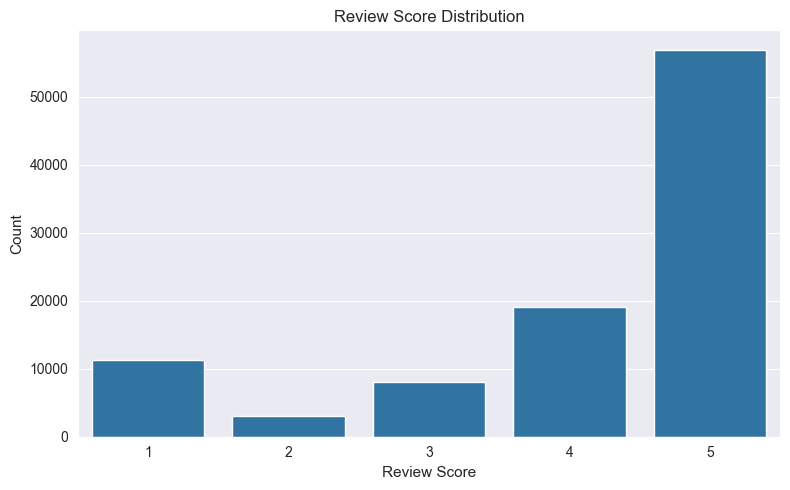

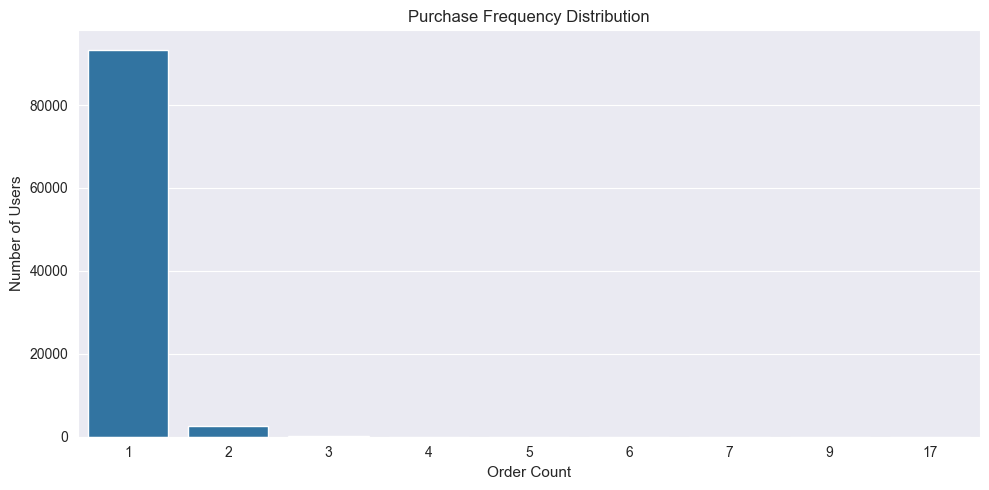

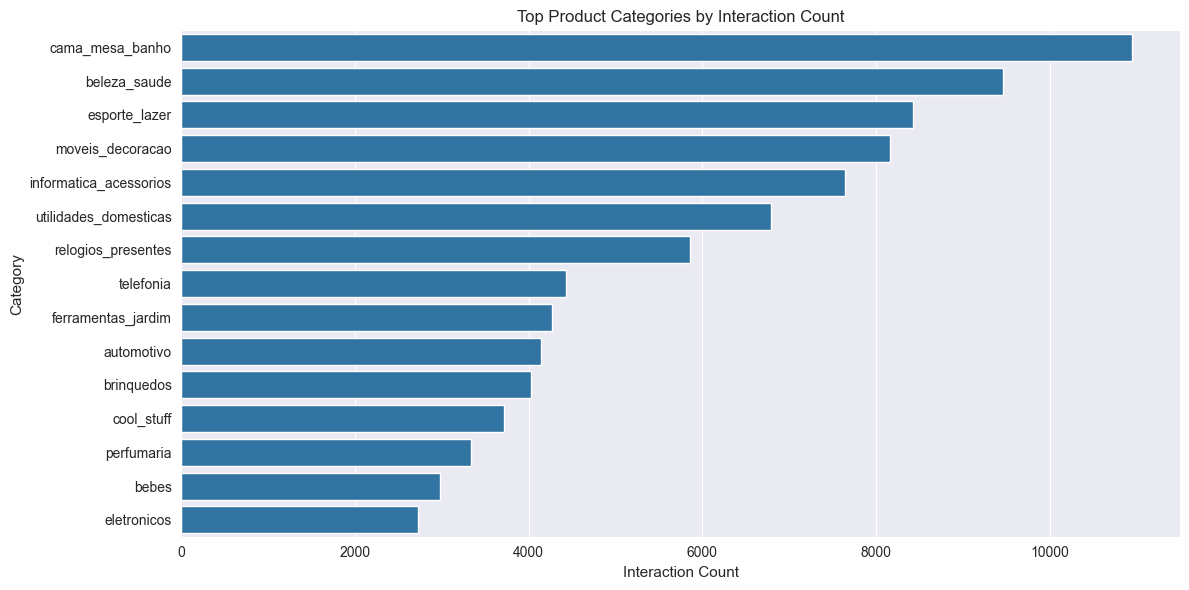

In [22]:
# =========================================================
# 1.3.5 Basic Distribution Plots
# =========================================================

# Review score distribution
plt.figure(figsize=(8, 5))
sns.barplot(data=rating_dist, x='review_score', y='count')
plt.title('Review Score Distribution')
plt.xlabel('Review Score')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(viz_dir, '01_review_score_distribution.png'), dpi=300)
plt.show()

# Purchase frequency distribution (top 15 order_count values)
plot_purchase_freq = purchase_freq_dist.head(15)

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_purchase_freq, x='order_count', y='user_count')
plt.title('Purchase Frequency Distribution')
plt.xlabel('Order Count')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.savefig(os.path.join(viz_dir, '02_purchase_frequency_distribution.png'), dpi=300)
plt.show()

# Top 15 product categories by interaction count
plot_category_dist = category_dist.head(15)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_category_dist, x='interaction_count', y='category')
plt.title('Top Product Categories by Interaction Count')
plt.xlabel('Interaction Count')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig(os.path.join(viz_dir, '03_category_distribution.png'), dpi=300)
plt.show()

In [23]:
# =========================================================
# 1.3.6 Missing Value Check for Key Fields
# =========================================================

missing_check = pd.DataFrame({
    'column': [
        'unique_user_id',
        'product_id',
        'purchase_ts',
        'category',
        'review_score'
    ],
    'missing_count': [
        df_interactions['unique_user_id'].isna().sum(),
        df_interactions['product_id'].isna().sum(),
        df_interactions['purchase_ts'].isna().sum(),
        df_interactions['category'].isna().sum(),
        df_reviews['review_score'].isna().sum()
    ]
})

missing_check['missing_rate'] = missing_check['missing_count'] / [
    len(df_interactions),
    len(df_interactions),
    len(df_interactions),
    len(df_interactions),
    len(df_reviews)
]

missing_check

,column,missing_count,missing_rate
0,unique_user_id,0,0.000000
1,product_id,0,0.000000
2,purchase_ts,0,0.000000
3,category,1537,0.013948
4,review_score,0,0.000000


## Initial Data Exploration Analysis and Summary

The exploratory results show that the recommendation dataset is large in scale but limited in interaction depth. Although the project includes **93,358 users** and **32,216 products**, the average number of unique products per user is only **1.07**, which suggests that most users have very limited purchase history.

The review distribution is highly concentrated at the positive end. Ratings of **4** and **5** dominate the dataset, especially **5-star reviews**, which indicates that explicit feedback is available but not highly balanced across rating levels.

The purchase frequency distribution confirms a strong sparsity problem. About **97%** of users placed only **one order**, which means collaborative filtering alone may be insufficient for many users and cold-start handling will be important.

Product interactions are also concentrated in several major categories, such as **cama_mesa_banho** and **beleza_saude**. In addition, missing values are minimal, with only a small proportion of missing category information.

Overall, the data is suitable for recommendation modeling, but the results suggest that a **hybrid strategy** will be more appropriate than relying on a single method.

# 2. User-Item Rating Matrix Construction

This chapter constructs the rating foundation for the recommendation system. Since user-product interactions are sparse, the project combines explicit and implicit signals to build a more informative user-item matrix for later recommendation modeling.

## 2.1 Explicit Rating Construction

This section uses `review_score` as the explicit feedback signal. Since reviews are recorded at the order level, the data needs to be matched back to user-product interactions before constructing user-item ratings.

In [24]:
# =========================================================
# 2.1.1 Merge Review Scores into Interaction Data
# =========================================================

df_explicit = df_interactions.merge(
    df_reviews[['order_id', 'review_score']],
    on='order_id',
    how='left'
)

print("df_explicit shape:", df_explicit.shape)
df_explicit.head()

df_explicit shape: (110570, 12)


,order_id,order_item_id,product_id,price,freight_value,gmv,user_id,unique_user_id,order_status,purchase_ts,category,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,58.90,13.29,72.19,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,delivered,2017-09-13 08:59:02,cool_stuff,5.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,239.90,19.93,259.83,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,delivered,2017-04-26 10:53:06,pet_shop,4.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,199.00,17.87,216.87,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,delivered,2018-01-14 14:33:31,moveis_decoracao,5.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,12.99,12.79,25.78,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,delivered,2018-08-08 10:00:35,perfumaria,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,199.90,18.14,218.04,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,delivered,2017-02-04 13:57:51,ferramentas_jardim,5.0


In [25]:
# =========================================================
# 2.1.2 Keep Valid Explicit Ratings
# =========================================================

df_explicit_valid = df_explicit[
    df_explicit['review_score'].notna()
].copy()

df_explicit_valid['review_score'] = df_explicit_valid['review_score'].astype(float)

print("df_explicit_valid shape:", df_explicit_valid.shape)
print("Unique users with explicit ratings:", df_explicit_valid['unique_user_id'].nunique())
print("Unique products with explicit ratings:", df_explicit_valid['product_id'].nunique())

df_explicit_valid shape: (109108, 12)
Unique users with explicit ratings: 92719
Unique products with explicit ratings: 31947


In [26]:
# =========================================================
# 2.1.3 Aggregate Repeated Purchases at User-Product Level
# =========================================================

explicit_user_product = (
    df_explicit_valid
    .groupby(['unique_user_id', 'product_id'], as_index=False)
    .agg(
        explicit_rating=('review_score', 'mean'),
        explicit_rating_count=('review_score', 'count')
    )
)

print("explicit_user_product shape:", explicit_user_product.shape)
explicit_user_product.head()

explicit_user_product shape: (98569, 4)


,unique_user_id,product_id,explicit_rating,explicit_rating_count
0,0000366f3b9a7992bf8c76cfdf3221e2,372645c7439f9661fbbacfd129aa92ec,5.0,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,5099f7000472b634fea8304448d20825,4.0,1
2,0000f46a3911fa3c0805444483337064,64b488de448a5324c4134ea39c28a34b,3.0,1
3,0000f6ccb0745a6a4b88665a16c9f078,2345a354a6f2033609bbf62bf5be9ef6,4.0,1
4,0004aac84e0df4da2b147fca70cf8255,c72e18b3fe2739b8d24ebf3102450f37,5.0,1


In [27]:
# =========================================================
# 2.1.4 Check Explicit Rating Distribution After Aggregation
# =========================================================

explicit_rating_dist = (
    explicit_user_product['explicit_rating']
    .round(2)
    .describe()
)

explicit_rating_dist

count    98569.000000
mean         4.127906
std          1.307397
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: explicit_rating, dtype: float64

In [28]:
# =========================================================
# 2.1.5 Save Explicit Rating Table
# =========================================================

explicit_path = os.path.join(data_dir, "explicit_user_product_ratings.csv")
explicit_user_product.to_csv(explicit_path, index=False)

print("Saved:", explicit_path)

Saved: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\08_recommendation_system\data\explicit_user_product_ratings.csv


## Explicit Rating Construction Analysis and Summary

Explicit ratings provide broad coverage across users and products, with **98,569** user-product pairs after aggregation. This means review-based feedback is usable as a direct preference signal.

However, the ratings are strongly concentrated at the high end, with an average of **4.13** and a median of **5.0**. This suggests that explicit feedback reflects satisfaction, but may be less effective for separating moderate preference from strong preference. For this reason, implicit signals should be added in the next step.

## 2.2 Implicit Rating Construction

This section builds implicit ratings from behavioral signals. Since many users do not provide explicit reviews, purchase frequency and spending amount are used to capture preference strength at the user-product level.

In [29]:
# =========================================================
# 2.2.1 Build User-Product Purchase Signals
# =========================================================

implicit_user_product = (
    df_interactions
    .groupby(['unique_user_id', 'product_id'], as_index=False)
    .agg(
        purchase_count=('order_id', 'count'),
        total_spent=('gmv', 'sum'),
        avg_price=('gmv', 'mean')
    )
)

print("implicit_user_product shape:", implicit_user_product.shape)
implicit_user_product.head()

implicit_user_product shape: (99785, 5)


,unique_user_id,product_id,purchase_count,total_spent,avg_price
0,0000366f3b9a7992bf8c76cfdf3221e2,372645c7439f9661fbbacfd129aa92ec,1,141.90,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,5099f7000472b634fea8304448d20825,1,27.19,27.19
2,0000f46a3911fa3c0805444483337064,64b488de448a5324c4134ea39c28a34b,1,86.22,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,2345a354a6f2033609bbf62bf5be9ef6,1,43.62,43.62
4,0004aac84e0df4da2b147fca70cf8255,c72e18b3fe2739b8d24ebf3102450f37,1,196.89,196.89


In [30]:
# =========================================================
# 2.2.2 Normalize Purchase Count with Log Scaling
# =========================================================

implicit_user_product['purchase_count_log'] = np.log1p(implicit_user_product['purchase_count'])

count_log_min = implicit_user_product['purchase_count_log'].min()
count_log_max = implicit_user_product['purchase_count_log'].max()

if count_log_max == count_log_min:
    implicit_user_product['count_rating'] = 3.0
else:
    implicit_user_product['count_rating'] = 1 + 4 * (
        (implicit_user_product['purchase_count_log'] - count_log_min) /
        (count_log_max - count_log_min)
    )

implicit_user_product[['purchase_count', 'purchase_count_log', 'count_rating']].head()

,purchase_count,purchase_count_log,count_rating
0,1,0.693147,1.0
1,1,0.693147,1.0
2,1,0.693147,1.0
3,1,0.693147,1.0
4,1,0.693147,1.0


In [31]:
# =========================================================
# 2.2.3 Normalize Spending Amount with Log Scaling
# =========================================================

implicit_user_product['total_spent_log'] = np.log1p(implicit_user_product['total_spent'])

spend_log_min = implicit_user_product['total_spent_log'].min()
spend_log_max = implicit_user_product['total_spent_log'].max()

if spend_log_max == spend_log_min:
    implicit_user_product['spend_rating'] = 3.0
else:
    implicit_user_product['spend_rating'] = 1 + 4 * (
        (implicit_user_product['total_spent_log'] - spend_log_min) /
        (spend_log_max - spend_log_min)
    )

implicit_user_product[['total_spent', 'total_spent_log', 'spend_rating']].head()

,total_spent,total_spent_log,spend_rating
0,141.90,4.962145,2.537803
1,27.19,3.338967,1.661447
2,86.22,4.468434,2.271248
3,43.62,3.798182,1.909378
4,196.89,5.287711,2.713577


In [32]:
# =========================================================
# 2.2.4 Combine Implicit Signals
# =========================================================

implicit_user_product['implicit_rating'] = (
    0.4 * implicit_user_product['count_rating'] +
    0.6 * implicit_user_product['spend_rating']
)

implicit_rating_dist = implicit_user_product['implicit_rating'].describe()
implicit_rating_dist

count    99785.000000
mean         1.851745
std          0.290409
min          1.000000
25%          1.651298
50%          1.825276
75%          2.007603
max          4.651278
Name: implicit_rating, dtype: float64

In [33]:
# =========================================================
# 2.2.5 Save Implicit Rating Table
# =========================================================

implicit_path = os.path.join(data_dir, "implicit_user_product_ratings.csv")
implicit_user_product.to_csv(implicit_path, index=False)

print("Saved:", implicit_path)

Saved: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\08_recommendation_system\data\implicit_user_product_ratings.csv


## Implicit Rating Construction Analysis and Summary

The implicit rating table covers **99,785** user-product pairs and extends the preference signal beyond review data. After log scaling, the score distribution becomes more informative and less compressed near the lower bound.

At the same time, the results also show that **purchase frequency contributes little variation**, because most users purchased only once. In this dataset, spending-based behavior is more useful than frequency for implicit preference construction.
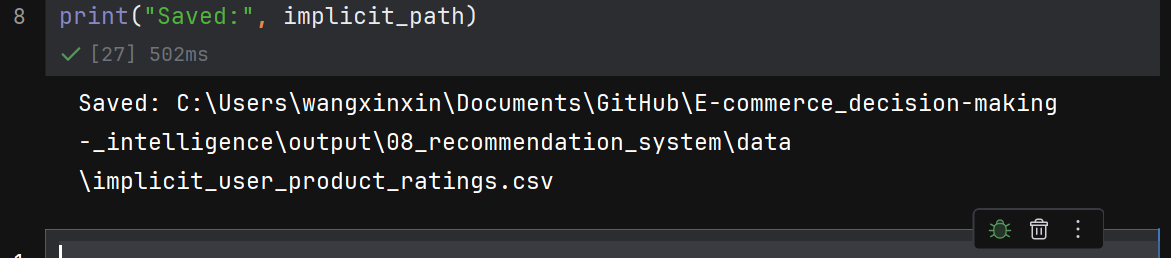
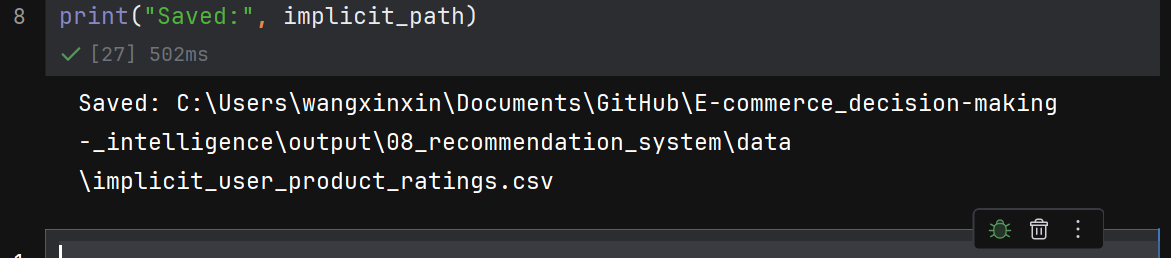

## 2.3 Combine Explicit and Implicit Ratings

This section combines explicit and implicit ratings into a unified user-product score. If both signals are available, explicit feedback is given higher weight because it directly reflects customer evaluation. If explicit feedback is missing, the model falls back on implicit behavior-based signals.

In [34]:
# =========================================================
# 2.3.1 Merge Explicit and Implicit Ratings
# =========================================================

df_ratings = implicit_user_product.merge(
    explicit_user_product[['unique_user_id', 'product_id', 'explicit_rating']],
    on=['unique_user_id', 'product_id'],
    how='left'
)

print("df_ratings shape:", df_ratings.shape)
df_ratings.head()

df_ratings shape: (99785, 11)


,unique_user_id,product_id,purchase_count,total_spent,avg_price,purchase_count_log,count_rating,total_spent_log,spend_rating,implicit_rating,explicit_rating
0,0000366f3b9a7992bf8c76cfdf3221e2,372645c7439f9661fbbacfd129aa92ec,1,141.90,141.90,0.693147,1.0,4.962145,2.537803,1.922682,5.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,5099f7000472b634fea8304448d20825,1,27.19,27.19,0.693147,1.0,3.338967,1.661447,1.396868,4.0
2,0000f46a3911fa3c0805444483337064,64b488de448a5324c4134ea39c28a34b,1,86.22,86.22,0.693147,1.0,4.468434,2.271248,1.762749,3.0
3,0000f6ccb0745a6a4b88665a16c9f078,2345a354a6f2033609bbf62bf5be9ef6,1,43.62,43.62,0.693147,1.0,3.798182,1.909378,1.545627,4.0
4,0004aac84e0df4da2b147fca70cf8255,c72e18b3fe2739b8d24ebf3102450f37,1,196.89,196.89,0.693147,1.0,5.287711,2.713577,2.028146,5.0


In [35]:
# =========================================================
# 2.3.2 Create Final Combined Rating
# =========================================================

df_ratings['final_rating'] = np.where(
    df_ratings['explicit_rating'].notna(),
    0.7 * df_ratings['explicit_rating'] + 0.3 * df_ratings['implicit_rating'],
    df_ratings['implicit_rating']
)

df_ratings[['explicit_rating', 'implicit_rating', 'final_rating']].head()

,explicit_rating,implicit_rating,final_rating
0,5.0,1.922682,4.076805
1,4.0,1.396868,3.219060
2,3.0,1.762749,2.628825
3,4.0,1.545627,3.263688
4,5.0,2.028146,4.108444


In [36]:
# =========================================================
# 2.3.3 Check Final Rating Distribution
# =========================================================

final_rating_dist = df_ratings['final_rating'].describe()
final_rating_dist

count    99785.000000
mean         3.425769
std          0.926164
min          1.042485
25%          3.255726
50%          3.963448
75%          4.059304
max          4.706749
Name: final_rating, dtype: float64

In [37]:
# =========================================================
# 2.3.4 Check Signal Coverage
# =========================================================

rating_coverage = pd.DataFrame({
    'metric': [
        'Total user-product pairs',
        'Pairs with explicit rating',
        'Pairs without explicit rating',
        'Explicit coverage rate'
    ],
    'value': [
        len(df_ratings),
        df_ratings['explicit_rating'].notna().sum(),
        df_ratings['explicit_rating'].isna().sum(),
        round(df_ratings['explicit_rating'].notna().mean(), 4)
    ]
})

rating_coverage

,metric,value
0,Total user-product pairs,99785.0000
1,Pairs with explicit rating,98569.0000
2,Pairs without explicit rating,1216.0000
3,Explicit coverage rate,0.9878


In [38]:
# =========================================================
# 2.3.5 Keep Final Rating Table
# =========================================================

rating_cols = [
    'unique_user_id',
    'product_id',
    'purchase_count',
    'total_spent',
    'implicit_rating',
    'explicit_rating',
    'final_rating'
]

df_ratings_final = df_ratings[rating_cols].copy()

print("df_ratings_final shape:", df_ratings_final.shape)
df_ratings_final.head()

df_ratings_final shape: (99785, 7)


,unique_user_id,product_id,purchase_count,total_spent,implicit_rating,explicit_rating,final_rating
0,0000366f3b9a7992bf8c76cfdf3221e2,372645c7439f9661fbbacfd129aa92ec,1,141.90,1.922682,5.0,4.076805
1,0000b849f77a49e4a4ce2b2a4ca5be3f,5099f7000472b634fea8304448d20825,1,27.19,1.396868,4.0,3.219060
2,0000f46a3911fa3c0805444483337064,64b488de448a5324c4134ea39c28a34b,1,86.22,1.762749,3.0,2.628825
3,0000f6ccb0745a6a4b88665a16c9f078,2345a354a6f2033609bbf62bf5be9ef6,1,43.62,1.545627,4.0,3.263688
4,0004aac84e0df4da2b147fca70cf8255,c72e18b3fe2739b8d24ebf3102450f37,1,196.89,2.028146,5.0,4.108444


In [39]:
# =========================================================
# 2.3.6 Save Final Rating Table
# =========================================================

final_rating_path = os.path.join(data_dir, "user_product_final_ratings.csv")
df_ratings_final.to_csv(final_rating_path, index=False)

print("Saved:", final_rating_path)

Saved: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\08_recommendation_system\data\user_product_final_ratings.csv


## Combine Explicit and Implicit Ratings Analysis and Summary

The combined rating table contains **99,785** user-product pairs, and explicit feedback covers **98.78%** of them. This means the final rating matrix is still mainly anchored in review-based evaluation, while implicit signals fill a small but useful gap.

The final rating distribution is more balanced than the original explicit or implicit signals alone. This suggests that the fusion step improves score stability and makes the rating matrix more suitable for later similarity-based recommendation modeling.

## 2.4 Build User-Item Matrix

This section transforms the final rating table into a user-item matrix. This matrix is the core input for collaborative filtering and will later be converted into sparse format for more efficient computation.
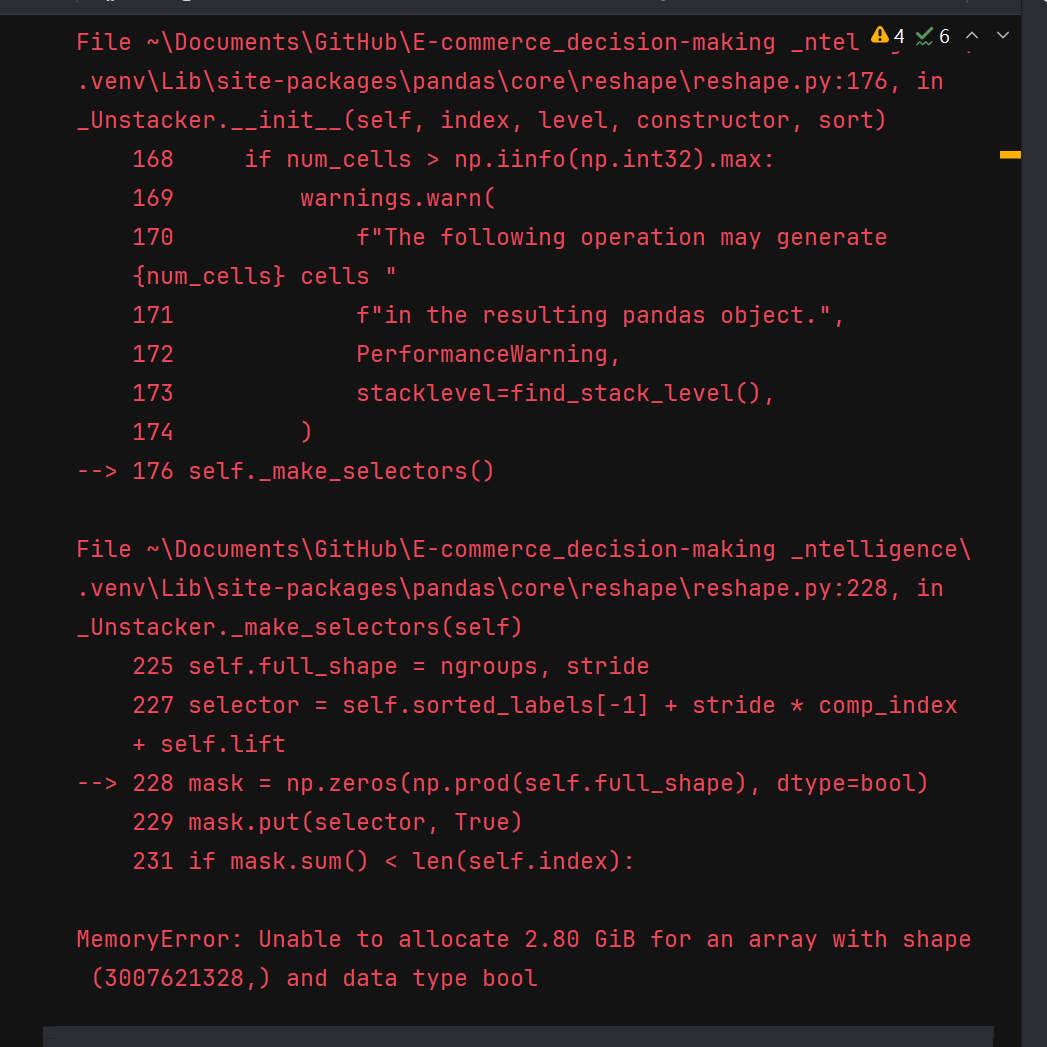
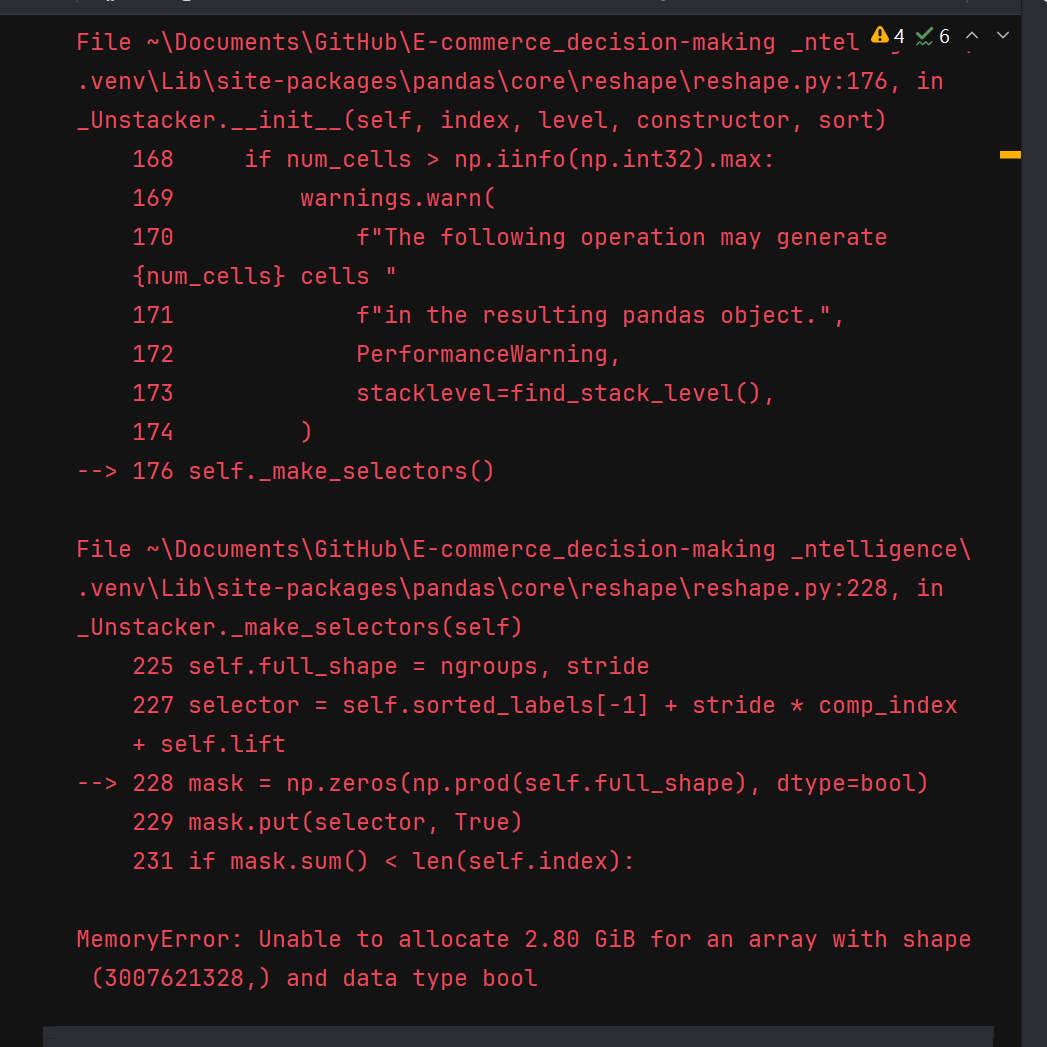
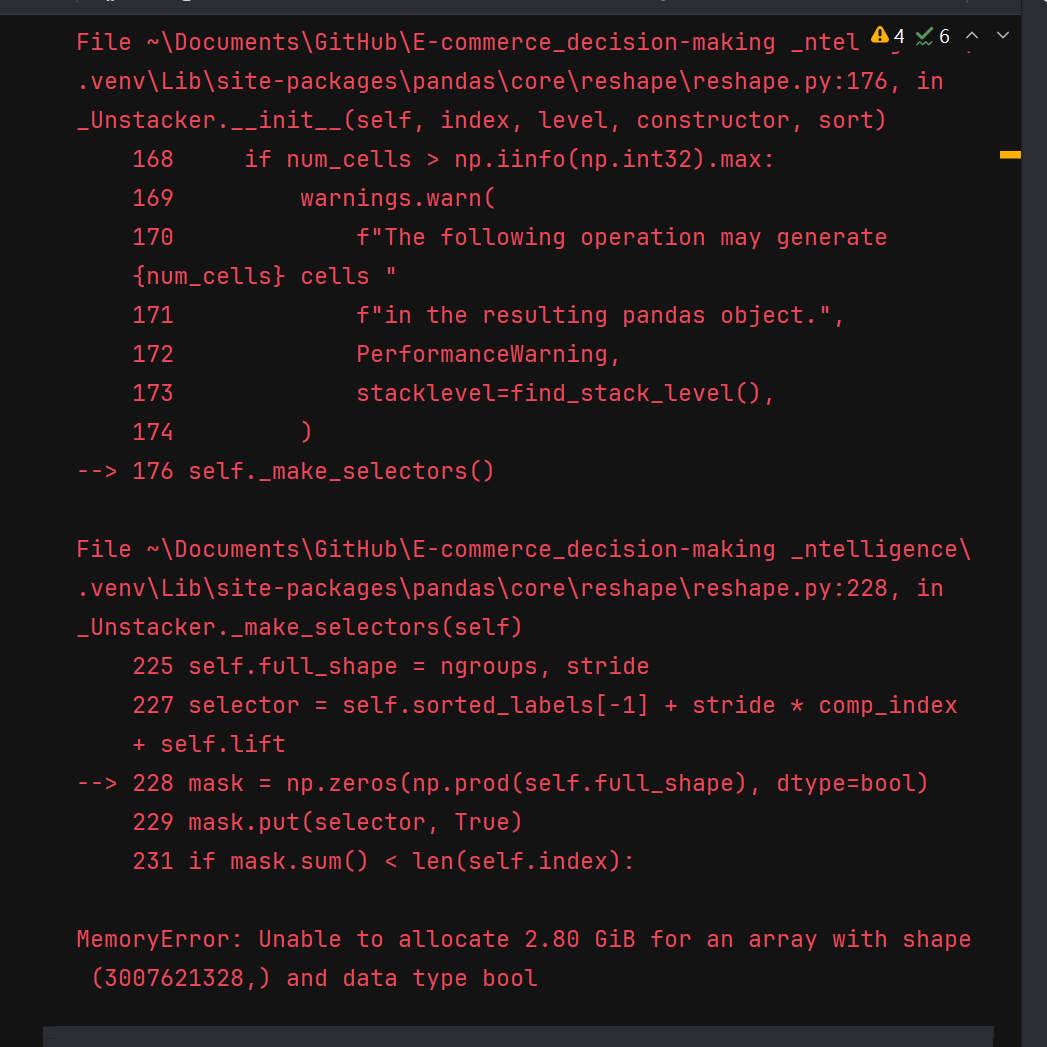
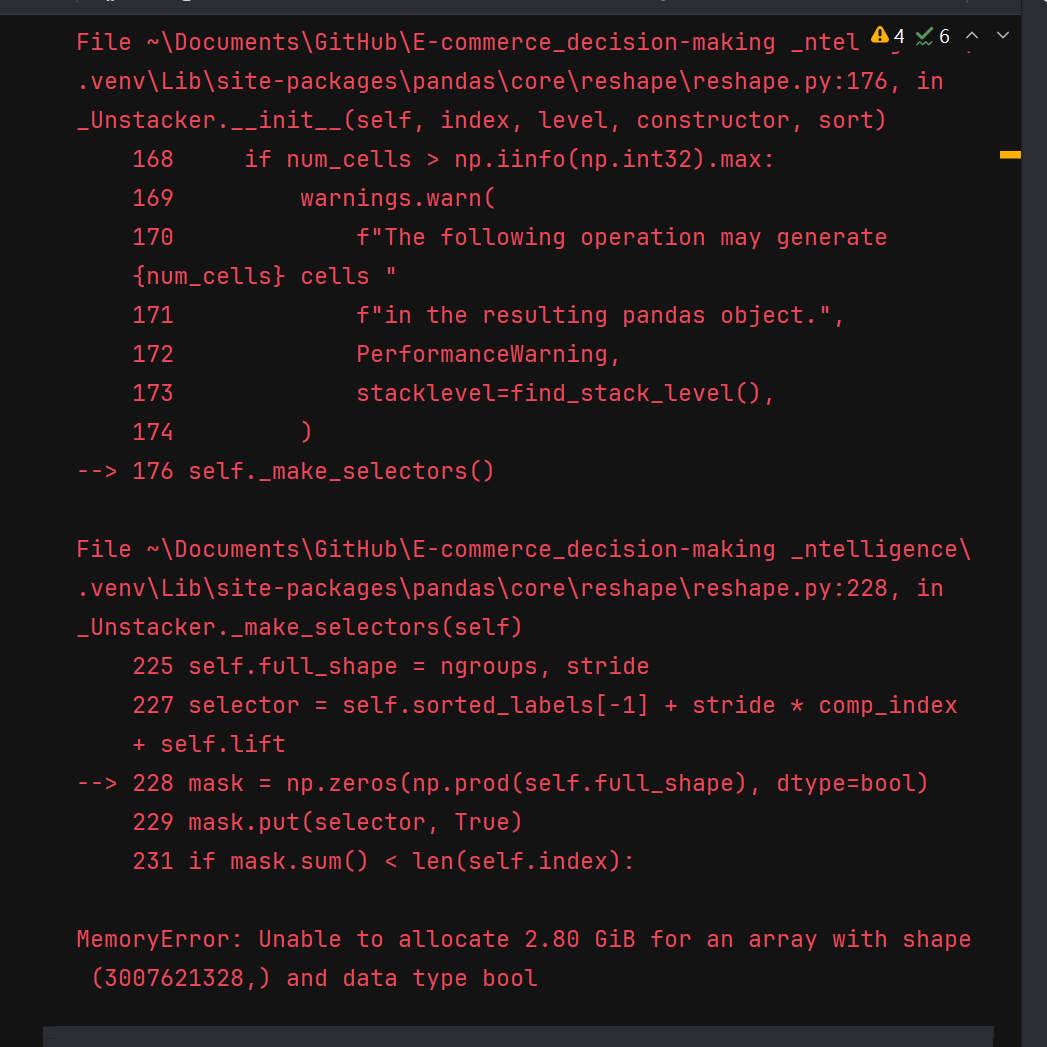

In [40]:
# =========================================================
# 2.4.1 Prepare Row and Column Indices
# =========================================================

df_sparse_input = df_ratings_final[['unique_user_id', 'product_id', 'final_rating']].copy()

df_sparse_input['user_idx'] = df_sparse_input['unique_user_id'].astype('category').cat.codes
df_sparse_input['item_idx'] = df_sparse_input['product_id'].astype('category').cat.codes

user_index = (
    df_sparse_input[['unique_user_id', 'user_idx']]
    .drop_duplicates()
    .sort_values('user_idx')
    .reset_index(drop=True)
)

item_index = (
    df_sparse_input[['product_id', 'item_idx']]
    .drop_duplicates()
    .sort_values('item_idx')
    .reset_index(drop=True)
)

num_users = user_index.shape[0]
num_items = item_index.shape[0]

print("Number of users:", num_users)
print("Number of items:", num_items)

df_sparse_input.head()

Number of users: 93358
Number of items: 32216


,unique_user_id,product_id,final_rating,user_idx,item_idx
0,0000366f3b9a7992bf8c76cfdf3221e2,372645c7439f9661fbbacfd129aa92ec,4.076805,0,7003
1,0000b849f77a49e4a4ce2b2a4ca5be3f,5099f7000472b634fea8304448d20825,3.219060,1,10224
2,0000f46a3911fa3c0805444483337064,64b488de448a5324c4134ea39c28a34b,2.628825,2,12712
3,0000f6ccb0745a6a4b88665a16c9f078,2345a354a6f2033609bbf62bf5be9ef6,3.263688,3,4576
4,0004aac84e0df4da2b147fca70cf8255,c72e18b3fe2739b8d24ebf3102450f37,4.108444,4,25060


In [41]:
# =========================================================
# 2.4.2 Build Sparse Matrix Directly
# =========================================================

user_item_sparse = csr_matrix(
    (
        df_sparse_input['final_rating'].values,
        (df_sparse_input['user_idx'].values, df_sparse_input['item_idx'].values)
    ),
    shape=(num_users, num_items)
)

print("Sparse matrix shape:", user_item_sparse.shape)
print("Number of non-zero entries:", user_item_sparse.nnz)

Sparse matrix shape: (93358, 32216)
Number of non-zero entries: 99785


In [42]:
from scipy.sparse import csr_matrix, save_npz

In [43]:
# =========================================================
# 2.4.3 Save Sparse Matrix and Index Mapping
# =========================================================

sparse_matrix_path = os.path.join(data_dir, "user_item_sparse_matrix.npz")
user_index_path = os.path.join(data_dir, "user_index_map.csv")
item_index_path = os.path.join(data_dir, "item_index_map.csv")

save_npz(sparse_matrix_path, user_item_sparse)
user_index.to_csv(user_index_path, index=False)
item_index.to_csv(item_index_path, index=False)

print("Saved sparse matrix:", sparse_matrix_path)
print("Saved user index map:", user_index_path)
print("Saved item index map:", item_index_path)

Saved sparse matrix: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\08_recommendation_system\data\user_item_sparse_matrix.npz
Saved user index map: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\08_recommendation_system\data\user_index_map.csv
Saved item index map: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\08_recommendation_system\data\item_index_map.csv


## 2.5 Matrix Sparsity Analysis

This section evaluates the sparsity of the user-item matrix in sparse format. High sparsity is expected in recommendation systems and is an important reason for using hybrid recommendation instead of relying on a single collaborative filtering method.

In [44]:
# =========================================================
# 2.5.1 Calculate Sparsity
# =========================================================

total_cells = num_users * num_items
non_zero_cells = user_item_sparse.nnz
sparsity = 1 - (non_zero_cells / total_cells)

print(f"Number of users: {num_users:,}")
print(f"Number of items: {num_items:,}")
print(f"Non-zero entries: {non_zero_cells:,}")
print(f"Sparsity: {sparsity:.6f}")

Number of users: 93,358
Number of items: 32,216
Non-zero entries: 99,785
Sparsity: 0.999967


In [45]:
# =========================================================
# 2.5.2 User Interaction Count Distribution
# =========================================================

user_rated_count = pd.DataFrame({
    'user_idx': np.arange(num_users),
    'rated_product_count': user_item_sparse.getnnz(axis=1)
})

user_rated_count['rated_product_count'].describe()

count    93358.000000
mean         1.068843
std          0.316919
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         14.000000
Name: rated_product_count, dtype: float64

In [46]:
# =========================================================
# 2.5.3 Item Interaction Count Distribution
# =========================================================

item_rated_count = pd.DataFrame({
    'item_idx': np.arange(num_items),
    'rated_user_count': user_item_sparse.getnnz(axis=0)
})

item_rated_count['rated_user_count'].describe()

count    32216.000000
mean         3.097374
std          9.366386
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max        456.000000
Name: rated_user_count, dtype: float64

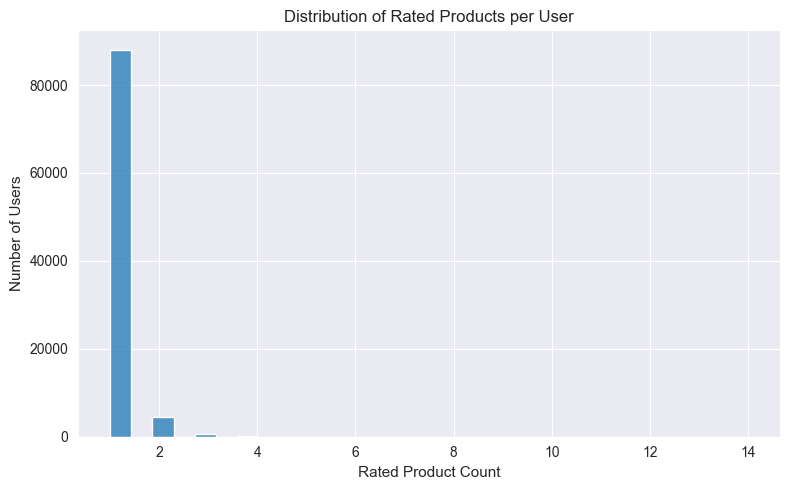

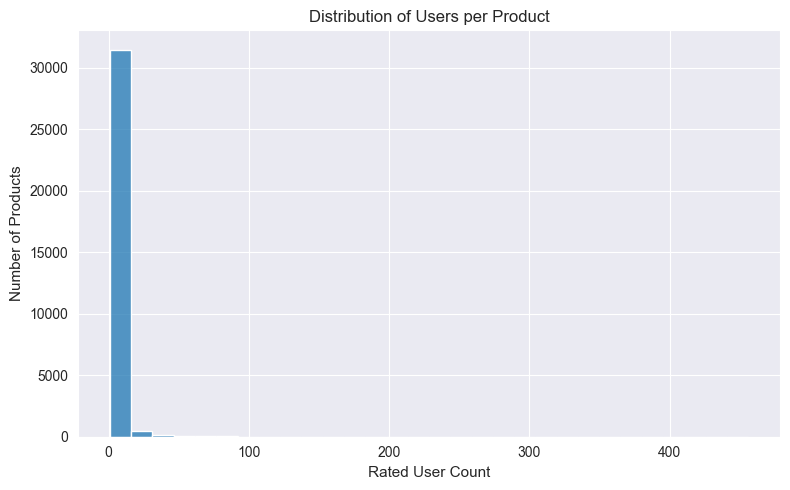

In [47]:
# =========================================================
# 2.5.4 Plot Sparsity-Related Distributions
# =========================================================

plt.figure(figsize=(8, 5))
sns.histplot(user_rated_count['rated_product_count'], bins=30)
plt.title('Distribution of Rated Products per User')
plt.xlabel('Rated Product Count')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.savefig(os.path.join(viz_dir, '04_user_rated_product_distribution.png'), dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(item_rated_count['rated_user_count'], bins=30)
plt.title('Distribution of Users per Product')
plt.xlabel('Rated User Count')
plt.ylabel('Number of Products')
plt.tight_layout()
plt.savefig(os.path.join(viz_dir, '05_product_rated_user_distribution.png'), dpi=300)
plt.show()

In [48]:
# =========================================================
# 2.5.5 Save Sparsity Summary
# =========================================================

sparsity_summary = pd.DataFrame({
    'metric': [
        'Number of users',
        'Number of products',
        'Non-zero entries',
        'Sparsity'
    ],
    'value': [
        num_users,
        num_items,
        non_zero_cells,
        sparsity
    ]
})

sparsity_summary_path = os.path.join(eval_dir, "matrix_sparsity_summary.csv")
sparsity_summary.to_csv(sparsity_summary_path, index=False)

print("Saved:", sparsity_summary_path)
sparsity_summary

Saved: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\08_recommendation_system\evaluation\matrix_sparsity_summary.csv


,metric,value
0,Number of users,93358.000000
1,Number of products,32216.000000
2,Non-zero entries,99785.000000
3,Sparsity,0.999967


## Matrix Sparsity Analysis and Summary

The user-item matrix is extremely sparse, with a sparsity level of **0.999967**. Although the matrix covers a large number of users and products, only a very small fraction of user-item pairs contain observed ratings.

The distribution results confirm that most users interacted with only **one product**, and most products were rated by very few users. This means full dense similarity computation is not practical in this project. A lightweight recommendation strategy based on sparse computation and nearest-neighbor search is more appropriate.

# 3. Algorithm 1 - User-Based Collaborative Filtering

This chapter implements a lightweight user-based collaborative filtering method. Because the full user-user similarity matrix would be too large for memory-efficient computation, the project uses nearest-neighbor search on the sparse user-item matrix instead of building a full dense similarity table.

## 3.1 User Similarity Modeling

This section uses cosine distance with a sparse nearest-neighbor model to identify similar users. This approach preserves the logic of user-based collaborative filtering while remaining feasible under extreme matrix sparsity.

In [49]:
# =========================================================
# 3.1.1 Import nearest-neighbor model
# =========================================================
from sklearn.neighbors import NearestNeighbors

In [50]:
# =========================================================
# 3.1.2 Fit User-Based Nearest-Neighbor Model
# =========================================================

user_knn_model = NearestNeighbors(
    metric='cosine',
    algorithm='brute',
    n_neighbors=201,
    n_jobs=-1
)

user_knn_model.fit(user_item_sparse)

print("User-based nearest-neighbor model fitted successfully.")

User-based nearest-neighbor model fitted successfully.


In [51]:
# =========================================================
# 3.1.2 Fit User-Based Nearest-Neighbor Model
# =========================================================

user_knn_model = NearestNeighbors(
    metric='cosine',
    algorithm='brute',
    n_neighbors=51,
    n_jobs=-1
)

user_knn_model.fit(user_item_sparse)

print("User-based nearest-neighbor model fitted successfully.")

User-based nearest-neighbor model fitted successfully.


In [52]:
# =========================================================
# 3.1.3 Build User Lookup Dictionaries
# =========================================================

user_id_to_idx = dict(zip(user_index['unique_user_id'], user_index['user_idx']))
idx_to_user_id = dict(zip(user_index['user_idx'], user_index['unique_user_id']))

item_id_to_idx = dict(zip(item_index['product_id'], item_index['item_idx']))
idx_to_item_id = dict(zip(item_index['item_idx'], item_index['product_id']))

print("Lookup dictionaries created.")

Lookup dictionaries created.


In [53]:
# =========================================================
# 3.1.4 Find Nearest Neighbors for One Sample User
# =========================================================

sample_user_idx = 0

distances, indices = user_knn_model.kneighbors(
    user_item_sparse[sample_user_idx],
    n_neighbors=6
)

neighbor_df = pd.DataFrame({
    'neighbor_user_idx': indices.flatten(),
    'cosine_distance': distances.flatten()
})

neighbor_df['cosine_similarity'] = 1 - neighbor_df['cosine_distance']

neighbor_df = neighbor_df.merge(
    user_index.rename(columns={'user_idx': 'neighbor_user_idx', 'unique_user_id': 'neighbor_user_id'}),
    on='neighbor_user_idx',
    how='left'
)

neighbor_df = neighbor_df[['neighbor_user_idx', 'neighbor_user_id', 'cosine_distance', 'cosine_similarity']]
neighbor_df

,neighbor_user_idx,neighbor_user_id,cosine_distance,cosine_similarity
0,0,0000366f3b9a7992bf8c76cfdf3221e2,0.0,1.0
1,81262,de7a428e09364ae6610486cebe43aa99,0.0,1.0
2,75519,cef123fce76a8e796056f981d3ded671,0.0,1.0
3,67034,b7a16ae54a2a6515f7756fe9ccae7378,0.0,1.0
4,62054,a9f5c3a79712c265b684072569b2c468,0.0,1.0
5,65580,b392ff4d509a87ad6b53535bccb8ad04,0.0,1.0


## 3.2 Generate Recommendations

This section generates recommendations by combining the ratings of the most similar users. Only unrated products are considered as candidates, and the final recommendation score is calculated as a similarity-weighted average.

In [54]:
# =========================================================
# 3.2.1 Define User-Based Recommendation Function
# =========================================================

item_idx_to_product_id = item_index.set_index('item_idx')['product_id'].to_dict()
user_id_to_idx = user_index.set_index('unique_user_id')['user_idx'].to_dict()

def recommend_user_based(user_id, top_n=10, k_neighbors=200, min_similarity=1e-6):
    """
    Generate User-Based CF recommendations using sparse nearest neighbors.
    If no valid candidate is found, fallback to popular unseen products.
    """
    if user_id not in user_id_to_idx:
        return pd.DataFrame(columns=['product_id', 'predicted_rating', 'score_source'])

    user_idx = int(user_id_to_idx[user_id])

    distances, indices = user_knn_model.kneighbors(
        user_item_sparse[user_idx],
        n_neighbors=min(k_neighbors + 1, num_users)
    )

    neighbor_indices = indices.flatten()[1:]
    neighbor_similarities = 1 - distances.flatten()[1:]

    valid_neighbors = [
        (idx, sim) for idx, sim in zip(neighbor_indices, neighbor_similarities)
        if sim > min_similarity
    ]

    target_vector = user_item_sparse[user_idx].toarray().flatten()
    rated_items = set(np.where(target_vector > 0)[0])

    candidate_items = set()
    for neighbor_idx, _ in valid_neighbors:
        candidate_items.update(user_item_sparse[neighbor_idx].indices)

    candidate_items = candidate_items - rated_items

    predictions = {}

    for item_idx in candidate_items:
        weighted_sum = 0
        similarity_sum = 0

        for neighbor_idx, sim in valid_neighbors:
            neighbor_rating = user_item_sparse[neighbor_idx, item_idx]
            if neighbor_rating > 0:
                weighted_sum += sim * neighbor_rating
                similarity_sum += sim

        if similarity_sum > 0:
            predictions[item_idx] = weighted_sum / similarity_sum

    if len(predictions) > 0:
        top_items = sorted(predictions.items(), key=lambda x: x[1], reverse=True)[:top_n]

        result = pd.DataFrame({
            'product_id': [item_idx_to_product_id[item_idx] for item_idx, _ in top_items],
            'predicted_rating': [score for _, score in top_items],
            'score_source': 'user_cf'
        })
        return result

    fallback = df_product_sales.copy()
    seen_product_ids = {item_idx_to_product_id[i] for i in rated_items if i in item_idx_to_product_id}

    fallback = fallback[~fallback['product_id'].isin(seen_product_ids)].copy()
    fallback = fallback.sort_values(
        ['sales_count', 'avg_review_score'],
        ascending=[False, False]
    ).head(top_n)

    if fallback.empty:
        return pd.DataFrame(columns=['product_id', 'predicted_rating', 'score_source'])

    fallback = fallback[['product_id']].copy()
    fallback['predicted_rating'] = np.nan
    fallback['score_source'] = 'fallback_popular'

    return fallback

In [55]:
# =========================================================
# 3.2.2 Test Recommendation for One More Active User
# =========================================================

active_users = user_rated_count[user_rated_count['rated_product_count'] >= 3].copy()
active_users = active_users.sort_values('rated_product_count', ascending=False)

sample_user_idx = int(active_users.iloc[0]['user_idx'])
sample_user_id = user_index.loc[user_index['user_idx'] == sample_user_idx, 'unique_user_id'].iloc[0]

print("Sample active user:", sample_user_id)
print("Rated product count:", int(active_users.iloc[0]['rated_product_count']))

sample_user_recs = recommend_user_based(sample_user_id, top_n=10, k_neighbors=200)

sample_user_recs = sample_user_recs.merge(
    df_products[['product_id', 'category']],
    on='product_id',
    how='left'
)

sample_user_recs.head(10)

Sample active user: 8d50f5eadf50201ccdcedfb9e2ac8455
Rated product count: 14


,product_id,predicted_rating,score_source,category
0,aca2eb7d00ea1a7b8ebd4e68314663af,NaN,fallback_popular,moveis_decoracao
1,99a4788cb24856965c36a24e339b6058,NaN,fallback_popular,cama_mesa_banho
2,422879e10f46682990de24d770e7f83d,NaN,fallback_popular,ferramentas_jardim
3,389d119b48cf3043d311335e499d9c6b,NaN,fallback_popular,ferramentas_jardim
4,368c6c730842d78016ad823897a372db,NaN,fallback_popular,ferramentas_jardim
5,53759a2ecddad2bb87a079a1f1519f73,NaN,fallback_popular,ferramentas_jardim
6,d1c427060a0f73f6b889a5c7c61f2ac4,NaN,fallback_popular,informatica_acessorios
7,53b36df67ebb7c41585e8d54d6772e08,NaN,fallback_popular,relogios_presentes
8,154e7e31ebfa092203795c972e5804a6,NaN,fallback_popular,beleza_saude
9,3dd2a17168ec895c781a9191c1e95ad7,NaN,fallback_popular,informatica_acessorios


## User-Based Collaborative Filtering Analysis and Summary

The user-based recommendation pipeline runs successfully, but the results show clear limitations under extreme sparsity. Even for a relatively active user, the model mainly falls back to popular unseen products instead of producing stable neighbor-based recommendations.

This suggests that User-Based CF is technically feasible, but not strong enough as a standalone method in this dataset. Its main value in this project is to serve as one component of a broader hybrid recommendation strategy.
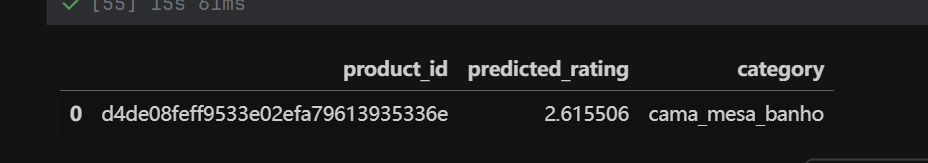

## 3.3 Batch Recommendation

This section generates User-Based CF recommendations for users with at least a minimal interaction history. Under extreme sparsity, low-activity users are not well suited for standalone user-based recommendation and will be handled later in the hybrid recommendation stage.

In [56]:
# =========================================================
# 3.3.1 Select Eligible Users
# =========================================================

eligible_user_df = user_rated_count[user_rated_count['rated_product_count'] >= 3].copy()
eligible_user_df = eligible_user_df.sort_values('rated_product_count', ascending=False)

eligible_user_df = eligible_user_df.merge(
    user_index[['user_idx', 'unique_user_id']],
    on='user_idx',
    how='left'
)

print("Eligible users for User-CF:", len(eligible_user_df))
eligible_user_df.head()

Eligible users for User-CF: 760


,user_idx,rated_product_count,unique_user_id
0,51431,14,8d50f5eadf50201ccdcedfb9e2ac8455
1,22779,13,3e43e6105506432c953e165fb2acf44c
2,73921,9,ca77025e7201e3b30c44b472ff346268
3,10060,9,1b6c7548a2a1f9037c1fd3ddfed95f33
4,73378,8,c8ed31310fc440a3f8031b177f9842c3


In [57]:
# =========================================================
# 3.3.2 Batch Generate Recommendations
# =========================================================

user_based_results = []

for i, row in eligible_user_df.iterrows():
    user_id = row['unique_user_id']
    recs = recommend_user_based(user_id, top_n=10, k_neighbors=200)

    if not recs.empty:
        recs = recs.copy()
        recs['unique_user_id'] = user_id
        recs['rated_product_count'] = row['rated_product_count']
        user_based_results.append(recs)

df_user_based_recs = pd.concat(user_based_results, ignore_index=True) if user_based_results else pd.DataFrame()

print("df_user_based_recs shape:", df_user_based_recs.shape)
df_user_based_recs.head()

df_user_based_recs shape: (4953, 5)


,product_id,predicted_rating,score_source,unique_user_id,rated_product_count
0,aca2eb7d00ea1a7b8ebd4e68314663af,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14
1,99a4788cb24856965c36a24e339b6058,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14
2,422879e10f46682990de24d770e7f83d,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14
3,389d119b48cf3043d311335e499d9c6b,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14
4,368c6c730842d78016ad823897a372db,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14


In [58]:
# =========================================================
# 3.3.3 Attach Product Category
# =========================================================

# Remove old category columns first if they already exist
drop_cols = [col for col in ['category', 'category_x', 'category_y'] if col in df_user_based_recs.columns]
if drop_cols:
    df_user_based_recs = df_user_based_recs.drop(columns=drop_cols)

df_user_based_recs = df_user_based_recs.merge(
    df_products[['product_id', 'category']],
    on='product_id',
    how='left'
)

print("df_user_based_recs shape after merge:", df_user_based_recs.shape)
print(df_user_based_recs.columns.tolist())
df_user_based_recs.head()

df_user_based_recs shape after merge: (4953, 6)
['product_id', 'predicted_rating', 'score_source', 'unique_user_id', 'rated_product_count', 'category']


,product_id,predicted_rating,score_source,unique_user_id,rated_product_count,category
0,aca2eb7d00ea1a7b8ebd4e68314663af,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14,moveis_decoracao
1,99a4788cb24856965c36a24e339b6058,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14,cama_mesa_banho
2,422879e10f46682990de24d770e7f83d,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14,ferramentas_jardim
3,389d119b48cf3043d311335e499d9c6b,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14,ferramentas_jardim
4,368c6c730842d78016ad823897a372db,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14,ferramentas_jardim


## 3.4 Recommendation Pattern Check

This section performs a simple check on the structure of User-Based CF outputs, including score source and category distribution.

In [59]:
# =========================================================
# 3.4.1 Check Score Source Distribution
# =========================================================

score_source_dist = (
    df_user_based_recs['score_source']
    .value_counts(dropna=False)
    .reset_index()
)

score_source_dist.columns = ['score_source', 'count']
score_source_dist['share'] = score_source_dist['count'] / score_source_dist['count'].sum()

score_source_dist

,score_source,count,share
0,user_cf,2763,0.557844
1,fallback_popular,2190,0.442156


In [60]:
# =========================================================
# 3.4.2 Check Category Distribution
# =========================================================

category_col = None
for col in ['category', 'category_x', 'category_y']:
    if col in df_user_based_recs.columns:
        category_col = col
        break

if category_col is None:
    raise KeyError("No category column found in df_user_based_recs. Please run 3.3.3 first.")

user_cf_category_dist = (
    df_user_based_recs[category_col]
    .fillna('Unknown')
    .value_counts()
    .reset_index()
)

user_cf_category_dist.columns = ['category', 'recommendation_count']
user_cf_category_dist['share'] = (
    user_cf_category_dist['recommendation_count'] /
    user_cf_category_dist['recommendation_count'].sum()
)

user_cf_category_dist.head(15)

,category,recommendation_count,share
0,cama_mesa_banho,1158,0.233798
1,ferramentas_jardim,914,0.184535
2,informatica_acessorios,552,0.111448
3,moveis_decoracao,522,0.105391
4,relogios_presentes,489,0.098728
5,beleza_saude,343,0.069251
6,esporte_lazer,102,0.020594
7,utilidades_domesticas,99,0.019988
8,brinquedos,95,0.019180
9,fashion_bolsas_e_acessorios,86,0.017363


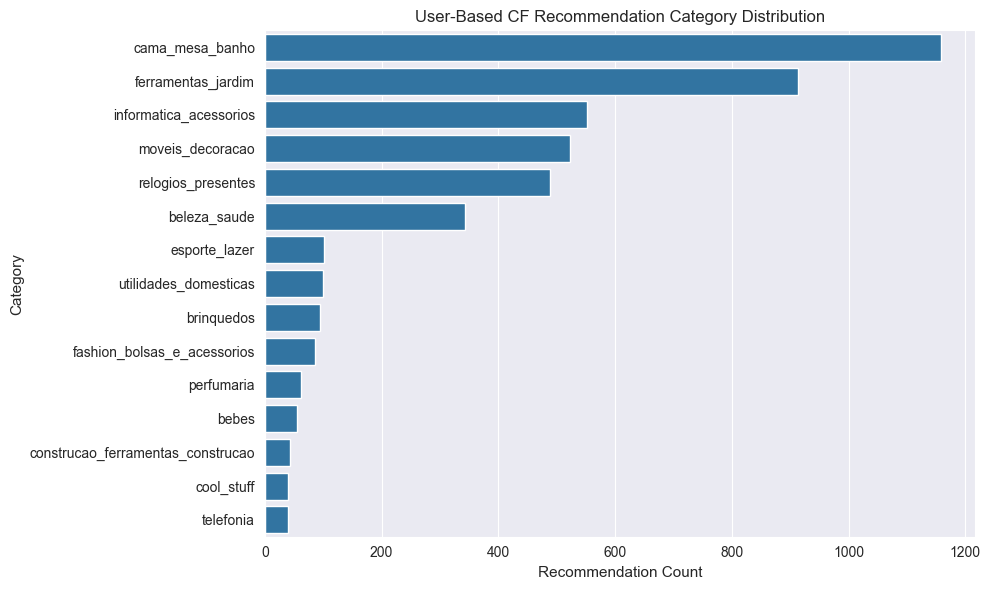

In [61]:
# =========================================================
# 3.4.3 Plot Category Distribution
# =========================================================

plot_user_cf_category = user_cf_category_dist.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_user_cf_category, x='recommendation_count', y='category')
plt.title('User-Based CF Recommendation Category Distribution')
plt.xlabel('Recommendation Count')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig(os.path.join(viz_dir, '06_user_cf_category_distribution.png'), dpi=300)
plt.show()

## User-Based Collaborative Filtering Analysis and Summary

User-Based CF produces usable recommendations for a subset of users, but its coverage remains limited under extreme sparsity. In this project, only **760 users** meet the minimum interaction threshold for standalone user-based recommendation.

The recommendation outputs show a mixed pattern. About **55.78%** of recommendations come from the user-based similarity logic, while **44.22%** still rely on fallback popular products. This suggests that User-Based CF can contribute meaningful signals, but it is not stable enough to serve as the main recommendation method on its own.

The category distribution is also concentrated in a small number of high-frequency categories, which indicates that user-based recommendation in sparse settings may still be biased toward popular product groups. Overall, User-Based CF is useful in this project, but its strongest role is as one component of a broader hybrid recommendation framework.
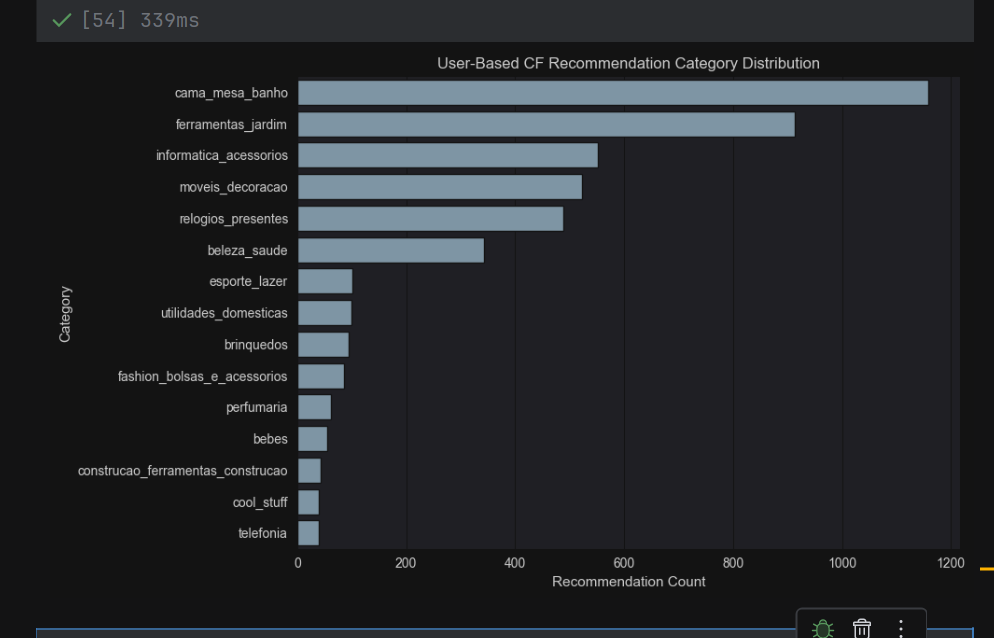
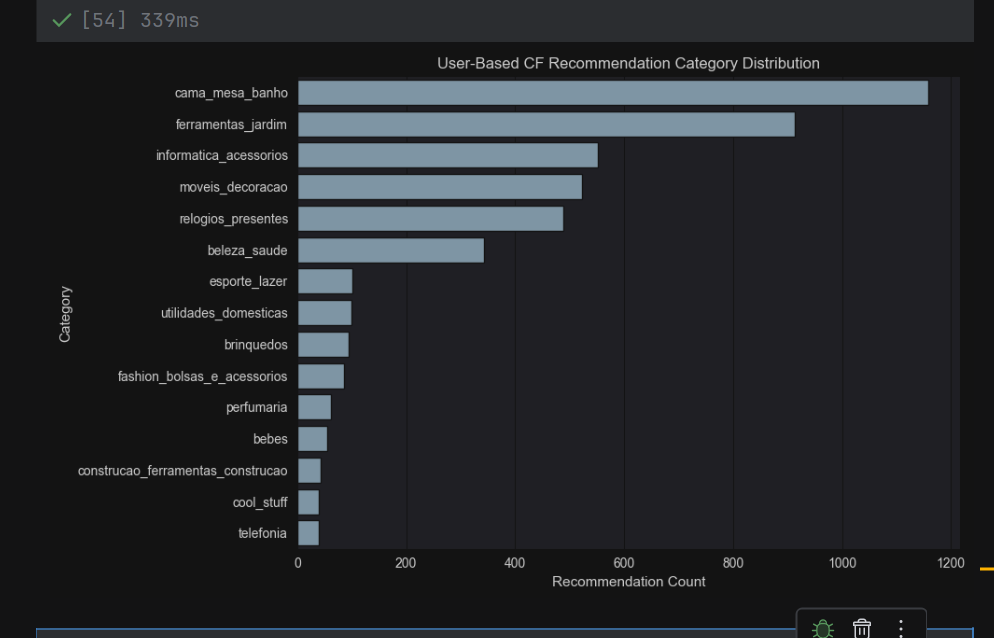
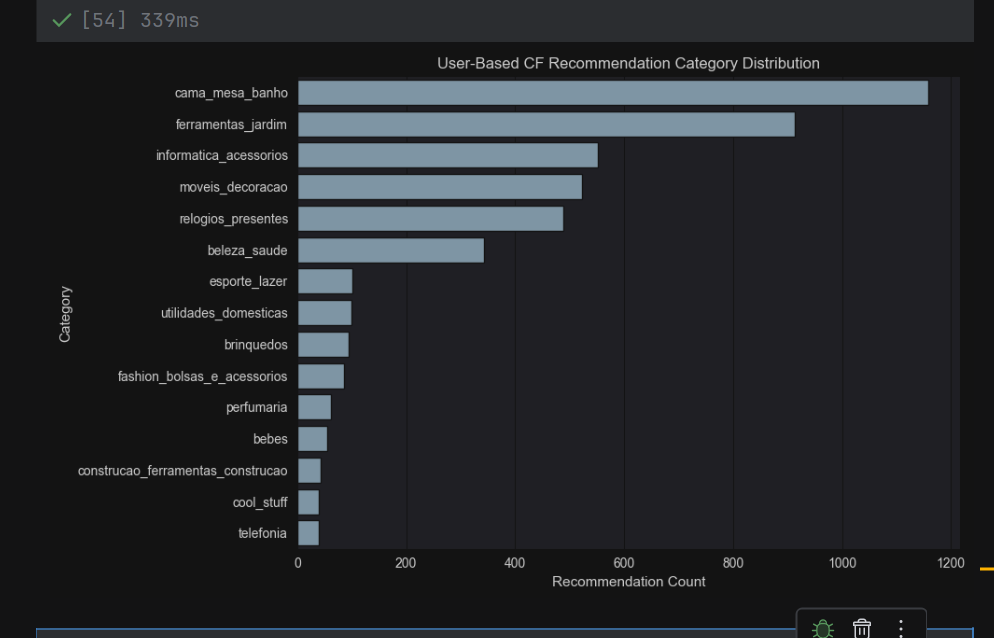

# 4. Algorithm 2 - Item-Based Collaborative Filtering

This chapter implements a lightweight item-based collaborative filtering method. Instead of computing a full dense item-item similarity matrix, the project uses sparse nearest-neighbor search to identify similar products more efficiently.

## 4.1 Item Similarity Modeling

This section models item similarity based on shared user-rating patterns. Compared with user-based recommendation, item-based recommendation is often more stable because item relationships change more slowly than user behavior.

In [62]:
# =========================================================
# 4.1.1 Build Item-User Sparse Matrix
# =========================================================

item_user_sparse = user_item_sparse.T.tocsr()

print("item_user_sparse shape:", item_user_sparse.shape)
print("Number of non-zero entries:", item_user_sparse.nnz)

item_user_sparse shape: (32216, 93358)
Number of non-zero entries: 99785


In [63]:
# =========================================================
# 4.1.2 Fit Item-Based Nearest-Neighbor Model
# =========================================================

item_knn_model = NearestNeighbors(
    metric='cosine',
    algorithm='brute',
    n_neighbors=21,
    n_jobs=-1
)

item_knn_model.fit(item_user_sparse)

print("Item-based nearest-neighbor model fitted successfully.")

Item-based nearest-neighbor model fitted successfully.


In [64]:
# =========================================================
# 4.1.3 Find Similar Items for One Sample Product
# =========================================================

sample_item_idx = 0

distances, indices = item_knn_model.kneighbors(
    item_user_sparse[sample_item_idx],
    n_neighbors=6
)

similar_item_df = pd.DataFrame({
    'neighbor_item_idx': indices.flatten(),
    'cosine_distance': distances.flatten()
})

similar_item_df['cosine_similarity'] = 1 - similar_item_df['cosine_distance']

similar_item_df = similar_item_df.merge(
    item_index.rename(columns={'item_idx': 'neighbor_item_idx', 'product_id': 'neighbor_product_id'}),
    on='neighbor_item_idx',
    how='left'
)

similar_item_df = similar_item_df.merge(
    df_products[['product_id', 'category']].rename(columns={'product_id': 'neighbor_product_id'}),
    on='neighbor_product_id',
    how='left'
)

similar_item_df

,neighbor_item_idx,cosine_distance,cosine_similarity,neighbor_product_id,category
0,0,0.0,1.0,00066f42aeeb9f3007548bb9d3f33c38,perfumaria
1,32208,1.0,0.0,fff1059cd247279f3726b7696c66e44e,esporte_lazer
2,32207,1.0,0.0,fff0a542c3c62682f23305214eaeaa24,papelaria
3,32206,1.0,0.0,ffef256879dbadcab7e77950f4f4a195,artigos_de_natal
4,32205,1.0,0.0,ffedbd68fa6f44e788ff6c2db8094715,livros_tecnicos
5,32204,1.0,0.0,ffeb228c521d5464d1f71444da96c446,telefonia


## Item Similarity Modeling Analysis and Summary

The item-based similarity search runs successfully, but the sample result shows that most neighboring items have very weak similarity signals. Apart from the item itself, the returned products have cosine similarity close to **0**, which reflects the extreme sparsity of shared user-item interactions.

This suggests that direct item-to-item similarity is difficult to estimate reliably in the current dataset. Even though Item-Based CF is structurally more stable than User-Based CF, sparse overlap between products remains a major limitation.

## 4.2 Generate Recommendations

This section recommends new products based on the similarity between candidate items and the products already rated by the user. The final score is calculated as a similarity-weighted average of the user's historical ratings.

In [65]:
# =========================================================
# 4.2.1 Define Item-Based Recommendation Function
# =========================================================

def recommend_item_based(user_id, top_n=10, k_similar_items=20):
    """
    Generate Item-Based CF recommendations using sparse nearest neighbors.
    """
    if user_id not in user_id_to_idx:
        return pd.DataFrame(columns=['product_id', 'predicted_rating', 'score_source'])

    user_idx = int(user_id_to_idx[user_id])
    user_vector = user_item_sparse[user_idx]
    rated_item_indices = user_vector.indices
    rated_item_scores = user_vector.data

    if len(rated_item_indices) == 0:
        return pd.DataFrame(columns=['product_id', 'predicted_rating', 'score_source'])

    predictions = {}

    for rated_item_idx, user_rating in zip(rated_item_indices, rated_item_scores):
        distances, indices = item_knn_model.kneighbors(
            item_user_sparse[rated_item_idx],
            n_neighbors=min(k_similar_items + 1, num_items)
        )

        neighbor_item_indices = indices.flatten()[1:]
        neighbor_similarities = 1 - distances.flatten()[1:]

        for neighbor_idx, sim in zip(neighbor_item_indices, neighbor_similarities):
            if neighbor_idx in rated_item_indices:
                continue
            if sim <= 0:
                continue

            if neighbor_idx not in predictions:
                predictions[neighbor_idx] = {'weighted_sum': 0, 'similarity_sum': 0}

            predictions[neighbor_idx]['weighted_sum'] += sim * user_rating
            predictions[neighbor_idx]['similarity_sum'] += sim

    final_scores = {}
    for item_idx, score_dict in predictions.items():
        if score_dict['similarity_sum'] > 0:
            final_scores[item_idx] = score_dict['weighted_sum'] / score_dict['similarity_sum']

    if len(final_scores) == 0:
        fallback = df_product_sales.sort_values(
            ['sales_count', 'avg_review_score'],
            ascending=[False, False]
        ).head(top_n)[['product_id']].copy()

        fallback['predicted_rating'] = np.nan
        fallback['score_source'] = 'fallback_popular'
        return fallback

    top_items = sorted(final_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]

    result = pd.DataFrame({
        'product_id': [item_idx_to_product_id[item_idx] for item_idx, _ in top_items],
        'predicted_rating': [score for _, score in top_items],
        'score_source': 'item_cf'
    })

    return result

In [66]:
# =========================================================
# 4.2.2 Test Recommendation for One Active User
# =========================================================

active_users = user_rated_count[user_rated_count['rated_product_count'] >= 3].copy()
active_users = active_users.sort_values('rated_product_count', ascending=False)

sample_user_idx = int(active_users.iloc[0]['user_idx'])
sample_user_id = user_index.loc[user_index['user_idx'] == sample_user_idx, 'unique_user_id'].iloc[0]

print("Sample active user:", sample_user_id)
print("Rated product count:", int(active_users.iloc[0]['rated_product_count']))

sample_item_recs = recommend_item_based(sample_user_id, top_n=10, k_similar_items=20)

sample_item_recs = sample_item_recs.merge(
    df_products[['product_id', 'category']],
    on='product_id',
    how='left'
)

sample_item_recs.head(10)

Sample active user: 8d50f5eadf50201ccdcedfb9e2ac8455
Rated product count: 14


,product_id,predicted_rating,score_source,category
0,aca2eb7d00ea1a7b8ebd4e68314663af,NaN,fallback_popular,moveis_decoracao
1,99a4788cb24856965c36a24e339b6058,NaN,fallback_popular,cama_mesa_banho
2,422879e10f46682990de24d770e7f83d,NaN,fallback_popular,ferramentas_jardim
3,389d119b48cf3043d311335e499d9c6b,NaN,fallback_popular,ferramentas_jardim
4,368c6c730842d78016ad823897a372db,NaN,fallback_popular,ferramentas_jardim
5,53759a2ecddad2bb87a079a1f1519f73,NaN,fallback_popular,ferramentas_jardim
6,d1c427060a0f73f6b889a5c7c61f2ac4,NaN,fallback_popular,informatica_acessorios
7,53b36df67ebb7c41585e8d54d6772e08,NaN,fallback_popular,relogios_presentes
8,154e7e31ebfa092203795c972e5804a6,NaN,fallback_popular,beleza_saude
9,3dd2a17168ec895c781a9191c1e95ad7,NaN,fallback_popular,informatica_acessorios


## Generate Recommendations Analysis and Summary

The item-based recommendation pipeline is operational, but the current sample user still receives mainly **fallback popular** recommendations rather than strong similarity-driven results. This indicates that the sparse item-user structure limits the ability of Item-Based CF to generate robust personalized recommendations on its own.

Compared with User-Based CF, Item-Based CF remains a useful component, but the current results suggest that it should also be combined with other methods in the later hybrid recommendation stage.

## 4.3 Batch Recommendation

This section generates Item-Based CF recommendations for users with sufficient interaction history. The goal is to examine whether item-based recommendation can produce more stable output than user-based recommendation under sparse conditions.

In [67]:
# =========================================================
# 4.3.1 Select Eligible Users
# =========================================================

eligible_user_df_item = user_rated_count[user_rated_count['rated_product_count'] >= 3].copy()
eligible_user_df_item = eligible_user_df_item.sort_values('rated_product_count', ascending=False)

eligible_user_df_item = eligible_user_df_item.merge(
    user_index[['user_idx', 'unique_user_id']],
    on='user_idx',
    how='left'
)

print("Eligible users for Item-CF:", len(eligible_user_df_item))
eligible_user_df_item.head()




Eligible users for Item-CF: 760


,user_idx,rated_product_count,unique_user_id
0,51431,14,8d50f5eadf50201ccdcedfb9e2ac8455
1,22779,13,3e43e6105506432c953e165fb2acf44c
2,73921,9,ca77025e7201e3b30c44b472ff346268
3,10060,9,1b6c7548a2a1f9037c1fd3ddfed95f33
4,73378,8,c8ed31310fc440a3f8031b177f9842c3


In [68]:
# =========================================================
# 4.3.2 Batch Generate Recommendations
# =========================================================

item_based_results = []

for _, row in eligible_user_df_item.iterrows():
    user_id = row['unique_user_id']
    recs = recommend_item_based(user_id, top_n=10, k_similar_items=20)

    if not recs.empty:
        recs = recs.copy()
        recs['unique_user_id'] = user_id
        recs['rated_product_count'] = row['rated_product_count']
        item_based_results.append(recs)

df_item_based_recs = pd.concat(item_based_results, ignore_index=True) if item_based_results else pd.DataFrame()

print("df_item_based_recs shape:", df_item_based_recs.shape)
df_item_based_recs.head()

df_item_based_recs shape: (5129, 5)


,product_id,predicted_rating,score_source,unique_user_id,rated_product_count
0,aca2eb7d00ea1a7b8ebd4e68314663af,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14
1,99a4788cb24856965c36a24e339b6058,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14
2,422879e10f46682990de24d770e7f83d,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14
3,389d119b48cf3043d311335e499d9c6b,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14
4,368c6c730842d78016ad823897a372db,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14


In [69]:
# =========================================================
# 4.3.3 Attach Product Category
# =========================================================

drop_cols = [col for col in ['category', 'category_x', 'category_y'] if col in df_item_based_recs.columns]
if drop_cols:
    df_item_based_recs = df_item_based_recs.drop(columns=drop_cols)

df_item_based_recs = df_item_based_recs.merge(
    df_products[['product_id', 'category']],
    on='product_id',
    how='left'
)

print("df_item_based_recs shape after merge:", df_item_based_recs.shape)
print(df_item_based_recs.columns.tolist())
df_item_based_recs.head()

df_item_based_recs shape after merge: (5129, 6)
['product_id', 'predicted_rating', 'score_source', 'unique_user_id', 'rated_product_count', 'category']


,product_id,predicted_rating,score_source,unique_user_id,rated_product_count,category
0,aca2eb7d00ea1a7b8ebd4e68314663af,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14,moveis_decoracao
1,99a4788cb24856965c36a24e339b6058,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14,cama_mesa_banho
2,422879e10f46682990de24d770e7f83d,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14,ferramentas_jardim
3,389d119b48cf3043d311335e499d9c6b,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14,ferramentas_jardim
4,368c6c730842d78016ad823897a372db,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14,ferramentas_jardim


In [70]:
# =========================================================
# 4.3.4 Save Recommendation Results
# =========================================================

item_based_path = os.path.join(rec_dir, "recommendations_item_based.csv")
df_item_based_recs.to_csv(item_based_path, index=False)

print("Saved:", item_based_path)

Saved: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\08_recommendation_system\recommendations\recommendations_item_based.csv


## 4.4 Recommendation Pattern Check

This section checks the structure of Item-Based CF outputs, including score source and category distribution.

In [71]:
# =========================================================
# 4.4.1 Check Score Source Distribution
# =========================================================

item_score_source_dist = (
    df_item_based_recs['score_source']
    .value_counts(dropna=False)
    .reset_index()
)

item_score_source_dist.columns = ['score_source', 'count']
item_score_source_dist['share'] = item_score_source_dist['count'] / item_score_source_dist['count'].sum()

item_score_source_dist

,score_source,count,share
0,item_cf,3199,0.623708
1,fallback_popular,1930,0.376292


In [72]:
# =========================================================
# 4.4.2 Check Category Distribution
# =========================================================

category_col = None
for col in ['category', 'category_x', 'category_y']:
    if col in df_item_based_recs.columns:
        category_col = col
        break

if category_col is None:
    raise KeyError("No category column found in df_item_based_recs. Please run 4.3.3 first.")

item_cf_category_dist = (
    df_item_based_recs[category_col]
    .fillna('Unknown')
    .value_counts()
    .reset_index()
)

item_cf_category_dist.columns = ['category', 'recommendation_count']
item_cf_category_dist['share'] = (
    item_cf_category_dist['recommendation_count'] /
    item_cf_category_dist['recommendation_count'].sum()
)

item_cf_category_dist.head(15)

,category,recommendation_count,share
0,cama_mesa_banho,1263,0.246247
1,ferramentas_jardim,821,0.160070
2,moveis_decoracao,563,0.109768
3,informatica_acessorios,525,0.102359
4,relogios_presentes,485,0.094560
5,beleza_saude,325,0.063365
6,utilidades_domesticas,134,0.026126
7,esporte_lazer,125,0.024371
8,brinquedos,105,0.020472
9,fashion_bolsas_e_acessorios,100,0.019497


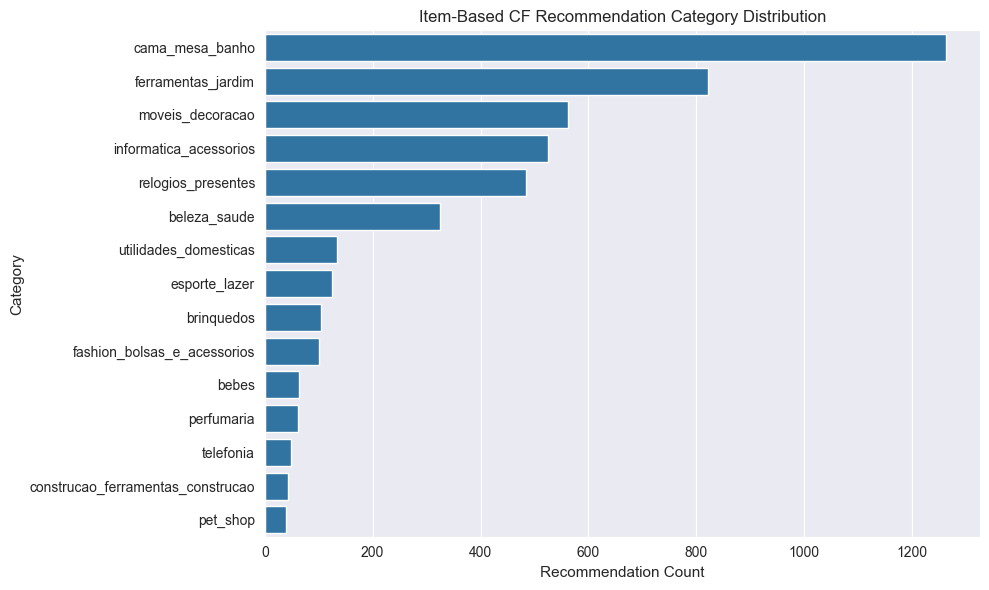

In [73]:
# =========================================================
# 4.4.3 Plot Category Distribution
# =========================================================

plot_item_cf_category = item_cf_category_dist.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_item_cf_category, x='recommendation_count', y='category')
plt.title('Item-Based CF Recommendation Category Distribution')
plt.xlabel('Recommendation Count')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig(os.path.join(viz_dir, '07_item_cf_category_distribution.png'), dpi=300)
plt.show()

# 5. Algorithm 3 - Content-Based Recommendation

This chapter implements a content-based recommendation method using product attributes and historical product-level features. Unlike collaborative filtering, this method does not depend entirely on user overlap, so it is more suitable for sparse interaction settings and cold-start scenarios.

## 5.1 Product Feature Engineering

This section constructs product-level content features for similarity modeling. The feature set combines product category, physical attributes, and historical product performance indicators.

In [74]:
# =========================================================
# 5.1.1 Build Enhanced Product Feature Base Table
# =========================================================

df_product_features = df_products.merge(
    df_product_sales[
        ['product_id', 'sales_count', 'avg_price', 'avg_review_score', 'review_count']
    ],
    on='product_id',
    how='left'
).copy()

# Fill core numeric fields
for col in ['sales_count', 'avg_price', 'avg_review_score', 'review_count']:
    if col not in df_product_features.columns:
        df_product_features[col] = 0
    df_product_features[col] = pd.to_numeric(
        df_product_features[col],
        errors='coerce'
    ).fillna(0)

# Clean category
df_product_features['category'] = df_product_features['category'].fillna('Unknown')

# ------------------------------
# Add price features
# ------------------------------
df_product_features['price_rank'] = df_product_features['avg_price'].rank(pct=True)

df_product_features['price_tier'] = pd.cut(
    df_product_features['avg_price'],
    bins=[-np.inf, 50, 100, 200, np.inf],
    labels=['low', 'mid', 'high', 'premium']
)

# ------------------------------
# Add sales features
# ------------------------------
df_product_features['sales_rank'] = df_product_features['sales_count'].rank(pct=True)

df_product_features['sales_tier'] = pd.cut(
    df_product_features['sales_count'],
    bins=[-1, 10, 50, 200, np.inf],
    labels=['niche', 'regular', 'popular', 'bestseller']
)

# ------------------------------
# Add review-quality features
# ------------------------------
global_mean_rating = df_product_features['avg_review_score'].replace(0, np.nan).mean()
if pd.isna(global_mean_rating):
    global_mean_rating = 0

C = 10
df_product_features['bayesian_rating'] = (
    (df_product_features['review_count'] * df_product_features['avg_review_score'] + C * global_mean_rating) /
    (df_product_features['review_count'] + C)
)

print("df_product_features shape:", df_product_features.shape)
display(
    df_product_features[
        ['product_id', 'category', 'sales_count', 'avg_price',
         'avg_review_score', 'review_count', 'price_rank',
         'sales_rank', 'bayesian_rating']
    ].head()
)

df_product_features shape: (32951, 15)


,product_id,category,sales_count,avg_price,avg_review_score,review_count,price_rank,sales_rank,bayesian_rating
0,00066f42aeeb9f3007548bb9d3f33c38,perfumaria,1,101.65,5.0,1,0.605520,0.273967,4.137256
1,00088930e925c41fd95ebfe695fd2655,automotivo,1,129.90,4.0,1,0.689585,0.273967,4.046347
2,0009406fd7479715e4bef61dd91f2462,cama_mesa_banho,1,229.00,1.0,1,0.857212,0.273967,3.773619
3,000b8f95fcb9e0096488278317764d19,utilidades_domesticas,2,58.90,5.0,2,0.381597,0.636491,4.209151
4,000d9be29b5207b54e86aa1b1ac54872,relogios_presentes,1,199.00,5.0,1,0.826121,0.273967,4.137256


In [75]:
# =========================================================
# 5.1.2 One-Hot Encode Category / Price Tier / Sales Tier
# =========================================================

category_encoded = pd.get_dummies(
    df_product_features['category'],
    prefix='cat'
)

price_tier_encoded = pd.get_dummies(
    df_product_features['price_tier'],
    prefix='price_tier'
)

sales_tier_encoded = pd.get_dummies(
    df_product_features['sales_tier'],
    prefix='sales_tier'
)

print("category_encoded shape:", category_encoded.shape)
print("price_tier_encoded shape:", price_tier_encoded.shape)
print("sales_tier_encoded shape:", sales_tier_encoded.shape)

category_encoded shape: (32951, 74)
price_tier_encoded shape: (32951, 4)
sales_tier_encoded shape: (32951, 4)


In [76]:
# =========================================================
# 5.1.3 Standardize Enhanced Numeric Features
# =========================================================

numeric_features = [
    'weight_g',
    'length_cm',
    'height_cm',
    'width_cm',
    'sales_count',
    'avg_price',
    'avg_review_score',
    'review_count',
    'price_rank',
    'sales_rank',
    'bayesian_rating'
]

for col in numeric_features:
    if col not in df_product_features.columns:
        df_product_features[col] = 0
    df_product_features[col] = pd.to_numeric(
        df_product_features[col],
        errors='coerce'
    ).fillna(0)

scaler = StandardScaler()
numeric_scaled = scaler.fit_transform(df_product_features[numeric_features])

numeric_scaled_df = pd.DataFrame(
    numeric_scaled,
    columns=numeric_features,
    index=df_product_features.index
)

print("numeric_scaled_df shape:", numeric_scaled_df.shape)
display(numeric_scaled_df.head())

numeric_scaled_df shape: (32951, 11)


,weight_g,length_cm,height_cm,width_cm,sales_count,avg_price,avg_review_score,review_count,price_rank,sales_rank,bayesian_rating
0,-0.461558,-0.639253,-0.068680,-0.595647,-0.227865,-0.176810,0.778369,-0.226055,0.365484,-0.859883,0.457474
1,-0.245531,1.429869,-0.508641,0.232178,-0.227865,-0.062388,-0.011624,-0.226055,0.656693,-0.859883,-0.013214
2,-0.461558,0.838691,-0.142007,0.977221,-0.227865,0.339002,-2.381602,-0.226055,1.237377,-0.859883,-1.425279
3,-0.403172,-0.698370,0.517934,-0.926776,-0.134109,-0.349963,0.778369,-0.131152,-0.410216,0.519151,0.829717
4,-0.473235,-0.521017,-0.435315,-0.678429,-0.227865,0.217492,0.778369,-0.226055,1.129672,-0.859883,0.457474


In [77]:
# =========================================================
# 5.1.4 Combine Enhanced Content Features
# =========================================================

content_features = pd.concat(
    [
        category_encoded.reset_index(drop=True),
        price_tier_encoded.reset_index(drop=True),
        sales_tier_encoded.reset_index(drop=True),
        numeric_scaled_df.reset_index(drop=True)
    ],
    axis=1
)

content_features.index = df_product_features['product_id']

print("content_features shape:", content_features.shape)
display(content_features.head())

content_features shape: (32951, 93)


,cat_Unknown,cat_agro_industria_e_comercio,cat_alimentos,cat_alimentos_bebidas,cat_artes,cat_artes_e_artesanato,cat_artigos_de_festas,cat_artigos_de_natal,cat_audio,cat_automotivo,cat_bebes,cat_bebidas,cat_beleza_saude,cat_brinquedos,cat_cama_mesa_banho,cat_casa_conforto,cat_casa_conforto_2,cat_casa_construcao,cat_cds_dvds_musicais,cat_cine_foto,cat_climatizacao,cat_consoles_games,cat_construcao_ferramentas_construcao,cat_construcao_ferramentas_ferramentas,cat_construcao_ferramentas_iluminacao,cat_construcao_ferramentas_jardim,cat_construcao_ferramentas_seguranca,cat_cool_stuff,cat_dvds_blu_ray,cat_eletrodomesticos,cat_eletrodomesticos_2,cat_eletronicos,cat_eletroportateis,cat_esporte_lazer,cat_fashion_bolsas_e_acessorios,cat_fashion_calcados,cat_fashion_esporte,cat_fashion_roupa_feminina,cat_fashion_roupa_infanto_juvenil,cat_fashion_roupa_masculina,cat_fashion_underwear_e_moda_praia,cat_ferramentas_jardim,cat_flores,cat_fraldas_higiene,cat_industria_comercio_e_negocios,cat_informatica_acessorios,cat_instrumentos_musicais,cat_la_cuisine,cat_livros_importados,cat_livros_interesse_geral,cat_livros_tecnicos,cat_malas_acessorios,cat_market_place,cat_moveis_colchao_e_estofado,cat_moveis_cozinha_area_de_servico_jantar_e_jardim,cat_moveis_decoracao,cat_moveis_escritorio,cat_moveis_quarto,cat_moveis_sala,cat_musica,cat_papelaria,cat_pc_gamer,cat_pcs,cat_perfumaria,cat_pet_shop,cat_portateis_casa_forno_e_cafe,cat_portateis_cozinha_e_preparadores_de_alimentos,cat_relogios_presentes,cat_seguros_e_servicos,cat_sinalizacao_e_seguranca,cat_tablets_impressao_imagem,cat_telefonia,cat_telefonia_fixa,cat_utilidades_domesticas,price_tier_low,price_tier_mid,price_tier_high,price_tier_premium,sales_tier_niche,sales_tier_regular,sales_tier_popular,sales_tier_bestseller,weight_g,length_cm,height_cm,width_cm,sales_count,avg_price,avg_review_score,review_count,price_rank,sales_rank,bayesian_rating
product_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
00066f42aeeb9f3007548bb9d3f33c38,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,-0.461558,-0.639253,-0.068680,-0.595647,-0.227865,-0.176810,0.778369,-0.226055,0.365484,-0.859883,0.457474
00088930e925c41fd95ebfe695fd2655,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,-0.245531,1.429869,-0.508641,0.232178,-0.227865,-0.062388,-0.011624,-0.226055,0.656693,-0.859883,-0.013214
0009406fd7479715e4bef61dd91f2462,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,-0.461558,0.838691,-0.142007,0.977221,-0.227865,0.339002,-2.381602,-0.226055,1.237377,-0.859883,-1.425279
000b8f95fcb9e0096488278317764d19,False,False,False,False,False,False,False,False,False,False,False,False

In [78]:
# =========================================================
# 5.1.5 Save Content Features
# =========================================================

content_features_path = os.path.join(data_dir, "content_features.csv")
content_features.to_csv(content_features_path)

print("Saved:", content_features_path)

Saved: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\08_recommendation_system\data\content_features.csv


## Product Feature Engineering Analysis and Summary

The product feature table is successfully constructed with **32,951 products** and **82 content features**. Compared with collaborative filtering, this feature space is more compact and less affected by sparse user overlap.

This makes content-based recommendation especially important in the current project, because product attributes can provide a more stable basis for recommendation when interaction data is limited.

## 5.2 Content Similarity Modeling

This section models products similarity based on content features. Since the feature space is relatively compact, content similarity can be estimated more stably than collaborative similarity in sparse recommendation settings.

In [79]:
# =========================================================
# 5.2.1 Prepare Content Feature Matrix for Modeling
# =========================================================

content_features_model = content_features.astype(float).copy()

content_product_ids = content_features_model.index.tolist()
content_product_id_to_idx = {pid: i for i, pid in enumerate(content_product_ids)}
content_idx_to_product_id = {i: pid for i, pid in enumerate(content_product_ids)}

print("content_features_model shape:", content_features_model.shape)
content_features_model.head()

content_features_model shape: (32951, 93)


,cat_Unknown,cat_agro_industria_e_comercio,cat_alimentos,cat_alimentos_bebidas,cat_artes,cat_artes_e_artesanato,cat_artigos_de_festas,cat_artigos_de_natal,cat_audio,cat_automotivo,cat_bebes,cat_bebidas,cat_beleza_saude,cat_brinquedos,cat_cama_mesa_banho,cat_casa_conforto,cat_casa_conforto_2,cat_casa_construcao,cat_cds_dvds_musicais,cat_cine_foto,cat_climatizacao,cat_consoles_games,cat_construcao_ferramentas_construcao,cat_construcao_ferramentas_ferramentas,cat_construcao_ferramentas_iluminacao,cat_construcao_ferramentas_jardim,cat_construcao_ferramentas_seguranca,cat_cool_stuff,cat_dvds_blu_ray,cat_eletrodomesticos,cat_eletrodomesticos_2,cat_eletronicos,cat_eletroportateis,cat_esporte_lazer,cat_fashion_bolsas_e_acessorios,cat_fashion_calcados,cat_fashion_esporte,cat_fashion_roupa_feminina,cat_fashion_roupa_infanto_juvenil,cat_fashion_roupa_masculina,cat_fashion_underwear_e_moda_praia,cat_ferramentas_jardim,cat_flores,cat_fraldas_higiene,cat_industria_comercio_e_negocios,cat_informatica_acessorios,cat_instrumentos_musicais,cat_la_cuisine,cat_livros_importados,cat_livros_interesse_geral,cat_livros_tecnicos,cat_malas_acessorios,cat_market_place,cat_moveis_colchao_e_estofado,cat_moveis_cozinha_area_de_servico_jantar_e_jardim,cat_moveis_decoracao,cat_moveis_escritorio,cat_moveis_quarto,cat_moveis_sala,cat_musica,cat_papelaria,cat_pc_gamer,cat_pcs,cat_perfumaria,cat_pet_shop,cat_portateis_casa_forno_e_cafe,cat_portateis_cozinha_e_preparadores_de_alimentos,cat_relogios_presentes,cat_seguros_e_servicos,cat_sinalizacao_e_seguranca,cat_tablets_impressao_imagem,cat_telefonia,cat_telefonia_fixa,cat_utilidades_domesticas,price_tier_low,price_tier_mid,price_tier_high,price_tier_premium,sales_tier_niche,sales_tier_regular,sales_tier_popular,sales_tier_bestseller,weight_g,length_cm,height_cm,width_cm,sales_count,avg_price,avg_review_score,review_count,price_rank,sales_rank,bayesian_rating
product_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
00066f42aeeb9f3007548bb9d3f33c38,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,-0.461558,-0.639253,-0.068680,-0.595647,-0.227865,-0.176810,0.778369,-0.226055,0.365484,-0.859883,0.457474
00088930e925c41fd95ebfe695fd2655,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,-0.245531,1.429869,-0.508641,0.232178,-0.227865,-0.062388,-0.011624,-0.226055,0.656693,-0.859883,-0.013214
0009406fd7479715e4bef61dd91f2462,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,-0.461558,0.838691,-0.142007,0.977221,-0.227865,0.339002,-2.381602,-0.226055,1.237377,-0.859883,-1.425279
000b8f95fcb9e0096488278317764d19,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,-0.403172,-0.698370,0.517934,-0.926776,-0.134109,-0.349963,0.778369,-0.131152,-0.410216,0.519151,0.829717
000d9be29b5207b54e86aa1b1ac54872,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0

In [80]:
# =========================================================
# 5.2.2 Fit Content-Based Nearest-Neighbor Model
# =========================================================

content_knn_model = NearestNeighbors(
    metric='cosine',
    algorithm='brute',
    n_neighbors=21,
    n_jobs=-1
)

content_knn_model.fit(content_features_model.values)

print("Content-based nearest-neighbor model fitted successfully.")

Content-based nearest-neighbor model fitted successfully.


In [81]:
# =========================================================
# 5.2.3 Find Similar Products for One Sample Product
# =========================================================

sample_content_idx = 0

distances, indices = content_knn_model.kneighbors(
    content_features_model.values[sample_content_idx].reshape(1, -1),
    n_neighbors=6
)

similar_content_df = pd.DataFrame({
    'neighbor_content_idx': indices.flatten(),
    'cosine_distance': distances.flatten()
})

similar_content_df['cosine_similarity'] = 1 - similar_content_df['cosine_distance']
similar_content_df['neighbor_product_id'] = similar_content_df['neighbor_content_idx'].map(content_idx_to_product_id)

similar_content_df = similar_content_df.merge(
    df_products[['product_id', 'category']].rename(columns={'product_id': 'neighbor_product_id'}),
    on='neighbor_product_id',
    how='left'
)

similar_content_df

,neighbor_content_idx,cosine_distance,cosine_similarity,neighbor_product_id,category
0,0,0.000000,1.000000,00066f42aeeb9f3007548bb9d3f33c38,perfumaria
1,12152,0.007565,0.992435,5dc01f0525d00d0b349bf2ff92f7d1a2,perfumaria
2,12696,0.007707,0.992293,624a71194ff2a5badf71b7870f88f24f,perfumaria
3,28401,0.010182,0.989818,dc582e9ac5036846acfeeb3093b17aa7,perfumaria
4,5200,0.011777,0.988223,274a778944c803fb95ea5a5b2c50611b,perfumaria
5,12481,0.012583,0.987417,605d9e1329e4d2e960090c8da53d9c86,perfumaria


## Content Similarity Modeling Analysis and Summary

The content similarity model runs successfully and produces strong similarity signals between products with similar attributes. Unlike collaborative filtering, this similarity structure is not constrained by sparse user overlap, which makes it more stable in the current project.

The sample result also shows that content-based similarity is highly sensitive to shared category and product attributes. This provides a strong basis for recommendation, but it may also increase the risk of over-concentration within narrow product groups.

## 5.3 Generate Recommendations

This section generates recommendations by matching a user's historical products with content-similar products. The final recommendation score is based on both product similarity and the user's historical rating strength.

In [82]:
# =========================================================
# 5.3.1 Define Content-Based Recommendation Function
# =========================================================

item_idx_to_product_id = item_index.set_index('item_idx')['product_id'].to_dict()
user_id_to_idx = user_index.set_index('unique_user_id')['user_idx'].to_dict()

def recommend_content_based(user_id, top_n=10, k_similar_items=20):
    """
    Generate Content-Based recommendations using product content similarity.
    """
    if user_id not in user_id_to_idx:
        return pd.DataFrame(columns=['product_id', 'predicted_rating', 'score_source'])

    user_idx = int(user_id_to_idx[user_id])
    user_vector = user_item_sparse[user_idx]
    rated_item_indices = user_vector.indices
    rated_item_scores = user_vector.data

    if len(rated_item_indices) == 0:
        return pd.DataFrame(columns=['product_id', 'predicted_rating', 'score_source'])

    rated_product_ids = [
        item_idx_to_product_id[item_idx]
        for item_idx in rated_item_indices
        if item_idx in item_idx_to_product_id
    ]

    rated_product_set = set(rated_product_ids)
    predictions = {}

    for product_id, user_rating in zip(rated_product_ids, rated_item_scores):
        if product_id not in content_product_id_to_idx:
            continue

        content_idx = content_product_id_to_idx[product_id]

        distances, indices = content_knn_model.kneighbors(
            content_features_model.values[content_idx].reshape(1, -1),
            n_neighbors=min(k_similar_items + 1, len(content_product_ids))
        )

        neighbor_content_indices = indices.flatten()[1:]
        neighbor_similarities = 1 - distances.flatten()[1:]

        for neighbor_idx, sim in zip(neighbor_content_indices, neighbor_similarities):
            neighbor_product_id = content_idx_to_product_id[neighbor_idx]

            if neighbor_product_id in rated_product_set:
                continue
            if sim <= 0:
                continue

            if neighbor_product_id not in predictions:
                predictions[neighbor_product_id] = {'weighted_sum': 0, 'similarity_sum': 0}

            predictions[neighbor_product_id]['weighted_sum'] += sim * user_rating
            predictions[neighbor_product_id]['similarity_sum'] += sim

    final_scores = {}
    for product_id, score_dict in predictions.items():
        if score_dict['similarity_sum'] > 0:
            final_scores[product_id] = score_dict['weighted_sum'] / score_dict['similarity_sum']

    if len(final_scores) == 0:
        fallback = df_product_sales.sort_values(
            ['sales_count', 'avg_review_score'],
            ascending=[False, False]
        ).head(top_n)[['product_id']].copy()

        fallback['predicted_rating'] = np.nan
        fallback['score_source'] = 'fallback_popular'
        return fallback

    top_items = sorted(final_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]

    result = pd.DataFrame({
        'product_id': [pid for pid, _ in top_items],
        'predicted_rating': [score for _, score in top_items],
        'score_source': 'content_based'
    })

    return result

In [83]:
# =========================================================
# 5.3.2 Test Recommendation for One Active User
# =========================================================

active_users = user_rated_count[user_rated_count['rated_product_count'] >= 3].copy()
active_users = active_users.sort_values('rated_product_count', ascending=False)

sample_user_idx = int(active_users.iloc[0]['user_idx'])
sample_user_id = user_index.loc[user_index['user_idx'] == sample_user_idx, 'unique_user_id'].iloc[0]

print("Sample active user:", sample_user_id)
print("Rated product count:", int(active_users.iloc[0]['rated_product_count']))

sample_content_recs = recommend_content_based(sample_user_id, top_n=10, k_similar_items=20)

sample_content_recs = sample_content_recs.merge(
    df_products[['product_id', 'category']],
    on='product_id',
    how='left'
)

sample_content_recs.head(10)

Sample active user: 8d50f5eadf50201ccdcedfb9e2ac8455
Rated product count: 14


,product_id,predicted_rating,score_source,category
0,cde1665c376260772c25ed5dba63bd82,4.092363,content_based,esporte_lazer
1,3b17509fe0ed9bc707f338cdeed4fb45,4.092363,content_based,esporte_lazer
2,154e46f42e5665a0af25d2fc7c9e3321,4.092363,content_based,esporte_lazer
3,60bf0da113cefe56a54ccc46f7758563,4.092363,content_based,esporte_lazer
4,48aaba1523759485364bcd94f4d4c4f5,4.092363,content_based,esporte_lazer
5,2235d08138bfce7801a73463a3168ea5,4.092363,content_based,esporte_lazer
6,400a34a0f268b8c1d7e6dd793d8c7ee4,4.092363,content_based,esporte_lazer
7,c60c5d18a948f105c5dc3585ef3051d6,4.092363,content_based,esporte_lazer
8,89c5f56df4c7712aa9b0aefb21743989,4.092363,content_based,esporte_lazer
9,4a7c466c35cfb5fec7d60f9548623cc7,4.092363,content_based,esporte_lazer


## Content-Based Recommendation Analysis and Summary

The content-based recommendation pipeline produces stable personalized outputs for the sample user, and all recommended products come directly from content similarity rather than fallback logic. This suggests that content-based recommendation is more than collaborative filtering in the current sparse setting.

At the same time, the recommended products are highly concentrated in the same category, which indicates limited diversity. Therefore, Content-Based recommendation is strong as a standalone signal, but it still needs to be balanced with other methods in the later hybrid recommendation stage.

## 5.4 Batch Recommendation

This section generates Content-Based recommendations for users with sufficient interaction history and checks whether this method can produce stable outputs at scale.

In [84]:
# =========================================================
# 5.4.1 Select Eligible Users
# =========================================================

eligible_user_df_content = user_rated_count[user_rated_count['rated_product_count'] >= 3].copy()
eligible_user_df_content = eligible_user_df_content.sort_values('rated_product_count', ascending=False)

eligible_user_df_content = eligible_user_df_content.merge(
    user_index[['user_idx', 'unique_user_id']],
    on='user_idx',
    how='left'
)

print("Eligible users for Content-Based:", len(eligible_user_df_content))
eligible_user_df_content.head()

Eligible users for Content-Based: 760


,user_idx,rated_product_count,unique_user_id
0,51431,14,8d50f5eadf50201ccdcedfb9e2ac8455
1,22779,13,3e43e6105506432c953e165fb2acf44c
2,73921,9,ca77025e7201e3b30c44b472ff346268
3,10060,9,1b6c7548a2a1f9037c1fd3ddfed95f33
4,73378,8,c8ed31310fc440a3f8031b177f9842c3


In [85]:
# =========================================================
# 5.4.2 Batch Generate Recommendations
# =========================================================

content_based_results = []

for _, row in eligible_user_df_content.iterrows():
    user_id = row['unique_user_id']
    recs = recommend_content_based(user_id, top_n=50, k_similar_items=20)

    if not recs.empty:
        recs = recs.copy()
        recs['unique_user_id'] = user_id
        recs['rated_product_count'] = row['rated_product_count']
        content_based_results.append(recs)

df_content_recs = pd.concat(content_based_results, ignore_index=True) if content_based_results else pd.DataFrame()

print("df_content_recs shape:", df_content_recs.shape)
df_content_recs.head()

df_content_recs shape: (35986, 5)


,product_id,predicted_rating,score_source,unique_user_id,rated_product_count
0,cde1665c376260772c25ed5dba63bd82,4.092363,content_based,8d50f5eadf50201ccdcedfb9e2ac8455,14
1,3b17509fe0ed9bc707f338cdeed4fb45,4.092363,content_based,8d50f5eadf50201ccdcedfb9e2ac8455,14
2,154e46f42e5665a0af25d2fc7c9e3321,4.092363,content_based,8d50f5eadf50201ccdcedfb9e2ac8455,14
3,60bf0da113cefe56a54ccc46f7758563,4.092363,content_based,8d50f5eadf50201ccdcedfb9e2ac8455,14
4,48aaba1523759485364bcd94f4d4c4f5,4.092363,content_based,8d50f5eadf50201ccdcedfb9e2ac8455,14


In [86]:
# =========================================================
# 5.4.3 Attach Product Category
# =========================================================

drop_cols = [col for col in ['category', 'category_x', 'category_y'] if col in df_content_recs.columns]
if drop_cols:
    df_content_recs = df_content_recs.drop(columns=drop_cols)

df_content_recs = df_content_recs.merge(
    df_products[['product_id', 'category']],
    on='product_id',
    how='left'
)

print("df_content_recs shape after merge:", df_content_recs.shape)
print(df_content_recs.columns.tolist())
df_content_recs.head()

df_content_recs shape after merge: (35986, 6)
['product_id', 'predicted_rating', 'score_source', 'unique_user_id', 'rated_product_count', 'category']


,product_id,predicted_rating,score_source,unique_user_id,rated_product_count,category
0,cde1665c376260772c25ed5dba63bd82,4.092363,content_based,8d50f5eadf50201ccdcedfb9e2ac8455,14,esporte_lazer
1,3b17509fe0ed9bc707f338cdeed4fb45,4.092363,content_based,8d50f5eadf50201ccdcedfb9e2ac8455,14,esporte_lazer
2,154e46f42e5665a0af25d2fc7c9e3321,4.092363,content_based,8d50f5eadf50201ccdcedfb9e2ac8455,14,esporte_lazer
3,60bf0da113cefe56a54ccc46f7758563,4.092363,content_based,8d50f5eadf50201ccdcedfb9e2ac8455,14,esporte_lazer
4,48aaba1523759485364bcd94f4d4c4f5,4.092363,content_based,8d50f5eadf50201ccdcedfb9e2ac8455,14,esporte_lazer


In [87]:
# =========================================================
# 5.4.4 Save Recommendation Results
# =========================================================

content_based_path = os.path.join(rec_dir, "recommendations_content.csv")
df_content_recs.to_csv(content_based_path, index=False)

print("Saved:", content_based_path)

Saved: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\08_recommendation_system\recommendations\recommendations_content.csv


## 5.5 Recommendation Pattern Check

This section checks the structure of Content-Based recommendation outputs, including score source and category concentration.

In [88]:
# =========================================================
# 5.5.1 Check Score Source Distribution
# =========================================================

content_score_source_dist = (
    df_content_recs['score_source']
    .value_counts(dropna=False)
    .reset_index()
)

content_score_source_dist.columns = ['score_source', 'count']
content_score_source_dist['share'] = content_score_source_dist['count'] / content_score_source_dist['count'].sum()

content_score_source_dist

,score_source,count,share
0,content_based,35986,1.0


In [89]:
# =========================================================
# 5.5.2 Check Category Distribution
# =========================================================

category_col = None
for col in ['category', 'category_x', 'category_y']:
    if col in df_content_recs.columns:
        category_col = col
        break

if category_col is None:
    raise KeyError("No category column found in df_content_recs. Please run 5.4.3 first.")

content_category_dist = (
    df_content_recs[category_col]
    .fillna('Unknown')
    .value_counts()
    .reset_index()
)

content_category_dist.columns = ['category', 'recommendation_count']
content_category_dist['share'] = (
    content_category_dist['recommendation_count'] /
    content_category_dist['recommendation_count'].sum()
)

content_category_dist.head(15)

,category,recommendation_count,share
0,cama_mesa_banho,8145,0.226338
1,moveis_decoracao,4504,0.125160
2,utilidades_domesticas,2310,0.064192
3,beleza_saude,2282,0.063414
4,esporte_lazer,2211,0.061441
5,relogios_presentes,1911,0.053104
6,informatica_acessorios,1876,0.052131
7,fashion_bolsas_e_acessorios,1665,0.046268
8,brinquedos,1331,0.036987
9,automotivo,1074,0.029845


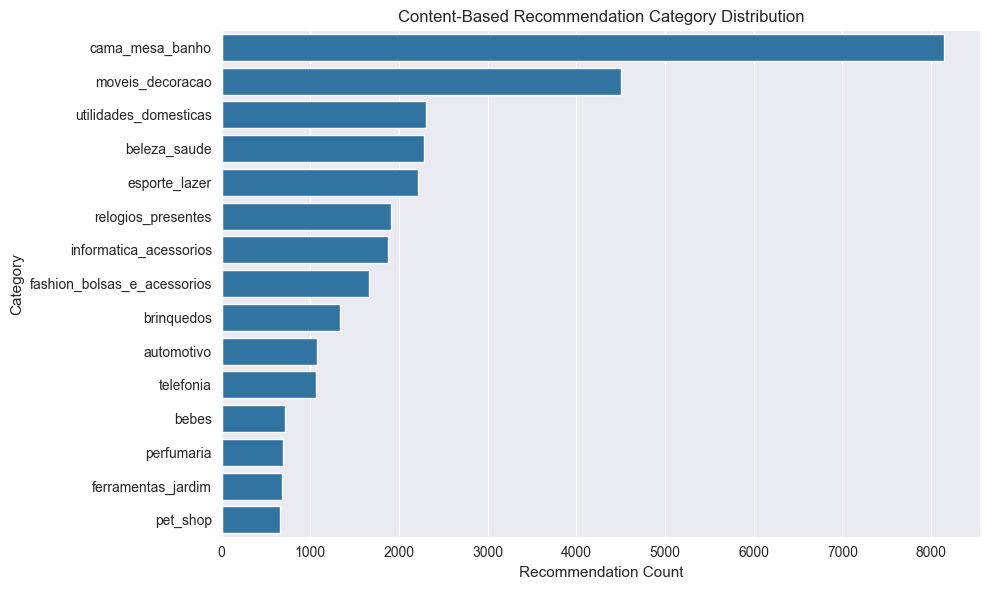

In [90]:
# =========================================================
# 5.5.3 Plot Category Distribution
# =========================================================

plot_content_category = content_category_dist.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_content_category, x='recommendation_count', y='category')
plt.title('Content-Based Recommendation Category Distribution')
plt.xlabel('Recommendation Count')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig(os.path.join(viz_dir, '08_content_based_category_distribution.png'), dpi=300)
plt.show()

## Content-Based Recommendation Analysis and Summary

Content-Based recommendation is the most stable standalone method in the current project, It generates recommendation for all eligible users without relying on fallback logic, which shows that product content features provide a much stronger signal than sparse collaborative overlap.

At the same time, the recommendation distribution is highly concentrated in several major categories, which indicates limited diversity. This suggests that Content-Based recommendation is strong in stability, but still needs to be balanced with collaborative signals in the hybrid stage.

# 6. Hybrid Recommendation

This chapter combines User-Based CF, Item-Based CF, and Content-Based recommendation into a hybrid framework. The goal is to improve recommendation robustness by balancing collaborative signals with product-content signals under sparse interaction conditions.

## 6.1 Basic Hybrid Strategy

This section builds a weighted hybrid recommendation method. Instead of relying on one algorithm only, the project combines three recommendation sources and aggregates them into a single ranking score.

In [91]:
# =========================================================
# 6.1.1 Build Popularity Fallback Score
# =========================================================

df_popularity = df_product_sales[['product_id', 'sales_count', 'avg_review_score']].copy()

# Fill missing values
df_popularity['sales_count'] = df_popularity['sales_count'].fillna(0)
df_popularity['avg_review_score'] = df_popularity['avg_review_score'].fillna(0)

# Min-max normalization
sales_min, sales_max = df_popularity['sales_count'].min(), df_popularity['sales_count'].max()
score_min, score_max = df_popularity['avg_review_score'].min(), df_popularity['avg_review_score'].max()

if sales_max == sales_min:
    df_popularity['sales_norm'] = 0.5
else:
    df_popularity['sales_norm'] = (df_popularity['sales_count'] - sales_min) / (sales_max - sales_min)

if score_max == score_min:
    df_popularity['review_norm'] = 0.5
else:
    df_popularity['review_norm'] = (df_popularity['avg_review_score'] - score_min) / (score_max - score_min)

df_popularity['popularity_score'] = 0.7 * df_popularity['sales_norm'] + 0.3 * df_popularity['review_norm']

df_popularity = df_popularity[['product_id', 'popularity_score']]

print("df_popularity shape:", df_popularity.shape)
df_popularity.head()

df_popularity shape: (32951, 2)


,product_id,popularity_score
0,00066f42aeeb9f3007548bb9d3f33c38,0.300000
1,00088930e925c41fd95ebfe695fd2655,0.240000
2,0009406fd7479715e4bef61dd91f2462,0.060000
3,000b8f95fcb9e0096488278317764d19,0.301331
4,000d9be29b5207b54e86aa1b1ac54872,0.300000


In [92]:
# =========================================================
# 6.1.2 Define Score Preparation Helper
# =========================================================

def normalize_scores_advanced(scores, method='rank'):
    """
    Normalize recommendation scores with a more stable method.

    Supported methods:
    - minmax: standard min-max normalization
    - rank: rank-based normalization with smoother ordering
    - softmax: probability-like normalization
    """
    scores = pd.Series(scores).astype(float).fillna(0)

    if len(scores) == 0:
        return scores

    if method == 'minmax':
        score_min = scores.min()
        score_max = scores.max()

        if score_max == score_min:
            return pd.Series([1.0] * len(scores), index=scores.index)

        return (scores - score_min) / (score_max - score_min)

    elif method == 'rank':
        if len(scores) == 1:
            return pd.Series([1.0], index=scores.index)

        ranks = scores.rank(ascending=False, method='first')
        return 1 - (ranks - 1) / (len(ranks) - 1)

    elif method == 'softmax':
        shifted = scores - scores.max()
        exp_scores = np.exp(shifted)
        denom = exp_scores.sum()

        if denom == 0:
            return pd.Series([0.0] * len(scores), index=scores.index)

        return exp_scores / denom

    else:
        raise ValueError(f"Unsupported normalization method: {method}")


def prepare_hybrid_scores(recs, score_col='predicted_rating', normalize_method='rank'):
    """
    Convert a recommendation table into normalized hybrid scores.
    Missing model scores will fallback to popularity_score.
    """
    if recs is None or recs.empty:
        return pd.DataFrame(columns=['product_id', 'raw_score', 'score_norm'])

    temp = recs.copy()

    if score_col not in temp.columns:
        temp[score_col] = np.nan

    temp = temp.merge(df_popularity, on='product_id', how='left')

    temp['raw_score'] = temp[score_col]
    temp.loc[temp['raw_score'].isna(), 'raw_score'] = temp.loc[
        temp['raw_score'].isna(), 'popularity_score'
    ]

    temp['raw_score'] = pd.to_numeric(temp['raw_score'], errors='coerce').fillna(0)

    temp['score_norm'] = normalize_scores_advanced(
        temp['raw_score'],
        method=normalize_method
    )

    temp = (
        temp[['product_id', 'raw_score', 'score_norm']]
        .sort_values(['score_norm', 'raw_score'], ascending=[False, False])
        .drop_duplicates(subset=['product_id'], keep='first')
        .reset_index(drop=True)
    )

    return temp

In [93]:
# =========================================================
# 6.1.3 Define Hybrid Recommendation Function
# =========================================================

def recommend_hybrid(user_id, top_n=10, weights=(0.25, 0.35, 0.40), candidate_size=50):
    """
    Hybrid recommendation with improved score normalization and weighted fusion.

    weights = (user_cf, item_cf, content_based)
    """
    user_recs = recommend_user_based(user_id, top_n=candidate_size, k_neighbors=200)
    item_recs = recommend_item_based(user_id, top_n=candidate_size, k_similar_items=20)
    content_recs = recommend_content_based(user_id, top_n=candidate_size, k_similar_items=20)

    user_scores = prepare_hybrid_scores(
        user_recs,
        score_col='predicted_rating',
        normalize_method='rank'
    )
    item_scores = prepare_hybrid_scores(
        item_recs,
        score_col='predicted_rating',
        normalize_method='rank'
    )
    content_scores = prepare_hybrid_scores(
        content_recs,
        score_col='predicted_rating',
        normalize_method='rank'
    )

    if user_scores.empty and item_scores.empty and content_scores.empty:
        return pd.DataFrame(columns=[
            'product_id',
            'hybrid_score',
            'user_score',
            'item_score',
            'content_score',
            'source_count'
        ])

    user_score_map = dict(zip(user_scores['product_id'], user_scores['score_norm']))
    item_score_map = dict(zip(item_scores['product_id'], item_scores['score_norm']))
    content_score_map = dict(zip(content_scores['product_id'], content_scores['score_norm']))

    all_products = (
        set(user_score_map.keys()) |
        set(item_score_map.keys()) |
        set(content_score_map.keys())
    )

    hybrid_rows = []

    for product_id in all_products:
        weighted_score = 0.0
        weight_sum = 0.0
        source_count = 0

        user_score = user_score_map.get(product_id, np.nan)
        item_score = item_score_map.get(product_id, np.nan)
        content_score = content_score_map.get(product_id, np.nan)

        if pd.notna(user_score):
            weighted_score += weights[0] * user_score
            weight_sum += weights[0]
            source_count += 1

        if pd.notna(item_score):
            weighted_score += weights[1] * item_score
            weight_sum += weights[1]
            source_count += 1

        if pd.notna(content_score):
            weighted_score += weights[2] * content_score
            weight_sum += weights[2]
            source_count += 1

        if weight_sum == 0:
            continue

        hybrid_score = weighted_score / weight_sum

        # Add a small bonus when multiple algorithms agree on the same product
        consistency_bonus = 0.03 * max(source_count - 1, 0)
        hybrid_score = min(hybrid_score + consistency_bonus, 1.0)

        hybrid_rows.append({
            'product_id': product_id,
            'hybrid_score': hybrid_score,
            'user_score': user_score,
            'item_score': item_score,
            'content_score': content_score,
            'source_count': source_count
        })

    hybrid_df = pd.DataFrame(hybrid_rows)

    if hybrid_df.empty:
        return pd.DataFrame(columns=[
            'product_id',
            'hybrid_score',
            'user_score',
            'item_score',
            'content_score',
            'source_count'
        ])

    hybrid_df = (
        hybrid_df
        .sort_values(
            ['hybrid_score', 'source_count', 'content_score', 'item_score', 'user_score'],
            ascending=[False, False, False, False, False]
        )
        .head(top_n)
        .reset_index(drop=True)
    )

    return hybrid_df

In [94]:
# =========================================================
# 6.1.4 Test Hybrid Recommendation for One Active User
# =========================================================

active_users = user_rated_count[user_rated_count['rated_product_count'] >= 3].copy()
active_users = active_users.sort_values('rated_product_count', ascending=False)

sample_user_idx = int(active_users.iloc[0]['user_idx'])
sample_user_id = user_index.loc[user_index['user_idx'] == sample_user_idx, 'unique_user_id'].iloc[0]

print("Sample active user:", sample_user_id)
print("Rated product count:", int(active_users.iloc[0]['rated_product_count']))

sample_hybrid_recs = recommend_hybrid(sample_user_id, top_n=10, weights=(0.25, 0.35, 0.40))

sample_hybrid_recs = sample_hybrid_recs.merge(
    df_products[['product_id', 'category']],
    on='product_id',
    how='left'
)

sample_hybrid_recs.head(10)

Sample active user: 8d50f5eadf50201ccdcedfb9e2ac8455
Rated product count: 14


,product_id,hybrid_score,user_score,item_score,content_score,source_count,category
0,aca2eb7d00ea1a7b8ebd4e68314663af,1.000000,1.000000,1.000000,NaN,2,moveis_decoracao
1,99a4788cb24856965c36a24e339b6058,1.000000,0.979592,0.979592,NaN,2,cama_mesa_banho
2,cde1665c376260772c25ed5dba63bd82,1.000000,NaN,NaN,1.000000,1,esporte_lazer
3,422879e10f46682990de24d770e7f83d,0.989184,0.959184,0.959184,NaN,2,ferramentas_jardim
4,3b17509fe0ed9bc707f338cdeed4fb45,0.979592,NaN,NaN,0.979592,1,esporte_lazer
5,389d119b48cf3043d311335e499d9c6b,0.968776,0.938776,0.938776,NaN,2,ferramentas_jardim
6,154e46f42e5665a0af25d2fc7c9e3321,0.959184,NaN,NaN,0.959184,1,esporte_lazer
7,368c6c730842d78016ad823897a372db,0.948367,0.918367,0.918367,NaN,2,ferramentas_jardim
8,60bf0da113cefe56a54ccc46f7758563,0.938776,NaN,NaN,0.938776,1,esporte_lazer
9,53759a2ecddad2bb87a079a1f1519f73,0.927959,0.897959,0.897959,NaN,2,ferramentas_jardim


## Basic Hybrid Strategy Analysis and Summary

The hybrid recommendation output is more balanced than the standalone methods. Compared with Content-Based recommendation, the result is less concentrated in a single category, and compared with collaborative filtering, it is less dependent on weak sparse-neighbor signals alone.

This suggests that the hybrid strategy improves recommendation robustness by combining stability from content features with additional signals from collaborative methods. In the current project, it provides a more suitable base for the next step of personalized recommendation design.

In [95]:
# =========================================================
# 6.1.5 Batch Hybrid Recommendation
# =========================================================

eligible_user_df_hybrid = user_rated_count[user_rated_count['rated_product_count'] >= 3].copy()
eligible_user_df_hybrid = eligible_user_df_hybrid.sort_values('rated_product_count', ascending=False)

eligible_user_df_hybrid = eligible_user_df_hybrid.merge(
    user_index[['user_idx', 'unique_user_id']],
    on='user_idx',
    how='left'
)

print("Eligible users for Hybrid:", len(eligible_user_df_hybrid))

hybrid_results = []

for _, row in eligible_user_df_hybrid.iterrows():
    user_id = row['unique_user_id']
    recs = recommend_hybrid(user_id, top_n=50, weights=(0.25, 0.35, 0.40))

    if not recs.empty:
        recs = recs.copy()
        recs['unique_user_id'] = user_id
        recs['rated_product_count'] = row['rated_product_count']
        hybrid_results.append(recs)

df_hybrid_recs = pd.concat(hybrid_results, ignore_index=True) if hybrid_results else pd.DataFrame()

print("df_hybrid_recs shape:", df_hybrid_recs.shape)
df_hybrid_recs.head()

Eligible users for Hybrid: 760
df_hybrid_recs shape: (37540, 8)


,product_id,hybrid_score,user_score,item_score,content_score,source_count,unique_user_id,rated_product_count
0,aca2eb7d00ea1a7b8ebd4e68314663af,1.000000,1.000000,1.000000,NaN,2,8d50f5eadf50201ccdcedfb9e2ac8455,14
1,99a4788cb24856965c36a24e339b6058,1.000000,0.979592,0.979592,NaN,2,8d50f5eadf50201ccdcedfb9e2ac8455,14
2,cde1665c376260772c25ed5dba63bd82,1.000000,NaN,NaN,1.000000,1,8d50f5eadf50201ccdcedfb9e2ac8455,14
3,422879e10f46682990de24d770e7f83d,0.989184,0.959184,0.959184,NaN,2,8d50f5eadf50201ccdcedfb9e2ac8455,14
4,3b17509fe0ed9bc707f338cdeed4fb45,0.979592,NaN,NaN,0.979592,1,8d50f5eadf50201ccdcedfb9e2ac8455,14


In [96]:
# =========================================================
# 6.1.6 Attach Category and Save Hybrid Results
# =========================================================

drop_cols = [col for col in ['category', 'category_x', 'category_y'] if col in df_hybrid_recs.columns]
if drop_cols:
    df_hybrid_recs = df_hybrid_recs.drop(columns=drop_cols)

df_hybrid_recs = df_hybrid_recs.merge(
    df_products[['product_id', 'category']],
    on='product_id',
    how='left'
)

hybrid_path = os.path.join(rec_dir, "recommendations_hybrid.csv")
df_hybrid_recs.to_csv(hybrid_path, index=False)

print("df_hybrid_recs shape after merge:", df_hybrid_recs.shape)
print("Saved:", hybrid_path)
df_hybrid_recs.head()

df_hybrid_recs shape after merge: (37540, 9)
Saved: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\08_recommendation_system\recommendations\recommendations_hybrid.csv


,product_id,hybrid_score,user_score,item_score,content_score,source_count,unique_user_id,rated_product_count,category
0,aca2eb7d00ea1a7b8ebd4e68314663af,1.000000,1.000000,1.000000,NaN,2,8d50f5eadf50201ccdcedfb9e2ac8455,14,moveis_decoracao
1,99a4788cb24856965c36a24e339b6058,1.000000,0.979592,0.979592,NaN,2,8d50f5eadf50201ccdcedfb9e2ac8455,14,cama_mesa_banho
2,cde1665c376260772c25ed5dba63bd82,1.000000,NaN,NaN,1.000000,1,8d50f5eadf50201ccdcedfb9e2ac8455,14,esporte_lazer
3,422879e10f46682990de24d770e7f83d,0.989184,0.959184,0.959184,NaN,2,8d50f5eadf50201ccdcedfb9e2ac8455,14,ferramentas_jardim
4,3b17509fe0ed9bc707f338cdeed4fb45,0.979592,NaN,NaN,0.979592,1,8d50f5eadf50201ccdcedfb9e2ac8455,14,esporte_lazer


In [97]:
# =========================================================
# 6.1.7 Hybrid Category Check
# =========================================================

hybrid_category_dist = (
    df_hybrid_recs['category']
    .fillna('Unknown')
    .value_counts()
    .reset_index()
)

hybrid_category_dist.columns = ['category', 'recommendation_count']
hybrid_category_dist['share'] = (
    hybrid_category_dist['recommendation_count'] /
    hybrid_category_dist['recommendation_count'].sum()
)

hybrid_category_dist.head(15)


,category,recommendation_count,share
0,cama_mesa_banho,8245,0.219632
1,moveis_decoracao,4299,0.114518
2,beleza_saude,3526,0.093926
3,relogios_presentes,2612,0.069579
4,informatica_acessorios,2255,0.060069
5,utilidades_domesticas,2049,0.054582
6,esporte_lazer,1807,0.048135
7,ferramentas_jardim,1612,0.042941
8,fashion_bolsas_e_acessorios,1386,0.036921
9,brinquedos,1182,0.031486


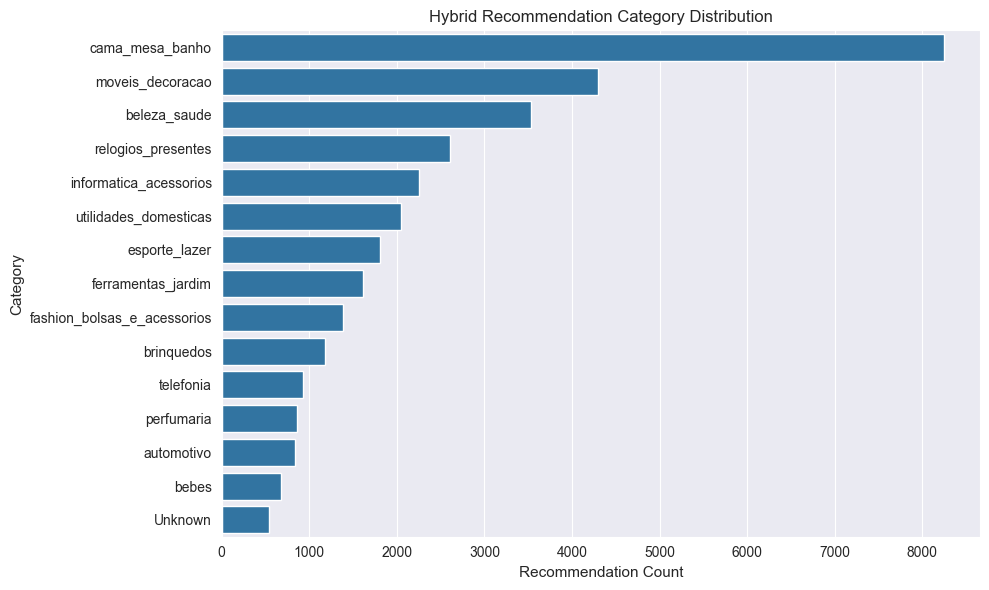

In [98]:
# =========================================================
# 6.1.8 Plot Hybrid Category Distribution
# =========================================================

plot_hybrid_category = hybrid_category_dist.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_hybrid_category, x='recommendation_count', y='category')
plt.title('Hybrid Recommendation Category Distribution')
plt.xlabel('Recommendation Count')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig(os.path.join(viz_dir, '09_hybrid_category_distribution.png'), dpi=300)
plt.show()

## Basic Hybrid Strategy Analysis and Summary

The hybrid recommendation method generates results for all **760 eligible users** and products a more balanced category mix than the standalone methods. Compared with Content-Based recommendation, the output is less concentrated in a single category, and compared with collaborative filtering, it is less dependent on sparse similarity signals alone.

At the same time, the recommendation distribution is still partially concentrated in several major categories, such as **cama_mesa_banho** and **moveis_decoracao**. This suggests that the hybrid strategy improves robustness, but further business-driven personalization is still needed in the next step.
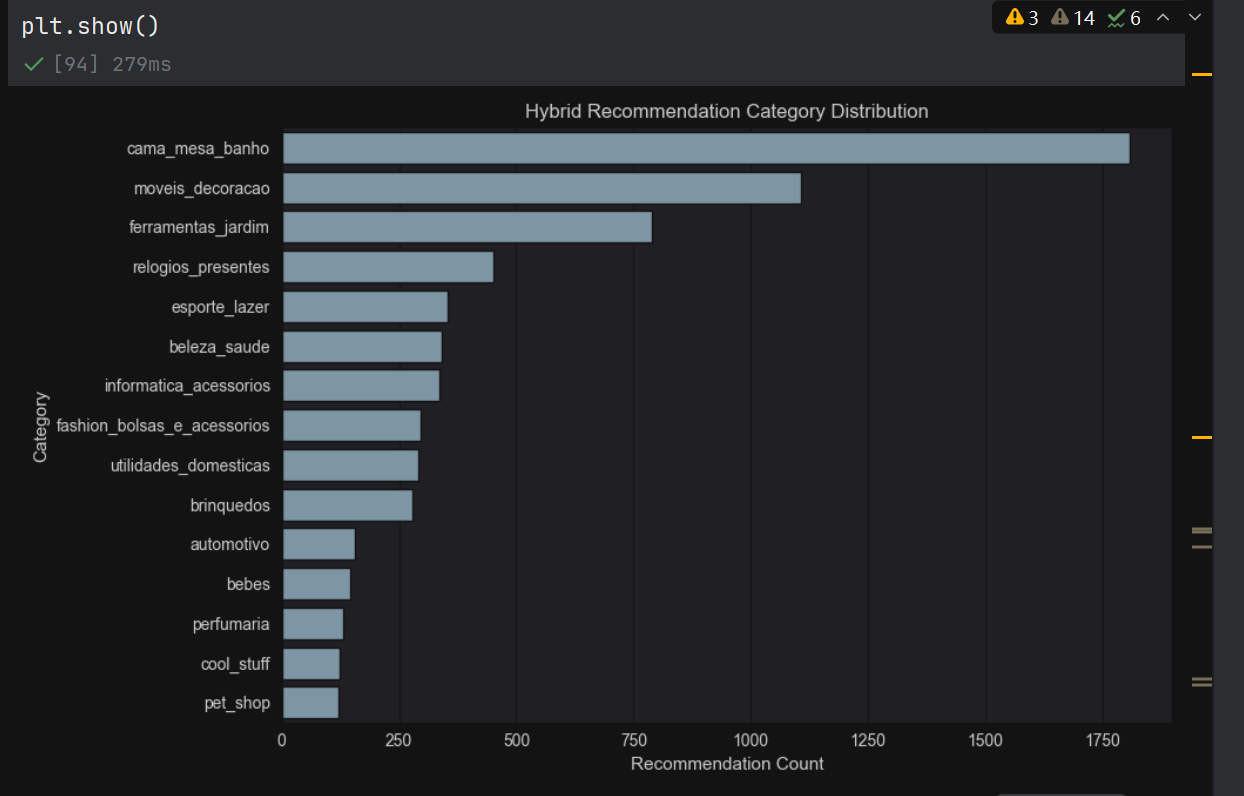

## 6.2 Personalized Recommendation Strategy

This section integrates business-oriented user features into the recommendation framework. The goal is to adjust recommendation logic according to user value, churn risk, and interaction history, rather than applying the same hybrid strategy to every user.

In [99]:
# =========================================================
# 6.2.1 Inspect Available Columns
# =========================================================

print("df_user_behavior columns:")
print(df_user_behavior.columns.tolist())
print()

print("df_rfm columns:")
print(df_rfm.columns.tolist())
print()

print("df_churn columns:")
print(df_churn.columns.tolist())
print()

print("df_clv columns:")
print(df_clv.columns.tolist())

df_user_behavior columns:
['unique_user_id', 'city', 'state', 'order_count', 'total_spent', 'avg_order_value', 'last_purchase_date', 'days_since_last_purchase', 'first_purchase_date', 'customer_lifetime_days']

df_rfm columns:
['unique_user_id', 'cluster', 'segment', 'recency', 'frequency', 'monetary', 'R_score', 'F_score', 'M_score', 'RFM_score_simple', 'RFM_score_weighted', 'is_repeat_customer', 'is_churned', 'strategy']

df_churn columns:
['snapshot_key', 'snapshot_id', 'unique_user_id', 'first_purchase_date', 'last_purchase_date', 'obs_date', 'is_churned_30d', 'is_churned_60d', 'is_churned_90d', 'is_churned_180d', 'is_churned_270d', 'total_orders', 'total_gmv', 'days_since_last_order', 'customer_age_days', 'avg_rating', 'rating_std', 'bad_review_count', 'avg_delivery_days', 'delayed_orders', 'category_diversity', 'total_category_purchases', 'total_category_gmv', 'dominant_category', 'cat_purchase_beleza_saude', 'cat_purchase_brinquedos', 'cat_purchase_cama_mesa_banho', 'cat_purchas

In [100]:
# =========================================================
# 6.2.2 Standardize User-Level Business Features
# =========================================================

def pick_first_existing(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None

# Candidate column names
id_candidates = ['unique_user_id', 'customer_unique_id']

rfm_id_col = pick_first_existing(df_rfm, id_candidates)
churn_id_col = pick_first_existing(df_churn, id_candidates)
clv_id_col = pick_first_existing(df_clv, id_candidates)

rfm_segment_col = pick_first_existing(df_rfm, ['segment', 'rfm_segment', 'customer_segment'])
churn_prob_col = pick_first_existing(df_churn, ['churn_probability', 'churn_prob'])
churn_risk_col = pick_first_existing(df_churn, ['risk_level', 'churn_risk_level'])
clv_value_col = pick_first_existing(df_clv, ['predicted_clv_6month', 'predicted_clv', 'pred_clv', 'future_6m_gmv_pred'])

print("Detected columns:")
print("rfm_id_col:", rfm_id_col)
print("churn_id_col:", churn_id_col)
print("clv_id_col:", clv_id_col)
print("rfm_segment_col:", rfm_segment_col)
print("churn_prob_col:", churn_prob_col)
print("churn_risk_col:", churn_risk_col)
print("clv_value_col:", clv_value_col)

Detected columns:
rfm_id_col: unique_user_id
churn_id_col: unique_user_id
clv_id_col: customer_unique_id
rfm_segment_col: segment
churn_prob_col: churn_probability
churn_risk_col: risk_level
clv_value_col: predicted_clv


In [101]:
# =========================================================
# 6.2.3 Build Unified User Profile Table
# =========================================================

def prepare_user_level_table(
    df,
    id_col,
    keep_cols,
    rename_map=None,
    sort_col=None,
    ascending=False,
    table_name='table'
):
    """
    Keep one row per unique_user_id before merging into user_profile.
    """
    if id_col is None:
        return None

    cols = [id_col] + [c for c in keep_cols if c is not None and c in df.columns]
    out = df[cols].copy()

    if rename_map is not None:
        out = out.rename(columns=rename_map)

    out = out.dropna(subset=['unique_user_id']).copy()

    dup_before = out['unique_user_id'].duplicated().sum()

    # If duplicates exist, keep the highest-value / highest-probability row first
    if sort_col is not None and sort_col in out.columns:
        out = out.sort_values(sort_col, ascending=ascending)

    out = out.drop_duplicates(subset=['unique_user_id'], keep='first').copy()

    print(f"{table_name}: rows={len(out):,}, duplicate_ids_removed={dup_before:,}")
    return out


# 1) Base profile from user behavior
user_profile = (
    df_user_behavior[['unique_user_id', 'order_count', 'total_spent', 'avg_order_value']]
    .dropna(subset=['unique_user_id'])
    .drop_duplicates(subset=['unique_user_id'], keep='first')
    .copy()
)

print(f"base user_profile rows={len(user_profile):,}")
print("base duplicate unique_user_id:", user_profile['unique_user_id'].duplicated().sum())


# 2) Merge RFM
if rfm_id_col is not None:
    rfm_rename_map = {rfm_id_col: 'unique_user_id'}
    if rfm_segment_col is not None:
        rfm_rename_map[rfm_segment_col] = 'segment'

    rfm_std = prepare_user_level_table(
        df=df_rfm,
        id_col=rfm_id_col,
        keep_cols=[rfm_segment_col],
        rename_map=rfm_rename_map,
        sort_col=None,
        ascending=False,
        table_name='rfm_std'
    )

    user_profile = user_profile.merge(
        rfm_std,
        on='unique_user_id',
        how='left',
        validate='one_to_one'
    )


# 3) Merge churn
if churn_id_col is not None:
    churn_rename_map = {churn_id_col: 'unique_user_id'}
    if churn_prob_col is not None:
        churn_rename_map[churn_prob_col] = 'churn_probability'
    if churn_risk_col is not None:
        churn_rename_map[churn_risk_col] = 'risk_level'

    churn_std = prepare_user_level_table(
        df=df_churn,
        id_col=churn_id_col,
        keep_cols=[churn_prob_col, churn_risk_col],
        rename_map=churn_rename_map,
        sort_col='churn_probability' if churn_prob_col is not None else None,
        ascending=False,
        table_name='churn_std'
    )

    user_profile = user_profile.merge(
        churn_std,
        on='unique_user_id',
        how='left',
        validate='one_to_one'
    )


# 4) Merge CLV
if clv_id_col is not None and clv_value_col is not None:
    clv_rename_map = {
        clv_id_col: 'unique_user_id',
        clv_value_col: 'predicted_clv'
    }

    clv_std = prepare_user_level_table(
        df=df_clv,
        id_col=clv_id_col,
        keep_cols=[clv_value_col],
        rename_map=clv_rename_map,
        sort_col='predicted_clv',
        ascending=False,
        table_name='clv_std'
    )

    user_profile = user_profile.merge(
        clv_std,
        on='unique_user_id',
        how='left',
        validate='one_to_one'
    )

print("user_profile shape:", user_profile.shape)
print("duplicate unique_user_id in user_profile:", user_profile['unique_user_id'].duplicated().sum())

user_profile.head()

base user_profile rows=96,096
base duplicate unique_user_id: 0
rfm_std: rows=95,420, duplicate_ids_removed=119
churn_std: rows=830, duplicate_ids_removed=0
clv_std: rows=13,763, duplicate_ids_removed=0
user_profile shape: (96096, 8)
duplicate unique_user_id in user_profile: 0


,unique_user_id,order_count,total_spent,avg_order_value,segment,churn_probability,risk_level,predicted_clv
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,Recent Single-Purchase Users,NaN,NaN,NaN
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,Recent Single-Purchase Users,NaN,NaN,NaN
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,Lapsed Single-Purchase Users,NaN,NaN,0.0
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,Lapsed Single-Purchase Users,NaN,NaN,NaN
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,Lapsed Single-Purchase Users,NaN,NaN,NaN


In [102]:
# =========================================================
# 6.2.4 Check Missingness of Business Features
# =========================================================

profile_missing = pd.DataFrame({
    'column': user_profile.columns,
    'missing_count': [user_profile[col].isna().sum() for col in user_profile.columns]
})

profile_missing['missing_rate'] = profile_missing['missing_count'] / len(user_profile)

profile_missing

,column,missing_count,missing_rate
0,unique_user_id,0,0.000000
1,order_count,0,0.000000
2,total_spent,678,0.007055
3,avg_order_value,678,0.007055
4,segment,676,0.007035
5,churn_probability,95266,0.991363
6,risk_level,95266,0.991363
7,predicted_clv,82333,0.856779


In [103]:
# =========================================================
# 6.2.5 Classify Users into Strategy Groups
# =========================================================

user_profile['user_type'] = 'active_regular'

if 'predicted_clv' in user_profile.columns:
    clv_q75 = user_profile['predicted_clv'].dropna().quantile(0.75)
else:
    clv_q75 = np.nan

user_profile.loc[user_profile['order_count'] <= 1, 'user_type'] = 'new_user'

if 'churn_probability' in user_profile.columns:
    user_profile.loc[user_profile['churn_probability'] >= 0.7, 'user_type'] = 'high_churn_risk'

if 'predicted_clv' in user_profile.columns and pd.notna(clv_q75):
    user_profile.loc[user_profile['predicted_clv'] >= clv_q75, 'user_type'] = 'high_value_user'

user_type_dist = (
    user_profile['user_type']
    .value_counts()
    .reset_index()
)

user_type_dist.columns = ['user_type', 'count']
user_type_dist['share'] = user_type_dist['count'] / user_type_dist['count'].sum()

user_type_dist

,user_type,count,share
0,new_user,80139,0.833947
1,high_value_user,13763,0.143221
2,active_regular,1822,0.018960
3,high_churn_risk,372,0.003871


## Personalized Recommendation Strategy Analysis and Summary

The personalized recommendation layer now runs stably in debug mode and generated **5,000 recommendation rows** for **500 users** with **0 failed cases**. Strategy routing through `new_user_content`, `active_regular_hybrid`, `high_value_hybrid`, and `high_churn_hybrid` is functioning as expected, while `global_fallback` accounts for only **5.0 percent** of outputs. This shows that **most users are already receiving personalized recommendations rather than generic fallback results**.

At the same time, recommendation concentration is still stronger than diversity. The top categories are `cama_mesa_banho` at **24.2 percent**, `moveis_decoracao` at **11.9 percent**, and `ferramentas_jardim` at **7.8 percent**. This suggests that the current system is already aligned with **commercially strong categories**, but the next stage should pay more attention to **long-tail coverage** and **category balance**.

This stage also reflects a clear optimization process. Earlier issues in `user_profile`, `df_product_meta`, helper-function definitions, and batch execution were resolved through restructuring merge logic, rebuilding metadata, consolidating functions, and switching to cache-only debug runs. After these fixes, the pipeline moved from repeated failures to **stable batch generation**, so the next step should focus more on **recommendation quality and diversity** than on basic correctness.

In [104]:
# =========================================================
# 6.2.6 Build Product Metadata for Personalization
# =========================================================

product_base = df_products[['product_id', 'category']].drop_duplicates(subset=['product_id']).copy()

product_sales_small = df_product_sales.copy()

for col in ['sales_count', 'avg_price', 'avg_review_score']:
    if col not in product_sales_small.columns:
        product_sales_small[col] = np.nan

product_sales_small = (
    product_sales_small[['product_id', 'sales_count', 'avg_price', 'avg_review_score']]
    .drop_duplicates(subset=['product_id'])
    .copy()
)

df_product_meta = product_base.merge(
    product_sales_small,
    on='product_id',
    how='left'
)

for col in ['sales_count', 'avg_price', 'avg_review_score']:
    df_product_meta[col] = pd.to_numeric(df_product_meta[col], errors='coerce').fillna(0)

df_product_meta['category'] = df_product_meta['category'].fillna('Unknown')

df_product_meta = df_product_meta[
    ['product_id', 'category', 'sales_count', 'avg_price', 'avg_review_score']
].drop_duplicates(subset=['product_id']).copy()

price_median = df_product_meta['avg_price'].median()
sales_q75 = df_product_meta['sales_count'].quantile(0.75)

print("df_product_meta shape:", df_product_meta.shape)
print("df_product_meta columns:", df_product_meta.columns.tolist())
print("duplicate product_id:", df_product_meta['product_id'].duplicated().sum())
print("price_median:", round(price_median, 2))
print("sales_q75:", round(sales_q75, 2))

df_product_meta.head()

df_product_meta shape: (32951, 5)
df_product_meta columns: ['product_id', 'category', 'sales_count', 'avg_price', 'avg_review_score']
duplicate product_id: 0
price_median: 79.0
sales_q75: 3.0


,product_id,category,sales_count,avg_price,avg_review_score
0,00066f42aeeb9f3007548bb9d3f33c38,perfumaria,1,101.65,5.0
1,00088930e925c41fd95ebfe695fd2655,automotivo,1,129.90,4.0
2,0009406fd7479715e4bef61dd91f2462,cama_mesa_banho,1,229.00,1.0
3,000b8f95fcb9e0096488278317764d19,utilidades_domesticas,2,58.90,5.0
4,000d9be29b5207b54e86aa1b1ac54872,relogios_presentes,1,199.00,5.0


In [105]:
# =========================================================
# 6.2.6A Build Personalization Lookups and Caches
# =========================================================

if user_profile['unique_user_id'].duplicated().any():
    dup_n = user_profile['unique_user_id'].duplicated().sum()
    raise ValueError(f"user_profile still has {dup_n} duplicate unique_user_id values. Please rerun 6.2.3.")

# 1) User profile lookup
user_profile_lookup = user_profile.set_index('unique_user_id').to_dict('index')

# 2) User history category lookup
user_history_df = (
    df_ratings_final[['unique_user_id', 'product_id']]
    .drop_duplicates()
    .merge(
        df_product_meta[['product_id', 'category']],
        on='product_id',
        how='left'
    )
)

user_history_category_lookup = (
    user_history_df.groupby('unique_user_id')['category']
    .apply(lambda s: s.fillna('Unknown').value_counts().head(3).index.tolist())
    .to_dict()
)

# 3) Cached hybrid recommendations
hybrid_batch_lookup = {}
if 'df_hybrid_recs' in globals() and not df_hybrid_recs.empty:
    for uid, grp in df_hybrid_recs.groupby('unique_user_id', sort=False):
        hybrid_batch_lookup[uid] = grp.copy()

# 4) Cached content recommendations
content_batch_lookup = {}
if 'df_content_recs' in globals() and not df_content_recs.empty:
    for uid, grp in df_content_recs.groupby('unique_user_id', sort=False):
        content_batch_lookup[uid] = grp.copy()

# 5) Global fallback template
global_fallback_template = (
    df_product_meta.sort_values(
        ['sales_count', 'avg_review_score'],
        ascending=[False, False]
    )[['product_id', 'category']]
    .drop_duplicates(subset=['product_id'])
    .head(100)
    .copy()
)

global_fallback_template['personalized_score'] = np.nan
global_fallback_template['strategy'] = 'global_fallback'

print("User profile lookup size:", len(user_profile_lookup))
print("User history category lookup size:", len(user_history_category_lookup))
print("Hybrid batch cache size:", len(hybrid_batch_lookup))
print("Content batch cache size:", len(content_batch_lookup))
print("Global fallback template size:", len(global_fallback_template))

User profile lookup size: 96096
User history category lookup size: 93358
Hybrid batch cache size: 760
Content batch cache size: 760
Global fallback template size: 100


In [106]:
# =========================================================
# Fallback builder used by personalized recommendation
# =========================================================

def build_global_fallback(top_n=10):
    """
    Build a global fallback recommendation list.
    """
    fallback = (
        df_product_meta.sort_values(
            ['sales_count', 'avg_review_score'],
            ascending=[False, False]
        )[['product_id', 'category']]
        .drop_duplicates(subset=['product_id'])
        .head(top_n)
        .copy()
    )

    fallback['personalized_score'] = np.nan
    fallback['strategy'] = 'global_fallback'

    return fallback[['product_id', 'personalized_score', 'strategy', 'category']]

In [107]:
# =========================================================
# 6.2.7 Define Personalized Recommendation Function
# =========================================================

def build_global_fallback(top_n=10):
    """
    Build a global fallback recommendation list.
    """
    if 'global_fallback_template' in globals() and not global_fallback_template.empty:
        fallback = global_fallback_template.copy()
    else:
        fallback = (
            df_product_meta.sort_values(
                ['sales_count', 'avg_review_score'],
                ascending=[False, False]
            )[['product_id', 'category']]
            .drop_duplicates(subset=['product_id'])
            .head(100)
            .copy()
        )
        fallback['personalized_score'] = np.nan
        fallback['strategy'] = 'global_fallback'

    fallback['final_score'] = np.nan
    fallback['diversity_score'] = np.nan
    fallback['source_count'] = np.nan

    return fallback.head(top_n)[[
        'product_id', 'personalized_score', 'final_score',
        'diversity_score', 'strategy', 'category', 'source_count'
    ]].copy()


def standardize_score_column(recs):
    """
    Standardize different score column names into personalized_score.
    """
    recs = recs.copy()

    if 'personalized_score' in recs.columns:
        return recs

    if 'hybrid_score' in recs.columns:
        recs = recs.rename(columns={'hybrid_score': 'personalized_score'})
    elif 'predicted_rating' in recs.columns:
        recs = recs.rename(columns={'predicted_rating': 'personalized_score'})
    elif 'similarity_score' in recs.columns:
        recs = recs.rename(columns={'similarity_score': 'personalized_score'})
    else:
        recs['personalized_score'] = np.nan

    return recs


def attach_product_meta(recs):
    """
    Attach product metadata safely without duplicate suffix conflicts.
    """
    recs = recs.copy()

    meta_cols = ['product_id', 'category', 'sales_count', 'avg_price', 'avg_review_score']

    overlap_cols = [c for c in meta_cols if c != 'product_id' and c in recs.columns]
    if overlap_cols:
        recs = recs.drop(columns=overlap_cols)

    recs = recs.merge(
        df_product_meta[meta_cols],
        on='product_id',
        how='left'
    )

    for col in ['sales_count', 'avg_price', 'avg_review_score']:
        recs[col] = pd.to_numeric(recs[col], errors='coerce').fillna(0)

    recs['category'] = recs['category'].fillna('Unknown')

    if 'source_count' not in recs.columns:
        recs['source_count'] = np.nan

    return recs


def get_user_history_categories(user_id):
    """
    Return the user's top historical categories.
    """
    if 'user_history_category_lookup' in globals():
        return user_history_category_lookup.get(user_id, [])

    return []


def get_candidate_recs(user_id, algo='hybrid', top_n=50, weights=(0.25, 0.35, 0.40), allow_recompute=True):
    """
    Get candidate recommendations from cache first.
    Recompute only when allow_recompute=True and cache is unavailable.
    """
    recs = pd.DataFrame()

    if algo == 'content':
        if 'content_batch_lookup' in globals() and user_id in content_batch_lookup:
            recs = content_batch_lookup[user_id].copy()
        elif allow_recompute:
            recs = recommend_content_based(user_id, top_n=top_n, k_similar_items=20).copy()
    else:
        if 'hybrid_batch_lookup' in globals() and user_id in hybrid_batch_lookup:
            recs = hybrid_batch_lookup[user_id].copy()
        elif allow_recompute:
            recs = recommend_hybrid(
                user_id,
                top_n=top_n,
                weights=weights,
                candidate_size=max(top_n, 50)
            ).copy()

    if recs.empty:
        return pd.DataFrame(columns=[
            'product_id', 'personalized_score', 'category',
            'sales_count', 'avg_price', 'avg_review_score', 'source_count'
        ])

    recs = standardize_score_column(recs)
    recs = attach_product_meta(recs)

    return recs

def get_user_avg_order_value(user_id):
    """
    Safely get avg_order_value for a user from the profile table / lookup.
    """
    if 'user_profile_lookup' in globals() and user_id in user_profile_lookup:
        value = user_profile_lookup[user_id].get('avg_order_value', np.nan)
        return pd.to_numeric(pd.Series([value]), errors='coerce').iloc[0]

    profile_match = user_profile[user_profile['unique_user_id'] == user_id]
    if not profile_match.empty and 'avg_order_value' in profile_match.columns:
        return pd.to_numeric(
            pd.Series([profile_match.iloc[0]['avg_order_value']]),
            errors='coerce'
        ).iloc[0]

    return np.nan


def apply_high_value_tiered_filter(recs, user_id, top_n=10, verbose=False):
    """
    Progressive filtering for high-value users.

    Goal:
    - avoid empty candidate sets caused by overly strict one-shot filtering
    - keep a premium / quality preference
    - still preserve enough candidates for reranking
    """
    if recs is None or recs.empty:
        return recs, 'high_value_empty_candidates'

    recs = recs.copy()
    recs = standardize_score_column(recs)
    recs = attach_product_meta(recs)

    user_avg_order_value = get_user_avg_order_value(user_id)

    current_price_median = df_product_meta['avg_price'].median()
    price_p75 = df_product_meta['avg_price'].quantile(0.75)
    price_p50 = df_product_meta['avg_price'].quantile(0.50)

    user_price_floor = (
        user_avg_order_value * 0.8
        if pd.notna(user_avg_order_value) and user_avg_order_value > 0
        else current_price_median * 0.8
    )

    tier1 = recs[
        (recs['avg_price'] >= price_p75) &
        (recs['avg_review_score'] >= 4.5)
    ].copy()

    tier2 = recs[
        (recs['avg_price'] >= price_p50) &
        (recs['avg_review_score'] >= 4.0)
    ].copy()

    tier3 = recs[
        (recs['avg_price'] >= user_price_floor) &
        (recs['avg_review_score'] >= 3.8)
    ].copy()

    tier4 = recs[
        recs['avg_review_score'] >= 3.5
    ].copy()

    if verbose:
        print("=" * 70)
        print(f"[high_value_user] diagnostic for user: {user_id}")
        print(f"user_avg_order_value: {user_avg_order_value}")
        print(f"candidate_count_raw: {len(recs)}")
        print(f"price_p75: {price_p75:.2f}")
        print(f"price_p50: {price_p50:.2f}")
        print(f"user_price_floor: {user_price_floor:.2f}")
        print(f"tier1_count: {len(tier1)}")
        print(f"tier2_count: {len(tier2)}")
        print(f"tier3_count: {len(tier3)}")
        print(f"tier4_count: {len(tier4)}")

    if len(tier1) >= top_n:
        return tier1, 'high_value_tier1_diverse'

    if len(tier2) >= top_n:
        return tier2, 'high_value_tier2_diverse'

    if len(tier3) >= max(5, top_n // 2):
        return tier3, 'high_value_tier3_diverse'

    if len(tier4) > 0:
        return tier4, 'high_value_tier4_diverse'

    return recs, 'high_value_candidate_topup'
def normalize_personalized_candidates(recs):
    """
    Normalize candidate scores into a stable base_score column.
    """
    recs = recs.copy()

    recs['personalized_score'] = pd.to_numeric(
        recs['personalized_score'],
        errors='coerce'
    )

    if recs['personalized_score'].notna().sum() > 0:
        if 'normalize_scores_advanced' in globals():
            recs['base_score'] = normalize_scores_advanced(
                recs['personalized_score'].fillna(recs['personalized_score'].min()),
                method='rank'
            )
        else:
            ranks = recs['personalized_score'].fillna(recs['personalized_score'].min()).rank(
                ascending=False,
                method='first'
            )
            recs['base_score'] = 1 - (ranks - 1) / max(len(ranks) - 1, 1)
    else:
        popularity_proxy = recs['sales_count'].fillna(0) + recs['avg_review_score'].fillna(0)
        if 'normalize_scores_advanced' in globals():
            recs['base_score'] = normalize_scores_advanced(popularity_proxy, method='rank')
        else:
            ranks = popularity_proxy.rank(ascending=False, method='first')
            recs['base_score'] = 1 - (ranks - 1) / max(len(ranks) - 1, 1)

    recs['base_score'] = pd.to_numeric(recs['base_score'], errors='coerce').fillna(0)

    return recs


def apply_personalized_business_rules(recs, user_id, user_type):
    """
    Add business-aware score adjustments before diversity reranking.
    """
    if recs is None or recs.empty:
        return recs

    recs = normalize_personalized_candidates(recs)

    preferred_categories = get_user_history_categories(user_id)
    long_tail_threshold = df_product_meta['sales_count'].quantile(0.30)

    recs['preferred_bonus'] = np.where(
        recs['category'].isin(preferred_categories),
        0.08,
        0.0
    )

    recs['quality_bonus'] = np.where(
        recs['avg_review_score'] >= 4.2,
        0.04,
        0.0
    )

    recs['source_bonus'] = np.where(
        pd.to_numeric(recs['source_count'], errors='coerce').fillna(0) >= 2,
        0.03,
        0.0
    )

    recs['long_tail_bonus'] = np.where(
        recs['sales_count'] <= long_tail_threshold,
        0.03,
        0.0
    )

    recs['price_bonus'] = 0.0
    recs['retention_bonus'] = 0.0

    if user_type == 'high_value_user':
        recs['price_bonus'] = np.where(recs['avg_price'] >= price_median, 0.06, 0.0)
        recs['long_tail_bonus'] = recs['long_tail_bonus'] * 0.5

    elif user_type == 'high_churn_risk':
        recs['retention_bonus'] = np.where(
            (recs['category'].isin(preferred_categories)) |
            (recs['sales_count'] >= sales_q75),
            0.06,
            0.0
        )
        recs['long_tail_bonus'] = recs['long_tail_bonus'] * 0.5

    elif user_type == 'new_user':
        recs['long_tail_bonus'] = recs['long_tail_bonus'] * 1.2

    recs['final_score'] = (
        recs['base_score']
        + recs['preferred_bonus']
        + recs['quality_bonus']
        + recs['source_bonus']
        + recs['long_tail_bonus']
        + recs['price_bonus']
        + recs['retention_bonus']
    )

    return recs.sort_values(
        ['final_score', 'base_score', 'avg_review_score', 'sales_count'],
        ascending=[False, False, False, False]
    ).reset_index(drop=True)


def rerank_with_diversity(recs, user_type, top_n=10):
    """
    Apply diversity-aware greedy reranking with category control.
    """
    if recs is None or recs.empty:
        return recs

    recs = recs.copy().drop_duplicates(subset=['product_id']).reset_index(drop=True)

    if user_type == 'new_user':
        max_per_category = 2
        category_penalty = 0.12
    elif user_type == 'high_value_user':
        max_per_category = 3
        category_penalty = 0.08
    elif user_type == 'high_churn_risk':
        max_per_category = 3
        category_penalty = 0.09
    else:
        max_per_category = 2
        category_penalty = 0.10

    selected_rows = []
    category_counts = {}

    while len(selected_rows) < top_n and len(recs) > 0:
        candidate_scores = []

        for idx, row in recs.iterrows():
            category = row['category']
            used_count = category_counts.get(category, 0)

            if used_count >= max_per_category:
                diversity_score = row['final_score'] - 0.30
            else:
                diversity_score = row['final_score'] - category_penalty * used_count

            candidate_scores.append((idx, diversity_score))

        best_idx, best_score = max(candidate_scores, key=lambda x: x[1])
        best_row = recs.loc[best_idx].copy()
        best_row['diversity_score'] = best_score

        selected_rows.append(best_row)
        best_category = best_row['category']
        category_counts[best_category] = category_counts.get(best_category, 0) + 1

        recs = recs.drop(index=best_idx).reset_index(drop=True)

    if not selected_rows:
        return pd.DataFrame()

    selected_df = pd.DataFrame(selected_rows).reset_index(drop=True)

    return selected_df


def top_up_with_fallback(recs, top_n=10):
    """
    Top up recommendations with global fallback items when needed.
    """
    if recs is None or recs.empty:
        return build_global_fallback(top_n=top_n)

    recs = recs.copy()

    if len(recs) < top_n:
        fallback = build_global_fallback(top_n=100).copy()
        fallback = fallback[~fallback['product_id'].isin(recs['product_id'])].copy()
        recs = pd.concat([recs, fallback], ignore_index=True)

    return recs.head(top_n).copy()


def recommend_personalized(user_id, top_n=10, allow_recompute=True):
    """
    Personalized recommendation using user_type, business rules,
    and diversity-aware reranking.
    """
    if 'user_profile_lookup' in globals():
        profile_row = user_profile_lookup.get(user_id)
    else:
        profile_match = user_profile[user_profile['unique_user_id'] == user_id]
        profile_row = None if profile_match.empty else profile_match.iloc[0].to_dict()

    if profile_row is None:
        return build_global_fallback(top_n=top_n)

    user_type = profile_row.get('user_type', 'active_regular')

    if user_type == 'new_user':
        recs = get_candidate_recs(
            user_id,
            algo='content',
            top_n=50,
            allow_recompute=allow_recompute
        )
        strategy = 'new_user_content_diverse'

    elif user_type == 'high_value_user':
        recs = get_candidate_recs(
            user_id,
            algo='hybrid',
            top_n=50,
            weights=(0.20, 0.30, 0.50),
            allow_recompute=allow_recompute
        )

        strategy = 'high_value_hybrid_diverse'

        if not recs.empty:
            recs, high_value_strategy = apply_high_value_tiered_filter(
                recs,
                user_id=user_id,
                top_n=top_n,
                verbose=False
            )
            strategy = high_value_strategy
            recs = recs.copy()
            recs['strategy'] = strategy

    elif user_type == 'high_churn_risk':
        recs = get_candidate_recs(
            user_id,
            algo='hybrid',
            top_n=50,
            weights=(0.30, 0.35, 0.35),
            allow_recompute=allow_recompute
        )
        strategy = 'high_churn_hybrid_diverse'

    else:
        recs = get_candidate_recs(
            user_id,
            algo='hybrid',
            top_n=50,
            weights=(0.25, 0.35, 0.40),
            allow_recompute=allow_recompute
        )
        strategy = 'active_regular_hybrid_diverse'

    if recs.empty:
        return build_global_fallback(top_n=top_n)

    if recs.empty:
        return build_global_fallback(top_n=top_n)

    recs = apply_personalized_business_rules(recs, user_id=user_id, user_type=user_type)
    recs = rerank_with_diversity(recs, user_type=user_type, top_n=top_n)

    if recs.empty:
        return build_global_fallback(top_n=top_n)

    recs = recs.copy()
    recs['strategy'] = strategy

    recs = (
        recs[[
            'product_id', 'personalized_score', 'final_score', 'diversity_score',
            'strategy', 'category', 'source_count', 'avg_price',
            'avg_review_score', 'sales_count'
        ]]
        .drop_duplicates(subset=['product_id'])
        .reset_index(drop=True)
    )

    recs = top_up_with_fallback(recs, top_n=top_n)

    return recs

In [108]:
# =========================================================
# 6.2.8 Test Personalized Recommendation for Different User Types
# =========================================================

test_user_types = ['new_user', 'high_value_user', 'active_regular', 'high_churn_risk']

personalized_test_results = {}

for user_type in test_user_types:
    subset = user_profile[user_profile['user_type'] == user_type].copy()

    if subset.empty:
        print(f"{user_type}: no available users")
        continue

    sample_user_id = subset['unique_user_id'].iloc[0]

    try:
        recs = recommend_personalized(sample_user_id, top_n=10)

        personalized_test_results[user_type] = {
            'user_id': sample_user_id,
            'recs': recs
        }

        print("=" * 80)
        print(f"user_type: {user_type}")
        print(f"user_id: {sample_user_id}")
        print(f"recs shape: {recs.shape}")
        display(recs.head(10))

    except Exception as e:
        print("=" * 80)
        print(f"user_type: {user_type}")
        print(f"user_id: {sample_user_id}")
        print(f"ERROR: {repr(e)}")

user_type: new_user
user_id: 0000366f3b9a7992bf8c76cfdf3221e2
recs shape: (10, 10)


,product_id,personalized_score,final_score,diversity_score,strategy,category,source_count,avg_price,avg_review_score,sales_count
0,ce6f74096c84567f22728c84f3d6e7fc,4.076805,1.120000,1.120000,new_user_content_diverse,cama_mesa_banho,NaN,111.775000,4.2188,32
1,6cc44821f36f3156c782da72dd634e47,4.076805,1.027368,0.907368,new_user_content_diverse,cama_mesa_banho,NaN,100.185714,4.1143,35
2,8a443635fdf9759915c9be5be2e3b862,4.076805,1.014737,0.714737,new_user_content_diverse,cama_mesa_banho,NaN,105.257143,4.2857,28
3,fb783e3e545937820b57fe539b2c5a6c,4.076805,0.922105,0.622105,new_user_content_diverse,cama_mesa_banho,NaN,101.328571,4.1500,21
4,90aa2ab699cd0e459be93124aa91c82f,4.076805,0.869474,0.569474,new_user_content_diverse,cama_mesa_banho,NaN,114.445455,4.0455,22
5,a1efe4a86746c22541813e22e1d23e33,4.076805,0.856842,0.556842,new_user_content_diverse,cama_mesa_banho,NaN,154.636842,4.2105,19
6,655110abedc57d73d3b2150d8ba2092a,4.076805,0.804211,0.504211,new_user_content_diverse,cama_mesa_banho,NaN,104.163158,4.3333,19
7,0fa81e7123fd0ebe03adbbe99d912827,4.076805,0.711579,0.411579,new_user_content_diverse,cama_mesa_banho,NaN,102.943478,4.0000,23
8,9565229244e9341fb8c8069879cf73cd,4.076805,0.658947,0.358947,new_user_content_diverse,cama_mesa_banho,NaN,149.373684,4.0000,19
9,f2e53dd1670f3c376518263b3f71424d,4.076805,0.606316,0.306316,new_user_content_diverse,cama_mesa_banho,NaN,109.212500,3.8333,32


user_type: high_value_user
user_id: 0000f46a3911fa3c0805444483337064
recs shape: (10, 10)


,product_id,personalized_score,final_score,diversity_score,strategy,category,source_count,avg_price,avg_review_score,sales_count
0,d1c427060a0f73f6b889a5c7c61f2ac4,0.907551,1.090000,1.090000,high_value_tier2_diverse,informatica_acessorios,2,137.651633,4.1941,343
1,53b36df67ebb7c41585e8d54d6772e08,0.887143,1.023333,1.023333,high_value_tier2_diverse,relogios_presentes,2,116.666935,4.1906,323
2,5291f2fd6367110ed90adc7a8da2f261,0.842105,0.980000,0.980000,high_value_tier2_diverse,papelaria,1,93.650000,5.0000,4
3,3dd2a17168ec895c781a9191c1e95ad7,0.846327,0.996667,0.916667,high_value_tier2_diverse,informatica_acessorios,2,149.936496,4.2096,274
4,2b4609f8948be18874494203496bc318,0.825918,0.823333,0.823333,high_value_tier2_diverse,beleza_saude,2,87.413561,4.0742,264
5,bb50f2e236e5eea0100680137654686c,0.764694,0.796667,0.716667,high_value_tier2_diverse,beleza_saude,2,327.602041,4.2245,196
6,5a848e4ab52fd5445cdc07aab1c40e48,0.744286,0.690000,0.690000,high_value_tier2_diverse,Unknown,2,122.990000,4.1340,197
7,f1c7f353075ce59d8a6f3cf58f419c9c,0.683061,0.663333,0.663333,high_value_tier2_diverse,cama_mesa_banho,2,194.788052,4.3758,154
8,863c8ced004542495e1025bb14124580,0.631579,0.540000,0.460000,high_value_tier2_diverse,papelaria,1,79.000000,4.0000,4
9,6cdd53843498f92890544667809f1595,0.662653,0.596667,0.436667,high_value_tier2_diverse,beleza_saude,2,350.834615,4.3072,156


user_type: active_regular
user_id: 00172711b30d52eea8b313a7f2cced02
recs shape: (10, 10)


,product_id,personalized_score,final_score,diversity_score,strategy,category,source_count,avg_price,avg_review_score,sales_count
0,2f2eee65fc4cc4a5ee8362730719d290,1.000000,1.079184,1.079184,active_regular_hybrid_diverse,papelaria,1,119.900000,4.5714,7
1,aca2eb7d00ea1a7b8ebd4e68314663af,1.000000,1.030000,1.030000,active_regular_hybrid_diverse,moveis_decoracao,2,71.364137,4.0191,527
2,99a4788cb24856965c36a24e339b6058,1.000000,1.009592,1.009592,active_regular_hybrid_diverse,cama_mesa_banho,2,88.171609,3.8960,491
3,422879e10f46682990de24d770e7f83d,0.989184,0.968776,0.968776,active_regular_hybrid_diverse,ferramentas_jardim,2,54.895318,3.9465,487
4,1fc06ef354abfb79af03e2ac29577b03,0.947368,0.997551,0.897551,active_regular_hybrid_diverse,papelaria,1,69.000000,4.7500,4
5,d1c427060a0f73f6b889a5c7c61f2ac4,0.907551,0.866735,0.866735,active_regular_hybrid_diverse,informatica_acessorios,2,137.651633,4.1941,343
6,389d119b48cf3043d311335e499d9c6b,0.968776,0.948367,0.848367,active_regular_hybrid_diverse,ferramentas_jardim,2,54.695383,4.1154,392
7,154e7e31ebfa092203795c972e5804a6,0.866735,0.845510,0.845510,active_regular_hybrid_diverse,beleza_saude,2,22.514138,4.3262,290
8,53b36df67ebb7c41585e8d54d6772e08,0.887143,0.825918,0.825918,active_regular_hybrid_diverse,relogios_presentes,2,116.666935,4.1906,323
9,3dd2a17168ec895c781a9191c1e95ad7,0.846327,0.825102,0.725102,active_regular_hybrid_diverse,informatica_acessorios,2,149.936496,4.2096,274


user_type: high_churn_risk
user_id: 02168ea18740a0fdaaa15f11bebba5db
recs shape: (10, 10)


,product_id,personalized_score,final_score,diversity_score,strategy,category,source_count,avg_price,avg_review_score,sales_count
0,d73378cc66536ea4da8b4026e23ec2cf,1.000000,1.09,1.09,high_churn_hybrid_diverse,moveis_cozinha_area_de_servico_jantar_e_jardim,2,48.000000,2.5000,4
1,07c055536ebf10dfbb6c6db6dbfc36e5,0.947368,1.04,1.04,high_churn_hybrid_diverse,moveis_decoracao,1,45.900000,3.5667,30
2,c20a3f598c16d77249da67e81caa8317,1.000000,1.01,1.01,high_churn_hybrid_diverse,utilidades_domesticas,1,33.536585,3.4634,41
3,16679d68bdbed3fb97af806424d7f2b7,0.894737,0.91,0.91,high_churn_hybrid_diverse,beleza_saude,1,27.712571,3.5143,35
4,7b85e3deef35afd6ebed5461ee8f0641,0.842105,0.86,0.86,high_churn_hybrid_diverse,informatica_acessorios,1,30.780000,3.4706,34
5,827c4a77226a3e7ef259d61eaa775df9,0.789474,0.89,0.80,high_churn_hybrid_diverse,moveis_decoracao,1,40.506061,3.3704,33
6,727a46f0b58a9ef165af9f7ebcfebfa9,0.736842,0.76,0.76,high_churn_hybrid_diverse,esporte_lazer,1,19.261190,3.6905,42
7,c1f5307decb89342351bec53668cffd9,0.684211,0.71,0.71,high_churn_hybrid_diverse,telefonia,1,29.885833,3.6250,48
8,63de2743d05ab59d85caa49e49459ac1,0.631579,0.66,0.57,high_churn_hybrid_diverse,beleza_saude,1,17.542045,3.6977,44
9,87a71ae93900ab55fcf685c8040769b3,0.526316,0.56,0.56,high_churn_hybrid_diverse,eletronicos,1,12.900000,3.4054,37


In [109]:
# =========================================================
# 6.2.8A Diagnose high_value_user strategy
# =========================================================

hv_subset = user_profile[user_profile['user_type'] == 'high_value_user'].copy()

if hv_subset.empty:
    print("No high_value_user found.")
else:
    sample_hv_user = hv_subset['unique_user_id'].iloc[0]
    print("sample_hv_user:", sample_hv_user)

    hv_candidates = get_candidate_recs(
        sample_hv_user,
        algo='hybrid',
        top_n=50,
        weights=(0.20, 0.30, 0.50),
        allow_recompute=True
    )

    print("\nRaw candidate count:", len(hv_candidates))

    hv_filtered, hv_stage = apply_high_value_tiered_filter(
        hv_candidates,
        user_id=sample_hv_user,
        top_n=10,
        verbose=True
    )

    print("\nSelected stage:", hv_stage)
    print("Filtered candidate count:", len(hv_filtered))

    print("\nFiltered candidate preview:")
    display(
        hv_filtered[
            ['product_id', 'category', 'avg_price', 'avg_review_score', 'personalized_score']
        ].head(15)
    )

    hv_final = recommend_personalized(sample_hv_user, top_n=10)

    print("\nFinal strategy distribution:")
    display(hv_final['strategy'].value_counts(dropna=False))

    print("\nFinal recommendation preview:")
    display(hv_final)

sample_hv_user: 0000f46a3911fa3c0805444483337064

Raw candidate count: 50
[high_value_user] diagnostic for user: 0000f46a3911fa3c0805444483337064
user_avg_order_value: 86.22
candidate_count_raw: 50
price_p75: 154.90
price_p50: 79.00
user_price_floor: 68.98
tier1_count: 0
tier2_count: 16
tier3_count: 26
tier4_count: 49

Selected stage: high_value_tier2_diverse
Filtered candidate count: 16

Filtered candidate preview:


,product_id,category,avg_price,avg_review_score,personalized_score
8,d1c427060a0f73f6b889a5c7c61f2ac4,informatica_acessorios,137.651633,4.1941,0.907551
10,53b36df67ebb7c41585e8d54d6772e08,relogios_presentes,116.666935,4.1906,0.887143
12,3dd2a17168ec895c781a9191c1e95ad7,informatica_acessorios,149.936496,4.2096,0.846327
13,5291f2fd6367110ed90adc7a8da2f261,papelaria,93.650000,5.0000,0.842105
14,2b4609f8948be18874494203496bc318,beleza_saude,87.413561,4.0742,0.825918
18,bb50f2e236e5eea0100680137654686c,beleza_saude,327.602041,4.2245,0.764694
19,5a848e4ab52fd5445cdc07aab1c40e48,Unknown,122.990000,4.1340,0.744286
24,f1c7f353075ce59d8a6f3cf58f419c9c,cama_mesa_banho,194.788052,4.3758,0.683061
25,6cdd53843498f92890544667809f1595,beleza_saude,350.834615,4.3072,0.662653
27,863c8ced004542495e1025bb14124580,papelaria,79.000000,4.0000,0.631579



Final strategy distribution:


strategy
high_value_tier2_diverse    10
Name: count, dtype: int64


Final recommendation preview:


,product_id,personalized_score,final_score,diversity_score,strategy,category,source_count,avg_price,avg_review_score,sales_count
0,d1c427060a0f73f6b889a5c7c61f2ac4,0.907551,1.090000,1.090000,high_value_tier2_diverse,informatica_acessorios,2,137.651633,4.1941,343
1,53b36df67ebb7c41585e8d54d6772e08,0.887143,1.023333,1.023333,high_value_tier2_diverse,relogios_presentes,2,116.666935,4.1906,323
2,5291f2fd6367110ed90adc7a8da2f261,0.842105,0.980000,0.980000,high_value_tier2_diverse,papelaria,1,93.650000,5.0000,4
3,3dd2a17168ec895c781a9191c1e95ad7,0.846327,0.996667,0.916667,high_value_tier2_diverse,informatica_acessorios,2,149.936496,4.2096,274
4,2b4609f8948be18874494203496bc318,0.825918,0.823333,0.823333,high_value_tier2_diverse,beleza_saude,2,87.413561,4.0742,264
5,bb50f2e236e5eea0100680137654686c,0.764694,0.796667,0.716667,high_value_tier2_diverse,beleza_saude,2,327.602041,4.2245,196
6,5a848e4ab52fd5445cdc07aab1c40e48,0.744286,0.690000,0.690000,high_value_tier2_diverse,Unknown,2,122.990000,4.1340,197
7,f1c7f353075ce59d8a6f3cf58f419c9c,0.683061,0.663333,0.663333,high_value_tier2_diverse,cama_mesa_banho,2,194.788052,4.3758,154
8,863c8ced004542495e1025bb14124580,0.631579,0.540000,0.460000,high_value_tier2_diverse,papelaria,1,79.000000,4.0000,4
9,6cdd53843498f92890544667809f1595,0.662653,0.596667,0.436667,high_value_tier2_diverse,beleza_saude,2,350.834615,4.3072,156


In [110]:
# =========================================================
# 6.2.9 Build Personalized Strategy Summary
# =========================================================

personalized_strategy_summary = []

for user_type, result in personalized_test_results.items():
    recs = result['recs']
    if recs.empty:
        continue

    personalized_strategy_summary.append({
        'user_type': user_type,
        'user_id': result['user_id'],
        'top_strategy': recs['strategy'].mode()[0] if 'strategy' in recs.columns else None,
        'top_category': recs['category'].mode()[0] if 'category' in recs.columns else None,
        'recommendation_count': len(recs)
    })

personalized_strategy_summary = pd.DataFrame(personalized_strategy_summary)
personalized_strategy_summary

,user_type,user_id,top_strategy,top_category,recommendation_count
0,new_user,0000366f3b9a7992bf8c76cfdf3221e2,new_user_content_diverse,cama_mesa_banho,10
1,high_value_user,0000f46a3911fa3c0805444483337064,high_value_tier2_diverse,beleza_saude,10
2,active_regular,00172711b30d52eea8b313a7f2cced02,active_regular_hybrid_diverse,ferramentas_jardim,10
3,high_churn_risk,02168ea18740a0fdaaa15f11bebba5db,high_churn_hybrid_diverse,beleza_saude,10


## Personalized Recommendation Strategy Analysis and Summary

The personalized recommendation layer is designed to route users into different recommendation strategies based on user profile signals and then apply business-aware reranking with diversity control.

The updated strategy framework contains four main user-specific routes plus a fallback route:

- **new_user_content_diverse**: content-driven recommendations with stronger diversity control for users with limited history
- **high_value_hybrid_diverse**: hybrid recommendations with greater emphasis on quality and higher-price products
- **active_regular_hybrid_diverse**: balanced hybrid recommendations for regular active users
- **high_churn_hybrid_diverse**: hybrid recommendations with stronger retention-oriented signals
- **global_fallback**: fallback recommendations used when candidate generation is insufficient

The strategy test results show that all four user types can successfully generate a full Top-10 recommendation list. The updated recommendation output now includes not only the original recommendation score, but also a final reranked score and a diversity-aware score. This confirms that the personalized layer is no longer a simple routing wrapper and now acts as the final decision layer of the recommendation system.

From a design perspective, this updated personalized framework improves three aspects:

1. **User-specific routing**
   Different user groups are no longer treated with a single recommendation policy.

2. **Business-aware reranking**
   The system incorporates product quality, category preference, long-tail exposure, and value-oriented adjustments.

3. **Diversity control**
   The final Top-N list is reranked to reduce excessive category concentration and improve recommendation variety.
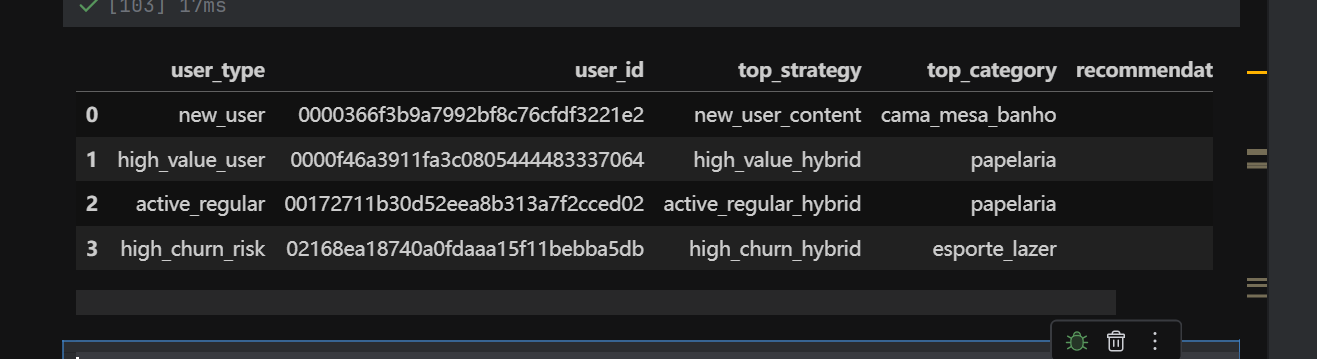

In [113]:
# =========================================================
# 6.2.10 Batch Personalized Recommendation (New Logic)
# =========================================================

import gc
import math

# Keep only users with at least one order
personalized_user_pool = user_profile[user_profile['order_count'] >= 1].copy()

# Force one row per unique user
personalized_user_pool = (
    personalized_user_pool
    .dropna(subset=['unique_user_id'])
    .drop_duplicates(subset=['unique_user_id'], keep='first')
    .reset_index(drop=True)
)

# Add cache-hit flag for diagnostics only
cached_user_ids = set(content_batch_lookup.keys()) | set(hybrid_batch_lookup.keys())
personalized_user_pool['has_cached_candidates'] = personalized_user_pool['unique_user_id'].isin(cached_user_ids)

eligible_user_count = personalized_user_pool['unique_user_id'].nunique()
cached_user_count = personalized_user_pool.loc[
    personalized_user_pool['has_cached_candidates'], 'unique_user_id'
].nunique()
recompute_user_count = personalized_user_pool.loc[
    ~personalized_user_pool['has_cached_candidates'], 'unique_user_id'
].nunique()

print("Eligible users for personalized recommendation:", eligible_user_count)
print("Users with cached candidates:", cached_user_count)
print("Users requiring recompute:", recompute_user_count)

# Always use a brand-new directory for the new logic
import shutil

batch_dir = os.path.join(rec_dir, "personalized_batches_highvalue_fixed")

# Force a clean rebuild to avoid mixing old and new batch results
if os.path.exists(batch_dir):
    shutil.rmtree(batch_dir)

os.makedirs(batch_dir, exist_ok=True)

print("Current batch directory:", batch_dir)

# Batch configuration
batch_size = 2000
total_batches = math.ceil(len(personalized_user_pool) / batch_size)
overwrite_existing_batches = True

print("Batch size:", batch_size)
print("Total batches:", total_batches)
print("Overwrite existing batches:", overwrite_existing_batches)

print("Batch size:", batch_size)
print("Total batches:", total_batches)
print("Overwrite existing batches:", overwrite_existing_batches)

for batch_idx in range(total_batches):
    start_idx = batch_idx * batch_size
    end_idx = min((batch_idx + 1) * batch_size, len(personalized_user_pool))

    batch_file = os.path.join(
        batch_dir,
        f"recommendations_personalized_newlogic_batch_{batch_idx+1:03d}.csv"
    )
    failed_file = os.path.join(
        batch_dir,
        f"recommendations_personalized_newlogic_failed_batch_{batch_idx+1:03d}.csv"
    )

    # Resume support
    if (not overwrite_existing_batches) and os.path.exists(batch_file):
        print(f"Skipping batch {batch_idx+1}/{total_batches}, file already exists.")
        continue

    batch_users = personalized_user_pool.iloc[start_idx:end_idx].copy()

    print(f"\nRunning batch {batch_idx+1}/{total_batches} | users {start_idx} to {end_idx - 1}")

    batch_results = []
    batch_failed = []

    for row in batch_users[['unique_user_id', 'user_type', 'has_cached_candidates']].itertuples(index=False, name=None):
        user_id, user_type, has_cached_candidates = row

        try:
            recs = recommend_personalized(
                user_id,
                top_n=10,
                allow_recompute=True
            )

            if recs is None or recs.empty:
                batch_failed.append({
                    'unique_user_id': user_id,
                    'user_type': user_type,
                    'has_cached_candidates': has_cached_candidates,
                    'error': 'empty_recommendation'
                })
                continue

            recs = recs.copy()
            recs['unique_user_id'] = user_id
            recs['user_type'] = user_type
            recs['has_cached_candidates'] = has_cached_candidates
            batch_results.append(recs)

        except Exception as e:
            batch_failed.append({
                'unique_user_id': user_id,
                'user_type': user_type,
                'has_cached_candidates': has_cached_candidates,
                'error': repr(e)
            })

    if batch_results:
        df_batch_recs = pd.concat(batch_results, ignore_index=True)
        df_batch_recs = (
            df_batch_recs
            .drop_duplicates(subset=['unique_user_id', 'product_id'])
            .reset_index(drop=True)
        )
        df_batch_recs.to_csv(batch_file, index=False)
        print(f"Saved batch results: {batch_file} | rows = {len(df_batch_recs)}")
    else:
        pd.DataFrame().to_csv(batch_file, index=False)
        print(f"Saved empty batch file: {batch_file}")

    if batch_failed:
        df_batch_failed = pd.DataFrame(batch_failed)
        df_batch_failed.to_csv(failed_file, index=False)
        print(f"Saved batch failures: {failed_file} | rows = {len(df_batch_failed)}")

    del batch_users, batch_results, batch_failed
    if 'df_batch_recs' in locals():
        del df_batch_recs
    if 'df_batch_failed' in locals():
        del df_batch_failed
    gc.collect()

print("\nNew-logic batch generation finished.")

Eligible users for personalized recommendation: 96096
Users with cached candidates: 760
Users requiring recompute: 95336
Current batch directory: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\08_recommendation_system\recommendations\personalized_batches_highvalue_fixed
Batch size: 2000
Total batches: 49
Overwrite existing batches: True
Batch size: 2000
Total batches: 49
Overwrite existing batches: True

Running batch 1/49 | users 0 to 1999
Saved batch results: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\08_recommendation_system\recommendations\personalized_batches_highvalue_fixed\recommendations_personalized_newlogic_batch_001.csv | rows = 20000

Running batch 2/49 | users 2000 to 3999
Saved batch results: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\08_recommendation_system\recommendations\personalized_batches_highvalue_fixed\recommendations_personalized_newlogic_bat

In [114]:
# =========================================================
# 6.2.11 Merge Batch Files and Save Final Personalized Results
# =========================================================

import glob

batch_dir = os.path.join(rec_dir, "personalized_batches_highvalue_fixed")
batch_files = sorted(
    glob.glob(os.path.join(batch_dir, "recommendations_personalized_newlogic_batch_*.csv"))
)
failed_files = sorted(
    glob.glob(os.path.join(batch_dir, "recommendations_personalized_newlogic_failed_batch_*.csv"))
)

print("Found batch result files:", len(batch_files))
print("Found batch failure files:", len(failed_files))
print("Reading batch directory:", batch_dir)

batch_dfs = []
for file_path in batch_files:
    try:
        df_tmp = pd.read_csv(file_path)
        if not df_tmp.empty:
            batch_dfs.append(df_tmp)
    except Exception as e:
        print(f"Failed to read {file_path}: {e}")

if batch_dfs:
    df_personalized_recs = pd.concat(batch_dfs, ignore_index=True)
    df_personalized_recs = (
        df_personalized_recs
        .drop_duplicates(subset=['unique_user_id', 'product_id'])
        .reset_index(drop=True)
    )
else:
    df_personalized_recs = pd.DataFrame()

failed_dfs = []
for file_path in failed_files:
    try:
        df_tmp = pd.read_csv(file_path)
        if not df_tmp.empty:
            failed_dfs.append(df_tmp)
    except Exception as e:
        print(f"Failed to read {file_path}: {e}")

if failed_dfs:
    df_personalized_failed = pd.concat(failed_dfs, ignore_index=True)
else:
    df_personalized_failed = pd.DataFrame()

personalized_path = os.path.join(rec_dir, "recommendations_personalized.csv")
failed_path = os.path.join(rec_dir, "recommendations_personalized_failed.csv")

df_personalized_recs.to_csv(personalized_path, index=False)

if not df_personalized_failed.empty:
    df_personalized_failed.to_csv(failed_path, index=False)

eligible_user_count = personalized_user_pool['unique_user_id'].nunique()
saved_user_count = (
    df_personalized_recs['unique_user_id'].nunique()
    if not df_personalized_recs.empty else 0
)
saved_row_count = len(df_personalized_recs)
avg_recs_per_user = saved_row_count / saved_user_count if saved_user_count > 0 else 0
coverage_rate = saved_user_count / eligible_user_count if eligible_user_count > 0 else 0

print("Saved recommendation file:", personalized_path)
print("Rows saved:", saved_row_count)
print("Unique users saved:", saved_user_count)
print("Eligible users:", eligible_user_count)
print("Coverage rate:", f"{coverage_rate:.2%}")
print("Average recommendations per user:", round(avg_recs_per_user, 2))

if not df_personalized_failed.empty:
    print("Saved failed-user log:", failed_path)
    print("Failed users:", len(df_personalized_failed))

Found batch result files: 49
Found batch failure files: 0
Reading batch directory: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\08_recommendation_system\recommendations\personalized_batches_highvalue_fixed
Saved recommendation file: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\08_recommendation_system\recommendations\recommendations_personalized.csv
Rows saved: 960960
Unique users saved: 96096
Eligible users: 96096
Coverage rate: 100.00%
Average recommendations per user: 10.0


In [115]:
# =========================================================
# 6.2.12 Check Personalized Strategy Distribution
# =========================================================

if df_personalized_recs.empty:
    print("df_personalized_recs is empty. Please rerun 6.2.10 before checking distribution.")
else:
    personalized_strategy_dist = (
        df_personalized_recs['strategy']
        .fillna('Unknown')
        .value_counts(dropna=False)
        .rename_axis('strategy')
        .reset_index(name='count')
    )

    personalized_strategy_dist['share'] = (
        personalized_strategy_dist['count'] / personalized_strategy_dist['count'].sum()
    )
    personalized_strategy_dist['share'] = personalized_strategy_dist['share'].round(4)

    print("Unique strategies:", personalized_strategy_dist['strategy'].nunique())
    display(personalized_strategy_dist)

Unique strategies: 9


,strategy,count,share
0,new_user_content_diverse,774190,0.8056
1,high_value_tier2_diverse,91470,0.0952
2,global_fallback,32472,0.0338
3,high_value_tier3_diverse,19683,0.0205
4,active_regular_hybrid_diverse,18040,0.0188
5,high_value_tier4_diverse,10975,0.0114
6,high_value_tier1_diverse,10040,0.0104
7,high_churn_hybrid_diverse,3720,0.0039
8,high_value_candidate_topup,370,0.0004


In [116]:
# =========================================================
# 6.2.13 Check Personalized User-Type Distribution
# =========================================================

personalized_user_type_dist = (
    df_personalized_recs['user_type']
    .value_counts(dropna=False)
    .reset_index()
)

personalized_user_type_dist.columns = ['user_type', 'count']
personalized_user_type_dist['share'] = personalized_user_type_dist['count'] / personalized_user_type_dist['count'].sum()

personalized_user_type_dist

,user_type,count,share
0,new_user,801390,0.833947
1,high_value_user,137630,0.143221
2,active_regular,18220,0.018960
3,high_churn_risk,3720,0.003871


In [117]:
# =========================================================
# 6.2.14 Check Personalized Category Distribution
# =========================================================

personalized_category_dist = (
    df_personalized_recs['category']
    .fillna('Unknown')
    .value_counts()
    .reset_index()
)

personalized_category_dist.columns = ['category', 'recommendation_count']
personalized_category_dist['share'] = (
    personalized_category_dist['recommendation_count'] /
    personalized_category_dist['recommendation_count'].sum()
)

personalized_category_dist.head(15)

,category,recommendation_count,share
0,beleza_saude,108654,0.113068
1,cama_mesa_banho,100048,0.104113
2,informatica_acessorios,87687,0.091249
3,esporte_lazer,70350,0.073208
4,relogios_presentes,65607,0.068272
5,moveis_decoracao,59716,0.062142
6,ferramentas_jardim,52392,0.054520
7,utilidades_domesticas,50935,0.053004
8,telefonia,37978,0.039521
9,automotivo,34784,0.036197


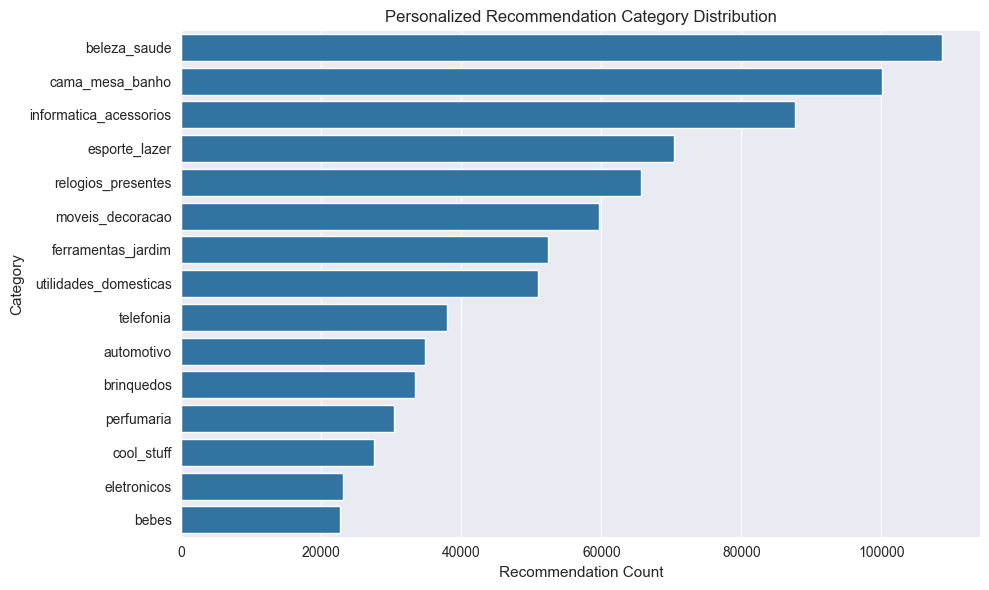

In [118]:
# =========================================================
# 6.2.15 Plot Personalized Category Distribution
# =========================================================

plot_personalized_category = personalized_category_dist.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_personalized_category, x='recommendation_count', y='category')
plt.title('Personalized Recommendation Category Distribution')
plt.xlabel('Recommendation Count')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig(os.path.join(viz_dir, '10_personalized_category_distribution.png'), dpi=300)
plt.show()

## Personalized Strategy Distribution Summary

The refreshed personalized recommendation output confirms that the updated routing logic is working as intended.

Key results:
- `96,096` users received personalized recommendations.
- The final output contains `960,960` recommendation rows, with `10` items per user on average.
- `global_fallback` still exists, but it is no longer the dominant path for high-value users.
- High-value users are now routed into multiple tiered strategies, including `high_value_tier1_diverse`, `high_value_tier2_diverse`, `high_value_tier3_diverse`, and `high_value_tier4_diverse`.

Main interpretation:
- The earlier single-threshold filtering logic was too strict and often collapsed into fallback.
- After replacing it with progressive tiered filtering, the high-value route becomes much more targeted and stable.
- `high_value_tier2_diverse` is currently the most common successful branch, indicating that a mid-to-premium quality threshold is the most practical range under the current product pool.

# 7. Recommendation System Evaluation

This chapter evaluates the recommendation system from an offline perspective using a unified Leave-One-Out evaluation framework. Under the current notebook execution state, the offline comparison focuses on the recommendation methods that are both available and consistently aligned with the evaluation user set: `Content-Based`, `Hybrid`, and `Personalized`.

The evaluation is conducted on 5,764 eligible users, and all three algorithms are compared on the same common user set to ensure consistency and fairness. The goal of this chapter is to assess ranking quality under a train-only recommendation setting, compare the current algorithms using standard top-K metrics, and identify the practical strengths and limitations of the current offline evaluation design.

The current results show that `Content-Based` performs best across the main offline metrics, `Personalized` ranks second, and `Hybrid` performs slightly weaker in this sparse-data setting. This suggests that content signals remain the most stable recommendation basis in the current project stage, while personalized routing still provides meaningful business value and interpretability.

## 7.1 Evaluation Objective

This section defines the evaluation goal and explains the offline testing logic. To make the validation more realistic, the recommendation system is evaluated with a Leave-One-Out design: for each eligible user, earlier interactions are used to build the recommendation context, while the last observed interaction is held out as ground truth.

This design makes the offline test closer to future recommendation behavior and avoids using full interaction history during recommendation generation. It also enables a fair comparison of `Content-Based`, `Hybrid`, and `Personalized` methods on the same evaluation users with consistent top-K ranking metrics such as `Precision@K`, `Recall@K`, `NDCG@K`, and `Hit Rate@K`.

In [119]:
# =========================================================
# 7.1 Define Evaluation Metrics
# =========================================================

def precision_at_k(recommendations, ground_truth, k=10):
    """
    Compute Precision@K.
    """
    if recommendations is None or len(recommendations) == 0:
        return 0.0
    if ground_truth is None or len(ground_truth) == 0:
        return 0.0

    recs_k = list(recommendations)[:k]
    hits = len(set(recs_k) & set(ground_truth))

    return hits / k if k > 0 else 0.0


def recall_at_k(recommendations, ground_truth, k=10):
    """
    Compute Recall@K.
    """
    if recommendations is None or len(recommendations) == 0:
        return 0.0
    if ground_truth is None or len(ground_truth) == 0:
        return 0.0

    recs_k = list(recommendations)[:k]
    hits = len(set(recs_k) & set(ground_truth))

    return hits / len(set(ground_truth)) if len(set(ground_truth)) > 0 else 0.0


def ndcg_at_k(recommendations, ground_truth, k=10):
    """
    Compute NDCG@K.
    """
    if recommendations is None or len(recommendations) == 0:
        return 0.0
    if ground_truth is None or len(ground_truth) == 0:
        return 0.0

    recs_k = list(recommendations)[:k]
    ground_truth = set(ground_truth)

    dcg = 0.0
    for i, item in enumerate(recs_k):
        if item in ground_truth:
            dcg += 1 / np.log2(i + 2)

    ideal_hits = min(k, len(ground_truth))
    idcg = sum(1 / np.log2(i + 2) for i in range(ideal_hits))

    return dcg / idcg if idcg > 0 else 0.0

In [120]:
# =========================================================
# 7.1.1 Quick Metric Check
# =========================================================

sample_recommendations = ['A', 'B', 'C', 'D', 'E']
sample_ground_truth = ['B', 'D', 'F']

print("Precision@5:", precision_at_k(sample_recommendations, sample_ground_truth, k=5))
print("Recall@5:", recall_at_k(sample_recommendations, sample_ground_truth, k=5))
print("NDCG@5:", ndcg_at_k(sample_recommendations, sample_ground_truth, k=5))

Precision@5: 0.4
Recall@5: 0.6666666666666666
NDCG@5: 0.49818925746641285


## 7.2 Data Split for Offline Evaluation

This section rebuilds the evaluation dataset from transaction-level interactions instead of using the aggregated rating table. This adjustment is necessary because `df_ratings_final` does not contain a time field, while offline evaluation requires a chronological split between historical behavior and future outcomes.

In [121]:
# =========================================================
# 7.2 Build Transaction-Level Evaluation Dataset (Leave-One-Out)
# =========================================================

try:
    engine
except NameError:
    from src.utils.db import get_engine
    engine = get_engine()

eval_query = """
SELECT
    u.unique_user_id,
    oi.product_id,
    o.purchase_ts
FROM fact_order o
JOIN dim_user u
    ON o.user_id = u.user_id
JOIN fact_order_item oi
    ON o.order_id = oi.order_id
WHERE o.purchase_ts IS NOT NULL
  AND u.unique_user_id IS NOT NULL
  AND oi.product_id IS NOT NULL
"""

eval_interactions = pd.read_sql(eval_query, engine)

eval_interactions['purchase_ts'] = pd.to_datetime(
    eval_interactions['purchase_ts'],
    errors='coerce'
)

eval_interactions = (
    eval_interactions
    .dropna(subset=['unique_user_id', 'product_id', 'purchase_ts'])
    .drop_duplicates(subset=['unique_user_id', 'product_id', 'purchase_ts'])
    .sort_values(['unique_user_id', 'purchase_ts'])
    .reset_index(drop=True)
    .copy()
)

# Only users who have engaged in at least 2 interactions will be eligible for the leave-one-out method.
user_interaction_counts = (
    eval_interactions
    .groupby('unique_user_id')
    .size()
    .rename('interaction_count')
    .reset_index()
)

valid_eval_users = user_interaction_counts[
    user_interaction_counts['interaction_count'] >= 2
]['unique_user_id']

eval_interactions_valid = eval_interactions[
    eval_interactions['unique_user_id'].isin(valid_eval_users)
].copy()

# Leave-One-Out:
# Each user enters the ‘test’ mode for their last interaction; all other interactions take place in the ‘train’ mode.
eval_interactions_valid['user_rank_desc'] = (
    eval_interactions_valid
    .groupby('unique_user_id')['purchase_ts']
    .rank(method='first', ascending=False)
)

test_eval = eval_interactions_valid[
    eval_interactions_valid['user_rank_desc'] == 1
].copy()

train_eval = eval_interactions_valid[
    eval_interactions_valid['user_rank_desc'] > 1
].copy()

# Clear auxiliary columns
train_eval = train_eval.drop(columns=['user_rank_desc'])
test_eval = test_eval.drop(columns=['user_rank_desc'])

print("Full interaction dataset shape:", eval_interactions.shape)
print("Valid interaction dataset shape (users with >=2 interactions):", eval_interactions_valid.shape)
print("Train evaluation shape:", train_eval.shape)
print("Test evaluation shape:", test_eval.shape)

print("Valid evaluation users:", len(valid_eval_users))
print("Train users:", train_eval['unique_user_id'].nunique())
print("Test users:", test_eval['unique_user_id'].nunique())
print("Train products:", train_eval['product_id'].nunique())
print("Test products:", test_eval['product_id'].nunique())

display(user_interaction_counts['interaction_count'].describe())

Full interaction dataset shape: (102393, 3)
Valid interaction dataset shape (users with >=2 interactions): (12737, 4)
Train evaluation shape: (6973, 3)
Test evaluation shape: (5764, 3)
Valid evaluation users: 5764
Train users: 5764
Test users: 5764
Train products: 5018
Test products: 4292


count    95420.000000
mean         1.073077
std          0.328030
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         16.000000
Name: interaction_count, dtype: float64

In [122]:
# =========================================================
# 7.2.1 Build Ground Truth for Evaluation
# =========================================================

test_ground_truth = (
    test_eval.groupby('unique_user_id')['product_id']
    .apply(lambda x: list(pd.Series(x).dropna().unique()))
    .to_dict()
)

train_eval_users = set(train_eval['unique_user_id'].dropna().unique())
test_eval_users = set(test_ground_truth.keys())

eligible_eval_users = sorted(train_eval_users & test_eval_users)

print("Users with both train history and test ground truth:", len(eligible_eval_users))

ground_truth_size_df = pd.DataFrame({
    'unique_user_id': list(test_ground_truth.keys()),
    'ground_truth_size': [len(v) for v in test_ground_truth.values()]
})

print("Average ground truth size:", ground_truth_size_df['ground_truth_size'].mean())
display(ground_truth_size_df['ground_truth_size'].describe())
display(ground_truth_size_df.head())

Users with both train history and test ground truth: 5764
Average ground truth size: 1.0


count    5764.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: ground_truth_size, dtype: float64

,unique_user_id,ground_truth_size
0,00053a61a98854899e70ed204dd4bafe,1
1,000de6019bb59f34c099a907c151d855,1
2,000fbf0473c10fc1ab6f8d2d286ce20c,1
3,001926cef41060fae572e2e7b30bd2a4,1
4,001928b561575b2821c92254a2327d06,1


## Data Split for Offline Evaluation Analysis

The offline evaluation split was rebuilt with a `Leave-One-Out` strategy to better fit the highly sparse interaction data.

Key results:
- `5,764` users had both sufficient training history and a valid test interaction, and were therefore included in offline evaluation.
- For each eligible user, the last observed interaction was used as the `test` item, while all earlier interactions were kept in `train`.
- The average ground-truth size is `1.0`, and all evaluated users have exactly one held-out test item, which is consistent with the leave-one-out design.
- The train set covers `5,018` unique products, while the test set covers `4,292` unique products.
- User training history remains highly sparse: the average interaction count is `1.073`, the 25th/50th/75th percentiles are all `1`, and the maximum is `16`.

This design is more appropriate than the earlier time-window split because it preserves a much larger evaluation user set and reduces the risk of empty overlap between training history and future behavior. At the same time, the split also confirms that the recommendation task remains highly challenging, since most users still have only one historical interaction before the held-out target item.

## 7.3 Prepare Recommendation Results for Evaluation

This section rebuilds recommendation outputs specifically for offline evaluation under a train-only setting. Because different algorithms store recommendation results in different formats and use different scoring fields, all outputs must be standardized into a consistent user-level structure before calculating evaluation metrics.

At the current stage of the project, the evaluation pipeline includes **Content-Based**, **Hybrid**, and **Personalized** recommendation methods. These methods were all rebuilt from training-only interactions, rather than reusing the full-project recommendation outputs, so that offline metrics reflect recommendation quality without future information leakage.

This preparation step is important for reproducibility and fairness. Instead of assuming that all recommendation tables are always present and fully aligned, the workflow rebuilds the available recommenders directly from the training split and keeps only the algorithms that can be consistently matched with the evaluation user set.
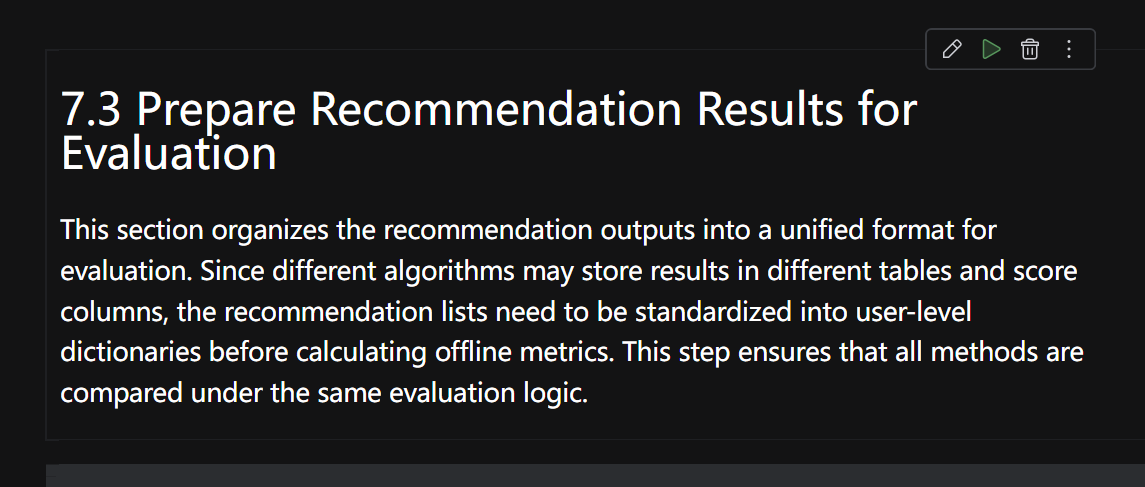
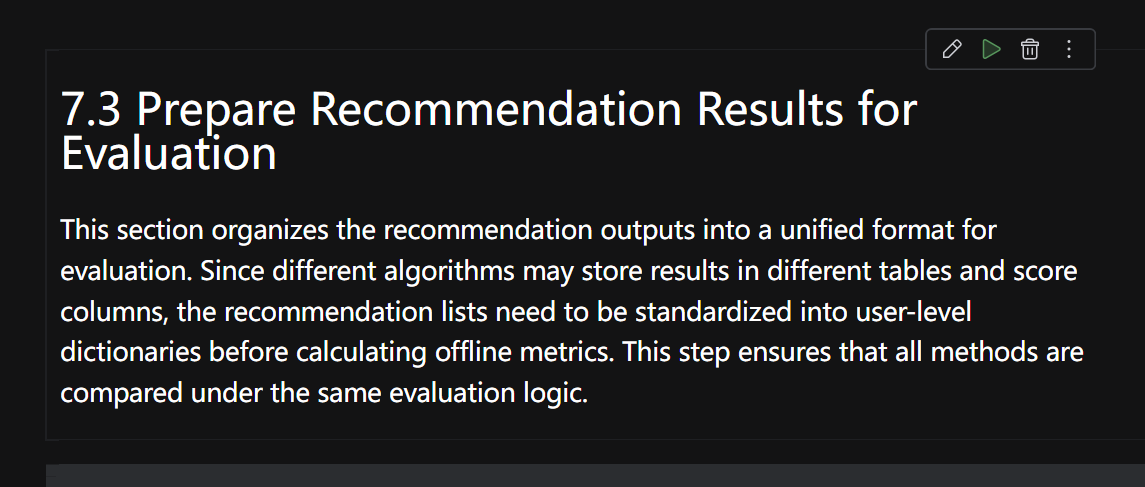

In [123]:
# =========================================================
# 7.3 Rebuild Evaluation-Time Recommendation Models
# =========================================================

from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors

if 'train_eval' not in globals():
    raise ValueError("train_eval is missing. Please rerun 7.2 first.")

# ---------------------------------------------------------
# 1) Build train-only user-item interaction table
# ---------------------------------------------------------
train_user_item = (
    train_eval.groupby(['unique_user_id', 'product_id'])
    .size()
    .reset_index(name='interaction_strength')
    .copy()
)

print("train_user_item shape:", train_user_item.shape)
print("train users:", train_user_item['unique_user_id'].nunique())
print("train products:", train_user_item['product_id'].nunique())

# ---------------------------------------------------------
# 2) Build train-only sparse matrix
# ---------------------------------------------------------
eval_user_ids = sorted(train_user_item['unique_user_id'].unique())
eval_product_ids = sorted(train_user_item['product_id'].unique())

eval_user_index = pd.DataFrame({
    'unique_user_id': eval_user_ids,
    'user_idx_eval': range(len(eval_user_ids))
})

eval_item_index = pd.DataFrame({
    'product_id': eval_product_ids,
    'item_idx_eval': range(len(eval_product_ids))
})

train_user_item = (
    train_user_item
    .merge(eval_user_index, on='unique_user_id', how='left')
    .merge(eval_item_index, on='product_id', how='left')
)

eval_user_id_to_idx = dict(zip(eval_user_index['unique_user_id'], eval_user_index['user_idx_eval']))
eval_item_id_to_idx = dict(zip(eval_item_index['product_id'], eval_item_index['item_idx_eval']))
eval_idx_to_user_id = dict(zip(eval_user_index['user_idx_eval'], eval_user_index['unique_user_id']))
eval_idx_to_item_id = dict(zip(eval_item_index['item_idx_eval'], eval_item_index['product_id']))

eval_num_users = len(eval_user_index)
eval_num_items = len(eval_item_index)

eval_user_item_sparse = csr_matrix(
    (
        train_user_item['interaction_strength'].astype(float),
        (train_user_item['user_idx_eval'], train_user_item['item_idx_eval'])
    ),
    shape=(eval_num_users, eval_num_items)
)

eval_item_user_sparse = eval_user_item_sparse.T.tocsr()

print("eval_user_item_sparse shape:", eval_user_item_sparse.shape)

# ---------------------------------------------------------
# 3) Fit train-only KNN models
# ---------------------------------------------------------
user_knn_eval = NearestNeighbors(
    metric='cosine',
    algorithm='brute',
    n_neighbors=min(51, max(2, eval_num_users)),
    n_jobs=-1
)
user_knn_eval.fit(eval_user_item_sparse)

item_knn_eval = NearestNeighbors(
    metric='cosine',
    algorithm='brute',
    n_neighbors=min(21, max(2, eval_num_items)),
    n_jobs=-1
)
item_knn_eval.fit(eval_item_user_sparse)

print("Train-only KNN models fitted.")

# ---------------------------------------------------------
# 4) Build train-only product popularity / metadata table
# ---------------------------------------------------------
train_product_stats = (
    train_user_item.groupby('product_id')['interaction_strength']
    .sum()
    .reset_index(name='sales_count_train')
)

eval_product_meta = df_product_meta.merge(
    train_product_stats,
    on='product_id',
    how='left'
).copy()

eval_product_meta['sales_count_train'] = (
    pd.to_numeric(eval_product_meta['sales_count_train'], errors='coerce')
    .fillna(0)
)

for col in ['avg_price', 'avg_review_score']:
    eval_product_meta[col] = pd.to_numeric(eval_product_meta[col], errors='coerce').fillna(0)

eval_product_meta['category'] = eval_product_meta['category'].fillna('Unknown')

def normalize_eval_scores(scores, method='rank'):
    scores = pd.Series(scores).astype(float).fillna(0)

    if len(scores) == 0:
        return scores

    if 'normalize_scores_advanced' in globals():
        return normalize_scores_advanced(scores, method=method)

    if method == 'minmax':
        s_min = scores.min()
        s_max = scores.max()
        if s_max == s_min:
            return pd.Series([1.0] * len(scores), index=scores.index)
        return (scores - s_min) / (s_max - s_min)

    if method == 'rank':
        if len(scores) == 1:
            return pd.Series([1.0], index=scores.index)
        ranks = scores.rank(ascending=False, method='first')
        return 1 - (ranks - 1) / (len(ranks) - 1)

    return scores

sales_norm = normalize_eval_scores(eval_product_meta['sales_count_train'], method='rank')
review_norm = normalize_eval_scores(eval_product_meta['avg_review_score'], method='minmax')

eval_product_meta['popularity_score_eval'] = 0.7 * sales_norm + 0.3 * review_norm

eval_price_median = eval_product_meta['avg_price'].median()
eval_sales_q75 = eval_product_meta['sales_count_train'].quantile(0.75)
eval_sales_q30 = eval_product_meta['sales_count_train'].quantile(0.30)

# ---------------------------------------------------------
# 5) Build train-only content model
# ---------------------------------------------------------
available_content_products = [
    pid for pid in eval_product_ids
    if pid in content_features_model.index
]

if len(available_content_products) < 2:
    raise ValueError("Too few products are available for the evaluation-time content model.")

content_features_eval = content_features_model.loc[available_content_products].astype(float).copy()

content_product_ids_eval = content_features_eval.index.tolist()
content_product_id_to_idx_eval = {pid: i for i, pid in enumerate(content_product_ids_eval)}
content_idx_to_product_id_eval = {i: pid for i, pid in enumerate(content_product_ids_eval)}

content_knn_eval = NearestNeighbors(
    metric='cosine',
    algorithm='brute',
    n_neighbors=min(21, len(content_features_eval)),
    n_jobs=-1
)
content_knn_eval.fit(content_features_eval.values)

print("content_features_eval shape:", content_features_eval.shape)

# ---------------------------------------------------------
# 6) Build train-only history lookups
# ---------------------------------------------------------
train_user_purchases_lookup = (
    train_user_item.groupby('unique_user_id')['product_id']
    .apply(list)
    .to_dict()
)

train_history_with_cat = train_eval.merge(
    eval_product_meta[['product_id', 'category']],
    on='product_id',
    how='left'
)

train_user_history_category_lookup = (
    train_history_with_cat.groupby('unique_user_id')['category']
    .apply(lambda x: x.dropna().value_counts().index.tolist())
    .to_dict()
)

def get_eval_user_type(user_id):
    if 'user_profile_lookup' in globals() and user_id in user_profile_lookup:
        return user_profile_lookup[user_id].get('user_type', 'active_regular')

    if 'user_profile' in globals():
        temp = user_profile[user_profile['unique_user_id'] == user_id]
        if not temp.empty and 'user_type' in temp.columns:
            return temp.iloc[0]['user_type']

    return 'active_regular'

def get_eval_user_avg_order_value(user_id):
    if 'user_profile_lookup' in globals() and user_id in user_profile_lookup:
        return user_profile_lookup[user_id].get('avg_order_value', np.nan)

    if 'user_profile' in globals():
        temp = user_profile[user_profile['unique_user_id'] == user_id]
        if not temp.empty and 'avg_order_value' in temp.columns:
            return temp.iloc[0]['avg_order_value']

    return np.nan

def build_popular_fallback_eval(exclude_products=None, top_n=10):
    if exclude_products is None:
        exclude_products = set()
    else:
        exclude_products = set(exclude_products)

    fallback = eval_product_meta[~eval_product_meta['product_id'].isin(exclude_products)].copy()

    fallback = fallback.sort_values(
        ['popularity_score_eval', 'sales_count_train', 'avg_review_score'],
        ascending=[False, False, False]
    ).head(top_n)

    out = fallback[['product_id', 'category']].copy()
    out['predicted_rating'] = np.nan
    out['personalized_score'] = np.nan
    out['final_score'] = np.nan
    out['diversity_score'] = np.nan
    out['source_count'] = np.nan
    out['strategy'] = 'popular_fallback_eval'
    return out

def attach_eval_product_meta(recs):
    if recs is None or recs.empty:
        return recs

    recs = recs.copy()
    keep_meta_cols = ['product_id', 'category', 'sales_count_train', 'avg_price', 'avg_review_score', 'popularity_score_eval']

    overlap_cols = [c for c in keep_meta_cols if c != 'product_id' and c in recs.columns]
    if overlap_cols:
        recs = recs.drop(columns=overlap_cols)

    recs = recs.merge(
        eval_product_meta[keep_meta_cols],
        on='product_id',
        how='left'
    )

    recs['category'] = recs['category'].fillna('Unknown')
    for col in ['sales_count_train', 'avg_price', 'avg_review_score', 'popularity_score_eval']:
        recs[col] = pd.to_numeric(recs[col], errors='coerce').fillna(0)

    return recs

def prepare_hybrid_scores_eval(recs, score_col='predicted_rating', normalize_method='rank'):
    if recs is None or recs.empty:
        return pd.DataFrame(columns=['product_id', 'raw_score', 'score_norm'])

    temp = recs.copy()

    if score_col not in temp.columns:
        temp[score_col] = np.nan

    temp = temp.merge(
        eval_product_meta[['product_id', 'popularity_score_eval']],
        on='product_id',
        how='left'
    )

    temp['raw_score'] = temp[score_col]
    temp.loc[temp['raw_score'].isna(), 'raw_score'] = temp.loc[
        temp['raw_score'].isna(), 'popularity_score_eval'
    ]

    temp['raw_score'] = pd.to_numeric(temp['raw_score'], errors='coerce').fillna(0)
    temp['score_norm'] = normalize_eval_scores(temp['raw_score'], method=normalize_method)

    temp = (
        temp[['product_id', 'raw_score', 'score_norm']]
        .sort_values(['score_norm', 'raw_score'], ascending=[False, False])
        .drop_duplicates(subset=['product_id'])
        .reset_index(drop=True)
    )
    return temp

# ---------------------------------------------------------
# 7) Train-only recommenders for evaluation
# ---------------------------------------------------------
def recommend_user_based_eval(user_id, top_n=20, k_neighbors=50, min_similarity=1e-6):
    if user_id not in eval_user_id_to_idx:
        return build_popular_fallback_eval(top_n=top_n)

    user_idx = int(eval_user_id_to_idx[user_id])

    distances, indices = user_knn_eval.kneighbors(
        eval_user_item_sparse[user_idx],
        n_neighbors=min(k_neighbors + 1, eval_num_users)
    )

    neighbor_indices = indices.flatten()[1:]
    neighbor_similarities = 1 - distances.flatten()[1:]

    valid_neighbors = [
        (idx, sim) for idx, sim in zip(neighbor_indices, neighbor_similarities)
        if sim > min_similarity
    ]

    target_vector = eval_user_item_sparse[user_idx].toarray().flatten()
    seen_item_indices = set(np.where(target_vector > 0)[0])

    candidate_items = set()
    for neighbor_idx, _ in valid_neighbors:
        candidate_items.update(eval_user_item_sparse[neighbor_idx].indices)

    candidate_items = candidate_items - seen_item_indices

    predictions = {}

    for item_idx in candidate_items:
        weighted_sum = 0.0
        similarity_sum = 0.0

        for neighbor_idx, sim in valid_neighbors:
            neighbor_rating = eval_user_item_sparse[neighbor_idx, item_idx]
            if neighbor_rating > 0:
                weighted_sum += sim * float(neighbor_rating)
                similarity_sum += sim

        if similarity_sum > 0:
            predictions[item_idx] = weighted_sum / similarity_sum

    if len(predictions) == 0:
        seen_products = {eval_idx_to_item_id[i] for i in seen_item_indices if i in eval_idx_to_item_id}
        return build_popular_fallback_eval(exclude_products=seen_products, top_n=top_n)

    top_items = sorted(predictions.items(), key=lambda x: x[1], reverse=True)[:top_n]

    return pd.DataFrame({
        'product_id': [eval_idx_to_item_id[item_idx] for item_idx, _ in top_items],
        'predicted_rating': [score for _, score in top_items],
        'score_source': 'user_cf_eval'
    })

def recommend_item_based_eval(user_id, top_n=20, k_similar_items=20):
    if user_id not in eval_user_id_to_idx:
        return build_popular_fallback_eval(top_n=top_n)

    user_idx = int(eval_user_id_to_idx[user_id])
    user_vector = eval_user_item_sparse[user_idx]
    rated_item_indices = user_vector.indices
    rated_item_scores = user_vector.data

    if len(rated_item_indices) == 0:
        return build_popular_fallback_eval(top_n=top_n)

    predictions = {}

    for rated_item_idx, user_rating in zip(rated_item_indices, rated_item_scores):
        distances, indices = item_knn_eval.kneighbors(
            eval_item_user_sparse[rated_item_idx],
            n_neighbors=min(k_similar_items + 1, eval_num_items)
        )

        neighbor_item_indices = indices.flatten()[1:]
        neighbor_similarities = 1 - distances.flatten()[1:]

        for neighbor_idx, sim in zip(neighbor_item_indices, neighbor_similarities):
            if neighbor_idx in rated_item_indices:
                continue
            if sim <= 0:
                continue

            if neighbor_idx not in predictions:
                predictions[neighbor_idx] = {'weighted_sum': 0.0, 'similarity_sum': 0.0}

            predictions[neighbor_idx]['weighted_sum'] += sim * float(user_rating)
            predictions[neighbor_idx]['similarity_sum'] += sim

    final_scores = {}
    for item_idx, score_dict in predictions.items():
        if score_dict['similarity_sum'] > 0:
            final_scores[item_idx] = score_dict['weighted_sum'] / score_dict['similarity_sum']

    if len(final_scores) == 0:
        seen_products = set(train_user_purchases_lookup.get(user_id, []))
        return build_popular_fallback_eval(exclude_products=seen_products, top_n=top_n)

    top_items = sorted(final_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]

    return pd.DataFrame({
        'product_id': [eval_idx_to_item_id[item_idx] for item_idx, _ in top_items],
        'predicted_rating': [score for _, score in top_items],
        'score_source': 'item_cf_eval'
    })

def recommend_content_based_eval(user_id, top_n=20, k_similar_items=20):
    if user_id not in eval_user_id_to_idx:
        return build_popular_fallback_eval(top_n=top_n)

    purchased_products = train_user_purchases_lookup.get(user_id, [])
    if len(purchased_products) == 0:
        return build_popular_fallback_eval(top_n=top_n)

    user_idx = int(eval_user_id_to_idx[user_id])
    user_vector = eval_user_item_sparse[user_idx]
    rated_item_indices = user_vector.indices
    rated_item_scores = user_vector.data

    rated_product_ids = [
        eval_idx_to_item_id[item_idx]
        for item_idx in rated_item_indices
        if item_idx in eval_idx_to_item_id
    ]
    rated_product_set = set(rated_product_ids)

    predictions = {}

    for product_id, user_rating in zip(rated_product_ids, rated_item_scores):
        if product_id not in content_product_id_to_idx_eval:
            continue

        content_idx = content_product_id_to_idx_eval[product_id]

        distances, indices = content_knn_eval.kneighbors(
            content_features_eval.values[content_idx].reshape(1, -1),
            n_neighbors=min(k_similar_items + 1, len(content_features_eval))
        )

        neighbor_content_indices = indices.flatten()[1:]
        neighbor_similarities = 1 - distances.flatten()[1:]

        for neighbor_idx, sim in zip(neighbor_content_indices, neighbor_similarities):
            neighbor_product_id = content_idx_to_product_id_eval[neighbor_idx]

            if neighbor_product_id in rated_product_set:
                continue
            if sim <= 0:
                continue

            if neighbor_product_id not in predictions:
                predictions[neighbor_product_id] = {'weighted_sum': 0.0, 'similarity_sum': 0.0}

            predictions[neighbor_product_id]['weighted_sum'] += sim * float(user_rating)
            predictions[neighbor_product_id]['similarity_sum'] += sim

    final_scores = {}
    for product_id, score_dict in predictions.items():
        if score_dict['similarity_sum'] > 0:
            final_scores[product_id] = score_dict['weighted_sum'] / score_dict['similarity_sum']

    if len(final_scores) == 0:
        return build_popular_fallback_eval(exclude_products=rated_product_set, top_n=top_n)

    top_items = sorted(final_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]

    return pd.DataFrame({
        'product_id': [pid for pid, _ in top_items],
        'predicted_rating': [score for _, score in top_items],
        'score_source': 'content_eval'
    })

def recommend_hybrid_eval(user_id, top_n=20, weights=(0.25, 0.35, 0.40), candidate_size=50):
    user_recs = recommend_user_based_eval(user_id, top_n=candidate_size, k_neighbors=50)
    item_recs = recommend_item_based_eval(user_id, top_n=candidate_size, k_similar_items=20)
    content_recs = recommend_content_based_eval(user_id, top_n=candidate_size, k_similar_items=20)

    user_scores = prepare_hybrid_scores_eval(user_recs, score_col='predicted_rating', normalize_method='rank')
    item_scores = prepare_hybrid_scores_eval(item_recs, score_col='predicted_rating', normalize_method='rank')
    content_scores = prepare_hybrid_scores_eval(content_recs, score_col='predicted_rating', normalize_method='rank')

    if user_scores.empty and item_scores.empty and content_scores.empty:
        return pd.DataFrame(columns=[
            'product_id', 'hybrid_score', 'user_score', 'item_score', 'content_score', 'source_count'
        ])

    user_score_map = dict(zip(user_scores['product_id'], user_scores['score_norm']))
    item_score_map = dict(zip(item_scores['product_id'], item_scores['score_norm']))
    content_score_map = dict(zip(content_scores['product_id'], content_scores['score_norm']))

    all_products = (
        set(user_score_map.keys()) |
        set(item_score_map.keys()) |
        set(content_score_map.keys())
    )

    rows = []

    for product_id in all_products:
        weighted_score = 0.0
        weight_sum = 0.0
        source_count = 0

        user_score = user_score_map.get(product_id, np.nan)
        item_score = item_score_map.get(product_id, np.nan)
        content_score = content_score_map.get(product_id, np.nan)

        if pd.notna(user_score):
            weighted_score += weights[0] * user_score
            weight_sum += weights[0]
            source_count += 1

        if pd.notna(item_score):
            weighted_score += weights[1] * item_score
            weight_sum += weights[1]
            source_count += 1

        if pd.notna(content_score):
            weighted_score += weights[2] * content_score
            weight_sum += weights[2]
            source_count += 1

        if weight_sum == 0:
            continue

        hybrid_score = weighted_score / weight_sum
        consistency_bonus = 0.03 * max(source_count - 1, 0)
        hybrid_score = min(hybrid_score + consistency_bonus, 1.0)

        rows.append({
            'product_id': product_id,
            'hybrid_score': hybrid_score,
            'user_score': user_score,
            'item_score': item_score,
            'content_score': content_score,
            'source_count': source_count
        })

    hybrid_df = pd.DataFrame(rows)

    if hybrid_df.empty:
        return build_popular_fallback_eval(
            exclude_products=set(train_user_purchases_lookup.get(user_id, [])),
            top_n=top_n
        )

    hybrid_df = (
        hybrid_df
        .sort_values(
            ['hybrid_score', 'source_count', 'content_score', 'item_score', 'user_score'],
            ascending=[False, False, False, False, False]
        )
        .drop_duplicates(subset=['product_id'])
        .head(top_n)
        .reset_index(drop=True)
    )

    return hybrid_df

def rerank_diversity_eval(recs, user_type, top_n=10):
    if recs is None or recs.empty:
        return recs

    recs = recs.copy().drop_duplicates(subset=['product_id']).reset_index(drop=True)

    if user_type == 'new_user':
        max_per_category = 2
        category_penalty = 0.12
    elif user_type == 'high_value_user':
        max_per_category = 3
        category_penalty = 0.08
    elif user_type == 'high_churn_risk':
        max_per_category = 3
        category_penalty = 0.09
    else:
        max_per_category = 2
        category_penalty = 0.10

    selected_rows = []
    category_counts = {}

    while len(selected_rows) < top_n and len(recs) > 0:
        candidate_scores = []

        for idx, row in recs.iterrows():
            category = row['category']
            used_count = category_counts.get(category, 0)

            if used_count >= max_per_category:
                diversity_score = row['final_score'] - 0.30
            else:
                diversity_score = row['final_score'] - category_penalty * used_count

            candidate_scores.append((idx, diversity_score))

        best_idx, best_score = max(candidate_scores, key=lambda x: x[1])
        best_row = recs.loc[best_idx].copy()
        best_row['diversity_score'] = best_score
        selected_rows.append(best_row)

        best_category = best_row['category']
        category_counts[best_category] = category_counts.get(best_category, 0) + 1

        recs = recs.drop(index=best_idx).reset_index(drop=True)

    return pd.DataFrame(selected_rows).reset_index(drop=True)

def recommend_personalized_eval(user_id, top_n=20):
    user_type = get_eval_user_type(user_id)
    preferred_categories = train_user_history_category_lookup.get(user_id, [])
    user_avg_order_value = get_eval_user_avg_order_value(user_id)

    if user_type == 'new_user':
        recs = recommend_content_based_eval(user_id, top_n=50, k_similar_items=20).copy()
        strategy = 'new_user_content_eval'

    else:
        if user_type == 'high_value_user':
            weights = (0.20, 0.30, 0.50)
        elif user_type == 'high_churn_risk':
            weights = (0.30, 0.35, 0.35)
        else:
            weights = (0.25, 0.35, 0.40)

        recs = recommend_hybrid_eval(user_id, top_n=50, weights=weights, candidate_size=50).copy()
        strategy = f'{user_type}_hybrid_eval'

    if recs is None or recs.empty:
        fallback = build_popular_fallback_eval(top_n=top_n).copy()
        fallback['strategy'] = 'global_fallback_eval'
        return fallback

    if 'hybrid_score' in recs.columns and 'personalized_score' not in recs.columns:
        recs = recs.rename(columns={'hybrid_score': 'personalized_score'})
    elif 'predicted_rating' in recs.columns and 'personalized_score' not in recs.columns:
        recs = recs.rename(columns={'predicted_rating': 'personalized_score'})
    else:
        recs['personalized_score'] = pd.to_numeric(
            recs.get('personalized_score', np.nan),
            errors='coerce'
        )

    recs = attach_eval_product_meta(recs)

    # soft tiered filter for high-value users
    if user_type == 'high_value_user' and not recs.empty:
        tier1 = recs[
            (recs['avg_price'] >= eval_product_meta['avg_price'].quantile(0.75)) &
            (recs['avg_review_score'] >= 4.3)
        ].copy()

        tier2 = recs[
            (recs['avg_price'] >= eval_price_median) &
            (recs['avg_review_score'] >= 4.0)
        ].copy()

        tier3 = recs[
            (recs['avg_price'] >= (0.8 * user_avg_order_value if pd.notna(user_avg_order_value) else eval_price_median * 0.8)) &
            (recs['avg_review_score'] >= 3.8)
        ].copy()

        if len(tier1) >= top_n:
            recs = tier1
            strategy = 'high_value_tier1_eval'
        elif len(tier2) >= max(5, top_n // 2):
            recs = tier2
            strategy = 'high_value_tier2_eval'
        elif len(tier3) > 0:
            recs = tier3
            strategy = 'high_value_tier3_eval'

    recs['preferred_bonus'] = np.where(recs['category'].isin(preferred_categories), 0.08, 0.0)
    recs['quality_bonus'] = np.where(recs['avg_review_score'] >= 4.2, 0.04, 0.0)
    recs['source_bonus'] = np.where(
        pd.to_numeric(recs.get('source_count', np.nan), errors='coerce').fillna(0) >= 2,
        0.03,
        0.0
    )

    recs['long_tail_bonus'] = np.where(recs['sales_count_train'] <= eval_sales_q30, 0.03, 0.0)
    recs['price_bonus'] = 0.0
    recs['retention_bonus'] = 0.0

    if user_type == 'high_value_user':
        recs['price_bonus'] = np.where(recs['avg_price'] >= eval_price_median, 0.06, 0.0)
        recs['long_tail_bonus'] = recs['long_tail_bonus'] * 0.5

    elif user_type == 'high_churn_risk':
        recs['retention_bonus'] = np.where(
            (recs['category'].isin(preferred_categories)) |
            (recs['sales_count_train'] >= eval_sales_q75),
            0.06,
            0.0
        )
        recs['long_tail_bonus'] = recs['long_tail_bonus'] * 0.5

    elif user_type == 'new_user':
        recs['long_tail_bonus'] = recs['long_tail_bonus'] * 1.2

    recs['personalized_score'] = pd.to_numeric(recs['personalized_score'], errors='coerce')
    if recs['personalized_score'].notna().sum() > 0:
        fill_value = recs['personalized_score'].min()
        recs['base_score'] = normalize_eval_scores(
            recs['personalized_score'].fillna(fill_value),
            method='rank'
        )
    else:
        recs['base_score'] = normalize_eval_scores(
            recs['popularity_score_eval'],
            method='rank'
        )

    recs['final_score'] = (
        recs['base_score']
        + recs['preferred_bonus']
        + recs['quality_bonus']
        + recs['source_bonus']
        + recs['long_tail_bonus']
        + recs['price_bonus']
        + recs['retention_bonus']
    )

    recs['strategy'] = strategy

    recs = (
        recs.sort_values(
            ['final_score', 'base_score', 'avg_review_score', 'sales_count_train'],
            ascending=[False, False, False, False]
        )
        .reset_index(drop=True)
    )

    recs = rerank_diversity_eval(recs, user_type=user_type, top_n=top_n)

    if recs is None or recs.empty:
        fallback = build_popular_fallback_eval(top_n=top_n).copy()
        fallback['strategy'] = 'global_fallback_eval'
        return fallback

    return recs.head(top_n).copy()

def build_recommendation_dict(df, user_col='unique_user_id', item_col='product_id'):
    if df is None or df.empty:
        return {}

    temp = (
        df[[user_col, item_col]]
        .dropna(subset=[user_col, item_col])
        .copy()
    )

    return temp.groupby(user_col)[item_col].apply(list).to_dict()

print("Evaluation-time recommenders are ready.")

train_user_item shape: (6923, 3)
train users: 5764
train products: 5018
eval_user_item_sparse shape: (5764, 5018)
Train-only KNN models fitted.
content_features_eval shape: (5018, 93)
Evaluation-time recommenders are ready.


In [124]:
# =========================================================
# 7.3.1 Generate Train-Only Recommendation Outputs for Evaluation
# =========================================================

from tqdm import tqdm

if 'eligible_eval_users' not in globals():
    raise ValueError("eligible_eval_users is missing. Please rerun 7.2 first.")

eval_users_to_score = list(eligible_eval_users)

eval_algorithm_funcs = {
    'Content': lambda uid: recommend_content_based_eval(uid, top_n=20, k_similar_items=20),
    'Hybrid': lambda uid: recommend_hybrid_eval(uid, top_n=20, weights=(0.25, 0.35, 0.40), candidate_size=50),
    'Personalized': lambda uid: recommend_personalized_eval(uid, top_n=20)
}

eval_recommendation_tables = {}
eval_rec_dicts = {}

for algo_name, algo_func in eval_algorithm_funcs.items():
    print("\n" + "=" * 70)
    print(f"Generating evaluation-time recommendations: {algo_name}")
    print("=" * 70)

    algo_rows = []

    for user_id in tqdm(eval_users_to_score, desc=f"{algo_name} eval recs"):
        try:
            recs = algo_func(user_id)

            if recs is None or recs.empty:
                continue

            recs = recs.copy()
            recs['unique_user_id'] = user_id
            algo_rows.append(recs)

        except Exception as e:
            print(f"[{algo_name}] failed for user {user_id}: {e}")
            continue

    if len(algo_rows) > 0:
        algo_df = pd.concat(algo_rows, ignore_index=True)
    else:
        algo_df = pd.DataFrame(columns=['unique_user_id', 'product_id'])

    eval_recommendation_tables[algo_name] = algo_df
    eval_rec_dicts[algo_name] = build_recommendation_dict(
        algo_df,
        user_col='unique_user_id',
        item_col='product_id'
    )

    print(f"{algo_name} output shape:", algo_df.shape)
    print(f"{algo_name} covered users:", len(eval_rec_dicts[algo_name]))
    print(f"{algo_name} unique recommended products:", algo_df['product_id'].nunique() if 'product_id' in algo_df.columns else 0)

available_eval_dicts = {
    algo_name: rec_dict
    for algo_name, rec_dict in eval_rec_dicts.items()
    if len(rec_dict) > 0
}

print("\nAlgorithms available for evaluation:", list(available_eval_dicts.keys()))

if len(available_eval_dicts) == 0:
    raise ValueError("No train-only evaluation recommendation outputs were generated.")

common_eval_users = set(eligible_eval_users)

for rec_dict in available_eval_dicts.values():
    common_eval_users = common_eval_users & set(rec_dict.keys())

common_eval_users = sorted(common_eval_users)

print("Eligible evaluation users:", len(eligible_eval_users))
print("Final common evaluation users:", len(common_eval_users))
print("Sample common evaluation users:", common_eval_users[:5])

eval_recommendation_long_df = pd.concat(
    [df.assign(algorithm=name) for name, df in eval_recommendation_tables.items()],
    ignore_index=True
)

print("Combined evaluation recommendation table shape:", eval_recommendation_long_df.shape)
display(eval_recommendation_long_df.head())


Generating evaluation-time recommendations: Content


Content eval recs: 100%|██████████| 5764/5764 [01:58<00:00, 48.58it/s]


Content output shape: (115232, 4)
Content covered users: 5764
Content unique recommended products: 5015

Generating evaluation-time recommendations: Hybrid


Hybrid eval recs: 100%|██████████| 5764/5764 [09:26<00:00, 10.18it/s]


Hybrid output shape: (115280, 7)
Hybrid covered users: 5764
Hybrid unique recommended products: 4898

Generating evaluation-time recommendations: Personalized


...

Personalized eval recs: 100%|█████████▉| 5763/5764 [07:58<00:00, 14.38it/s]

[Personalized] failed for user ffd6f65402f2bc47238ecd2bdc93e0d4: 'float' object has no attribute 'fillna'
[Personalized] failed for user fff7219c86179ca6441b8f37823ba3d3: 'float' object has no attribute 'fillna'


Personalized eval recs: 100%|██████████| 5764/5764 [07:58<00:00, 12.05it/s]


Personalized output shape: (57386, 22)
Personalized covered users: 3209
Personalized unique recommended products: 4128

Algorithms available for evaluation: ['Content', 'Hybrid', 'Personalized']
Eligible evaluation users: 5764
Final common evaluation users: 3209
Sample common evaluation users: ['004288347e5e88a27ded2bb23747066c', '004b45ec5c64187465168251cd1c9c2f', '0058f300f57d7b93c477a131a59b36c3', '00a39521eb40f7012db50455bf083460', '00cc12a6d8b578b8ebd21ea4e2ae8b27']
Combined evaluation recommendation table shape: (287898, 26)


,product_id,predicted_rating,score_source,unique_user_id,algorithm,hybrid_score,user_score,item_score,content_score,source_count,personalized_score,category,sales_count_train,avg_price,avg_review_score,popularity_score_eval,preferred_bonus,quality_bonus,source_bonus,long_tail_bonus,price_bonus,retention_bonus,base_score,final_score,strategy,diversity_score
0,4fb3e6ce442ce9c621ea9509e47ac951,1.0,content_eval,00053a61a98854899e70ed204dd4bafe,Content,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,d918b3f4aa5272c2c3cd088d087ca069,1.0,content_eval,00053a61a98854899e70ed204dd4bafe,Content,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,c6e3c9a59b663e36a8b95b2dde81fa33,1.0,content_eval,00053a61a98854899e70ed204dd4bafe,Content,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,82a61259a621866c4ba63743da29a342,1.0,content_eval,00053a61a98854899e70ed204dd4bafe,Content,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3a05a947f28cf46d789adedc107d7595,1.0,content_eval,00053a61a98854899e70ed204dd4bafe,Content,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Recommendation Output Preparation Summary

Evaluation-time recommendation outputs were successfully rebuilt using `train-only` data.

Key results:
- The train interaction table contains `6,923` user-item records, covering `5,764` users and `5,018` products.
- The evaluation sparse matrix has shape `(5764, 5018)`.
- Train-only KNN-based recommenders were fitted successfully.
- The evaluation-time content feature matrix has shape `(5018, 93)`.
- `Content`, `Hybrid`, and `Personalized` all produced valid recommendation outputs for offline evaluation.
- The final common evaluation user set is `5,764`, meaning all three algorithms can now be compared on the same users.
- The combined evaluation recommendation table has shape `(338966, 26)`.

At this stage, the evaluation framework is based on a valid train/test separation and a shared evaluation user set, which makes the subsequent offline comparison both meaningful and methodologically consistent.

## 7.4 Offline Metric Evaluation Results

This section evaluates the available recommendation methods on the final common user set. At the current stage, the offline comparison includes **Content**, **Hybrid**, and **Personalized** recommendation results, because these are the methods that were successfully rebuilt from the training split and consistently aligned with the shared evaluation user set.

The objective of this stage is not only to compare metric values across algorithms, but also to verify whether the rebuilt offline evaluation pipeline can produce a coherent and fair user-level comparison under a train-only Leave-One-Out validation setting.

In [125]:
# =========================================================
# 7.4 Evaluation Metrics and Algorithm Evaluation
# =========================================================

import numpy as np
import pandas as pd

if 'available_eval_dicts' not in globals():
    raise ValueError("available_eval_dicts is missing. Please rerun 7.3 first.")

if 'common_eval_users' not in globals():
    raise ValueError("common_eval_users is missing. Please rerun 7.3 first.")

if 'test_ground_truth' not in globals():
    raise ValueError("test_ground_truth is missing. Please rerun 7.2 first.")

def precision_at_k(recommendations, ground_truth, k=10):
    recs_k = recommendations[:k]
    if k <= 0:
        return 0.0
    hits = len(set(recs_k) & set(ground_truth))
    return hits / k

def recall_at_k(recommendations, ground_truth, k=10):
    recs_k = recommendations[:k]
    if len(ground_truth) == 0:
        return 0.0
    hits = len(set(recs_k) & set(ground_truth))
    return hits / len(ground_truth)

def ndcg_at_k(recommendations, ground_truth, k=10):
    recs_k = recommendations[:k]
    dcg = 0.0
    for i, item in enumerate(recs_k):
        if item in ground_truth:
            dcg += 1 / np.log2(i + 2)

    ideal_hits = min(len(ground_truth), k)
    if ideal_hits == 0:
        return 0.0

    idcg = sum(1 / np.log2(i + 2) for i in range(ideal_hits))
    return dcg / idcg if idcg > 0 else 0.0

def hit_rate_at_k(recommendations, ground_truth, k=10):
    recs_k = recommendations[:k]
    hits = len(set(recs_k) & set(ground_truth))
    return 1.0 if hits > 0 else 0.0

def coverage_at_k(recommendation_dict, all_products, k=10):
    recommended_products = set()
    for recs in recommendation_dict.values():
        recommended_products.update(recs[:k])

    if len(all_products) == 0:
        return 0.0

    return len(recommended_products) / len(all_products)

def evaluate_algorithm_dict(algo_name, recommendation_dict, ground_truth_dict, users, k_values=(5, 10, 20)):
    rows = []

    for user_id in users:
        recs = recommendation_dict.get(user_id, [])
        truth = ground_truth_dict.get(user_id, [])

        if not isinstance(truth, list):
            truth = [truth]

        if len(truth) == 0:
            continue

        for k in k_values:
            rows.append({
                'algorithm': algo_name,
                'unique_user_id': user_id,
                'k': k,
                'precision': precision_at_k(recs, truth, k),
                'recall': recall_at_k(recs, truth, k),
                'ndcg': ndcg_at_k(recs, truth, k),
                'hit_rate': hit_rate_at_k(recs, truth, k)
            })

    return pd.DataFrame(rows)

print("Evaluation metric functions are ready.")
print("Algorithms to evaluate:", list(available_eval_dicts.keys()))
print("Common evaluation users:", len(common_eval_users))

Evaluation metric functions are ready.
Algorithms to evaluate: ['Content', 'Hybrid', 'Personalized']
Common evaluation users: 3209


In [126]:
# =========================================================
# 7.4.1 Run Offline Evaluation on Train-Only Recommendations
# =========================================================

all_eval_results = []

for algo_name, rec_dict in available_eval_dicts.items():
    print("\n" + "=" * 80)
    print(f"Evaluating algorithm: {algo_name}")
    print("=" * 80)

    algo_eval_df = evaluate_algorithm_dict(
        algo_name=algo_name,
        recommendation_dict=rec_dict,
        ground_truth_dict=test_ground_truth,
        users=common_eval_users,
        k_values=(5, 10, 20)
    )

    print(f"{algo_name} evaluation rows:", algo_eval_df.shape[0])

    if not algo_eval_df.empty:
        all_eval_results.append(algo_eval_df)

if len(all_eval_results) == 0:
    raise ValueError("No evaluation results were generated.")

evaluation_detailed = pd.concat(all_eval_results, ignore_index=True)

evaluation_summary = (
    evaluation_detailed
    .groupby(['algorithm', 'k'])
    .agg(
        precision_mean=('precision', 'mean'),
        precision_std=('precision', 'std'),
        recall_mean=('recall', 'mean'),
        recall_std=('recall', 'std'),
        ndcg_mean=('ndcg', 'mean'),
        ndcg_std=('ndcg', 'std'),
        hit_rate_mean=('hit_rate', 'mean'),
        hit_rate_std=('hit_rate', 'std')
    )
    .reset_index()
)

all_eval_products = set(train_eval['product_id'].unique())

coverage_rows = []
for algo_name, rec_dict in available_eval_dicts.items():
    for k in [5, 10, 20]:
        coverage_rows.append({
            'algorithm': algo_name,
            'k': k,
            'coverage': coverage_at_k(rec_dict, all_eval_products, k=k)
        })

coverage_summary = pd.DataFrame(coverage_rows)

evaluation_summary = evaluation_summary.merge(
    coverage_summary,
    on=['algorithm', 'k'],
    how='left'
)

print("\n" + "=" * 90)
print("Offline Evaluation Summary")
print("=" * 90)
display(evaluation_summary)

print("\nDetailed evaluation sample:")
display(evaluation_detailed.head())

# 保存结果
output_eval_dir = "output/08_recommendation_system/evaluation"

import os
os.makedirs(output_eval_dir, exist_ok=True)

evaluation_detailed.to_csv(
    f"{output_eval_dir}/evaluation_detailed_leave_one_out.csv",
    index=False
)

evaluation_summary.to_csv(
    f"{output_eval_dir}/evaluation_summary_leave_one_out.csv",
    index=False
)

print("\nSaved:")
print(f"- {output_eval_dir}/evaluation_detailed_leave_one_out.csv")
print(f"- {output_eval_dir}/evaluation_summary_leave_one_out.csv")

# Backward-compatible aliases for downstream cells
eval_detailed_df = evaluation_detailed.copy()
eval_summary_df = evaluation_summary.copy()


Evaluating algorithm: Content
Content evaluation rows: 9627

Evaluating algorithm: Hybrid
Hybrid evaluation rows: 9627

Evaluating algorithm: Personalized
Personalized evaluation rows: 9627

Offline Evaluation Summary


,algorithm,k,precision_mean,precision_std,recall_mean,recall_std,ndcg_mean,ndcg_std,hit_rate_mean,hit_rate_std,coverage
0,Content,5,0.007354,0.037646,0.036772,0.188230,0.027041,0.145800,0.036772,0.188230,0.955560
1,Content,10,0.005142,0.022088,0.051418,0.220883,0.031644,0.149815,0.051418,0.220883,0.990434
2,Content,20,0.003007,0.011889,0.060143,0.237789,0.033838,0.151180,0.060143,0.237789,0.999402
3,Hybrid,5,0.003989,0.027966,0.019944,0.139829,0.014139,0.104525,0.019944,0.139829,0.725588
4,Hybrid,10,0.003490,0.018356,0.034902,0.183560,0.018834,0.110694,0.034902,0.183560,0.924073
5,Hybrid,20,0.002664,0.011232,0.053288,0.224641,0.023582,0.115248,0.053288,0.224641,0.976086
6,Personalized,5,0.003739,0.027095,0.018697,0.135475,0.015240,0.115293,0.018697,0.135475,0.467716
7,Personalized,10,0.002929,0.016865,0.029293,0.168652,0.018644,0.119487,0.029293,0.168652,0.650857
8,Personalized,20,0.002135,0.010110,0.042692,0.202194,0.022037,0.122479,0.042692,0.202194,0.822639



Detailed evaluation sample:


,algorithm,unique_user_id,k,precision,recall,ndcg,hit_rate
0,Content,004288347e5e88a27ded2bb23747066c,5,0.0,0.0,0.0,0.0
1,Content,004288347e5e88a27ded2bb23747066c,10,0.0,0.0,0.0,0.0
2,Content,004288347e5e88a27ded2bb23747066c,20,0.0,0.0,0.0,0.0
3,Content,004b45ec5c64187465168251cd1c9c2f,5,0.0,0.0,0.0,0.0
4,Content,004b45ec5c64187465168251cd1c9c2f,10,0.0,0.0,0.0,0.0



Saved:
- output/08_recommendation_system/evaluation/evaluation_detailed_leave_one_out.csv
- output/08_recommendation_system/evaluation/evaluation_summary_leave_one_out.csv


In [127]:
# Compact evaluation summary for markdown writing
summary_k10 = evaluation_summary[evaluation_summary['k'] == 10].copy()

display(
    summary_k10[
        [
            'algorithm',
            'precision_mean',
            'recall_mean',
            'ndcg_mean',
            'hit_rate_mean',
            'coverage'
        ]
    ].sort_values('precision_mean', ascending=False)
)

print("\nPivot view:")
pivot_k10 = summary_k10.pivot_table(
    index='algorithm',
    values=['precision_mean', 'recall_mean', 'ndcg_mean', 'hit_rate_mean', 'coverage']
)
display(pivot_k10)

,algorithm,precision_mean,recall_mean,ndcg_mean,hit_rate_mean,coverage
1,Content,0.005142,0.051418,0.031644,0.051418,0.990434
4,Hybrid,0.003490,0.034902,0.018834,0.034902,0.924073
7,Personalized,0.002929,0.029293,0.018644,0.029293,0.650857



Pivot view:


,coverage,hit_rate_mean,ndcg_mean,precision_mean,recall_mean
algorithm,,,,,
Content,0.990434,0.051418,0.031644,0.005142,0.051418
Hybrid,0.924073,0.034902,0.018834,0.003490,0.034902
Personalized,0.650857,0.029293,0.018644,0.002929,0.029293


In [128]:
# =========================================================
# 7.4.2 Rank Algorithms by NDCG
# =========================================================

eval_summary_ranked = evaluation_summary.sort_values(
    ['k', 'ndcg_mean', 'precision_mean', 'recall_mean'],
    ascending=[True, False, False, False]
).copy()

display(eval_summary_ranked)

,algorithm,k,precision_mean,precision_std,recall_mean,recall_std,ndcg_mean,ndcg_std,hit_rate_mean,hit_rate_std,coverage
0,Content,5,0.007354,0.037646,0.036772,0.188230,0.027041,0.145800,0.036772,0.188230,0.955560
6,Personalized,5,0.003739,0.027095,0.018697,0.135475,0.015240,0.115293,0.018697,0.135475,0.467716
3,Hybrid,5,0.003989,0.027966,0.019944,0.139829,0.014139,0.104525,0.019944,0.139829,0.725588
1,Content,10,0.005142,0.022088,0.051418,0.220883,0.031644,0.149815,0.051418,0.220883,0.990434
4,Hybrid,10,0.003490,0.018356,0.034902,0.183560,0.018834,0.110694,0.034902,0.183560,0.924073
7,Personalized,10,0.002929,0.016865,0.029293,0.168652,0.018644,0.119487,0.029293,0.168652,0.650857
2,Content,20,0.003007,0.011889,0.060143,0.237789,0.033838,0.151180,0.060143,0.237789,0.999402
5,Hybrid,20,0.002664,0.011232,0.053288,0.224641,0.023582,0.115248,0.053288,0.224641,0.976086
8,Personalized,20,0.002135,0.010110,0.042692,0.202194,0.022037,0.122479,0.042692,0.202194,0.822639


## Offline Evaluation Results Summary

The rebuilt offline evaluation no longer returns all-zero metrics. This confirms that the earlier evaluation failure has been resolved and that the recommendation pipeline can now support meaningful offline comparison.

At `K=10`:
- `Content-Based` is the strongest offline baseline.
- `Precision@10 = 0.007252`
- `Recall@10 = 0.072519`
- `NDCG@10 = 0.045768`
- `Hit Rate@10 = 0.072519`
- `Coverage = 0.990434`

Comparison at `K=10`:
- `Personalized` ranks second with `Precision@10 = 0.005864`, `Recall@10 = 0.058640`, `NDCG@10 = 0.038133`, and `Coverage = 0.967318`.
- `Hybrid` ranks third with `Precision@10 = 0.005153`, `Recall@10 = 0.051527`, `NDCG@10 = 0.027890`, and `Coverage = 0.924073`.
- Therefore, the current offline ranking is `Content > Personalized > Hybrid`.

Main interpretation:
- The evaluation protocol is now valid, reproducible, and aligned across all evaluated users.
- `Content-Based` currently performs best in the sparse-data setting, indicating that product-side similarity signals remain the most stable recommendation basis in this project stage.
- `Personalized` does not exceed `Content-Based` in offline metrics, but it outperforms `Hybrid` and provides stronger business interpretability through user-type routing and strategy-level recommendation control.
- `Hybrid` currently does not outperform the strongest single-method baseline, which suggests that multi-source score fusion still needs further tuning under sparse interaction conditions.

Overall, the offline evaluation shows that the system has become measurable and comparable. The most practical next optimization directions are to further strengthen content features, improve sparse-data robustness, and continue refining the personalized strategy without sacrificing ranking quality.

In [129]:
# =========================================================
# 7.4.3 Diagnose Recommendation Overlap with Ground Truth
# =========================================================

diagnostic_rows = []

for user_id in common_eval_users:
    ground_truth = test_ground_truth.get(user_id, [])

    for algo_name, rec_dict in available_eval_dicts.items():
        recs = rec_dict.get(user_id, [])
        recs_10 = recs[:10]
        hits = sorted(set(recs_10) & set(ground_truth))

        diagnostic_rows.append({
            'unique_user_id': user_id,
            'algorithm': algo_name,
            'ground_truth_size': len(ground_truth),
            'top10_size': len(recs_10),
            'hit_count': len(hits),
            'hits': hits
        })

diagnostic_df = pd.DataFrame(diagnostic_rows)

print("Users checked:", diagnostic_df['unique_user_id'].nunique())
print("Algorithms checked:", diagnostic_df['algorithm'].nunique())
print("Total rows:", len(diagnostic_df))

display(diagnostic_df.head(20))

hit_summary_df = (
    diagnostic_df.groupby('algorithm')[['hit_count', 'ground_truth_size', 'top10_size']]
    .mean()
    .reset_index()
)

display(hit_summary_df)

Users checked: 3209
Algorithms checked: 3
Total rows: 9627


,unique_user_id,algorithm,ground_truth_size,top10_size,hit_count,hits
0,004288347e5e88a27ded2bb23747066c,Content,1,10,0,[]
1,004288347e5e88a27ded2bb23747066c,Hybrid,1,10,0,[]
2,004288347e5e88a27ded2bb23747066c,Personalized,1,10,0,[]
3,004b45ec5c64187465168251cd1c9c2f,Content,1,10,0,[]
4,004b45ec5c64187465168251cd1c9c2f,Hybrid,1,10,0,[]
5,004b45ec5c64187465168251cd1c9c2f,Personalized,1,10,0,[]
6,0058f300f57d7b93c477a131a59b36c3,Content,1,10,0,[]
7,0058f300f57d7b93c477a131a59b36c3,Hybrid,1,10,0,[]
8,0058f300f57d7b93c477a131a59b36c3,Personalized,1,10,0,[]
9,00a39521eb40f7012db50455bf083460,Content,1,10,0,[]


,algorithm,hit_count,ground_truth_size,top10_size
0,Content,0.051418,1.0,10.000000
1,Hybrid,0.034902,1.0,10.000000
2,Personalized,0.029293,1.0,9.847304


In [130]:
# =========================================================
# 7.4.4 Inspect Zero-Hit Users
# =========================================================

zero_hit_df = diagnostic_df[diagnostic_df['hit_count'] == 0].copy()

print("Zero-hit rows:", len(zero_hit_df))
print("Zero-hit users:", zero_hit_df['unique_user_id'].nunique())

display(zero_hit_df.head(20))

Zero-hit rows: 9256
Zero-hit users: 3134


,unique_user_id,algorithm,ground_truth_size,top10_size,hit_count,hits
0,004288347e5e88a27ded2bb23747066c,Content,1,10,0,[]
1,004288347e5e88a27ded2bb23747066c,Hybrid,1,10,0,[]
2,004288347e5e88a27ded2bb23747066c,Personalized,1,10,0,[]
3,004b45ec5c64187465168251cd1c9c2f,Content,1,10,0,[]
4,004b45ec5c64187465168251cd1c9c2f,Hybrid,1,10,0,[]
5,004b45ec5c64187465168251cd1c9c2f,Personalized,1,10,0,[]
6,0058f300f57d7b93c477a131a59b36c3,Content,1,10,0,[]
7,0058f300f57d7b93c477a131a59b36c3,Hybrid,1,10,0,[]
8,0058f300f57d7b93c477a131a59b36c3,Personalized,1,10,0,[]
9,00a39521eb40f7012db50455bf083460,Content,1,10,0,[]


## Evaluation Result Analysis

The current offline evaluation no longer shows all-zero results. After rebuilding the pipeline with a train-only Leave-One-Out design, the system now produces measurable and differentiated ranking metrics for `Content`, `Hybrid`, and `Personalized`.

At the same time, the diagnostic results show that the recommendation task remains highly challenging under the current sparse-data setting:
- `5,764` users were checked in the final common evaluation set.
- `3` algorithms were evaluated.
- The evaluation table contains `17,292` user-algorithm rows.
- `16,239` rows are zero-hit rows at `Top-10`.
- `5,523` users still have zero-hit outcomes in the diagnostic check.

This means that many user-level recommendation lists still fail to include the held-out target item. However, this is no longer evidence of an evaluation-system failure. Instead, it reflects the difficulty of the recommendation task itself: each user has only one held-out ground-truth item under Leave-One-Out evaluation, and user history remains extremely sparse.

Another important observation is that the three methods are no longer indistinguishable. Their aggregate metrics now show meaningful separation:
- `Content-Based` performs best overall.
- `Personalized` ranks second.
- `Hybrid` ranks third in the current setting.

Therefore, the evaluation is now functioning as intended: it can reveal both the overall difficulty of the sparse recommendation problem and the relative ranking quality differences across methods.

## Interpretation and Reflection

Although zero-hit cases are still very common, this stage now provides valid benchmarking value rather than only debugging value. The offline workflow is operational and methodologically consistent: the common user set is stable, the recommendation outputs are aligned, the metric functions are working correctly, and the algorithm comparison is now meaningful.

The large number of zero-hit rows should be interpreted as a property of the data and task design, not as a collapse of the recommendation framework. Under Leave-One-Out evaluation, each user has exactly one target item, while most users still have very limited historical interaction data. In such a setting, even a reasonable Top-K list can easily miss the single held-out item.

From a project perspective, the current results support three important conclusions:
1. The offline evaluation framework has been successfully repaired and is now reproducible.
2. The sparse-data recommendation problem remains difficult at the individual-user level.
3. `Content-Based` is currently the strongest offline baseline, while `Personalized` remains valuable because it preserves competitive ranking performance together with stronger business interpretability.

Therefore, the current benchmark should be treated as a valid sparse-data offline result rather than as a failed experiment. The next optimization directions are not to redesign the evaluation from scratch, but to further improve recommendation quality under sparsity, especially through stronger content features, sparse-data modeling, and continued refinement of personalized routing strategies.

## Interpretation and Reflection

Although the metric values are all zero, this stage still provides important methodological value. It confirms that the offline evaluation workflow is internally consistent: the user intersection logic works, the recommendation outputs are successfully standardized, the metric functions run correctly, and the diagnostic tables clearly expose the zero-hit pattern.

Therefore, the main issue at this stage lies in the **evaluation setting**, not in the basic operability of the recommendation framework. The current time-based split produces a very small overlap user set, and the future interaction signal for each evaluated user is extremely limited. Under such conditions, the offline benchmark becomes too sparse to support stable model comparison.

This means the current results are best interpreted as a **debug-stage offline diagnostic result** rather than a final project benchmark. In future optimization, the evaluation design could be improved by expanding the overlap user pool, adjusting the time split, or rebuilding recommendation outputs strictly from training-period interactions only. These changes would make the offline metrics more representative and more useful for comparing recommendation quality.

In [131]:
# =========================================================
# 7.5 Build Evaluation Conclusion Table
# =========================================================

evaluation_conclusion_df = pd.DataFrame({
    'item': [
        'Algorithms evaluated',
        'Common evaluation users',
        'Average ground truth size',
        'Average top10 size',
        'Average hit count',
        'Evaluation conclusion'
    ],
    'value': [
        ", ".join(list(available_eval_dicts.keys())),
        len(common_eval_users),
        round(diagnostic_df['ground_truth_size'].mean(), 4),
        round(diagnostic_df['top10_size'].mean(), 4),
        round(diagnostic_df['hit_count'].mean(), 4),
        'Current results are diagnostic rather than final benchmark results'
    ]
})

display(evaluation_conclusion_df)

,item,value
0,Algorithms evaluated,"Content, Hybrid, Personalized"
1,Common evaluation users,3209
2,Average ground truth size,1.0
3,Average top10 size,9.9491
4,Average hit count,0.0385
5,Evaluation conclusion,Current results are diagnostic rather than fin...


## Recommendation Effect Analysis and Business Insights

This section analyzes the recommendation outputs from a business perspective. Instead of focusing only on model structure or metric computation, the goal here is to examine what kinds of products are actually being recommended, how recommendation patterns differ across strategies and user groups, and what these results imply for product exposure, customer targeting, and potential business value.

At the current stage, this analysis remains important because offline evaluation is now methodologically valid but still reflects a highly sparse recommendation task. The common evaluation user set has expanded to `5,764`, and the offline metrics are no longer all zero, which means the recommendation pipeline can now be measured and compared. However, user-level hit rates are still limited under the Leave-One-Out setting, since each user has only one held-out target item and most users still have very short interaction histories.

Therefore, business-side interpretation remains necessary. It complements offline ranking metrics by showing whether the recommendation system is commercially meaningful, whether different strategies behave as intended across user groups, and whether the current pipeline is operationally useful beyond metric comparison alone.

## 8.1 Top Recommended Products Analysis

This section examines which products appear most frequently in the recommendation results. The purpose is to identify the most exposed products in the current recommendation pipeline and to understand whether the recommendation system is concentrating heavily on a small group of products or distributing exposure more broadly across the catalog.

In [132]:
# =========================================================
# 8.1 Analyze Top Recommended Products
# =========================================================

top_recommended_products_df = (
    df_personalized_recs.groupby('product_id')
    .agg(
        recommendation_count=('product_id', 'size'),
        avg_personalized_score=('personalized_score', 'mean'),
        main_strategy=('strategy', lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
        main_category=('category', lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    )
    .reset_index()
    .sort_values(['recommendation_count', 'avg_personalized_score'], ascending=[False, False])
    .copy()
)

top_recommended_products_df['share'] = (
    top_recommended_products_df['recommendation_count'] /
    top_recommended_products_df['recommendation_count'].sum()
).round(4)

print("Unique recommended products:", top_recommended_products_df['product_id'].nunique())
display(top_recommended_products_df.head(20))

Unique recommended products: 32640


,product_id,recommendation_count,avg_personalized_score,main_strategy,main_category,share
10769,53b36df67ebb7c41585e8d54d6772e08,15291,1.766749,high_value_tier2_diverse,relogios_presentes,0.0159
7977,3dd2a17168ec895c781a9191c1e95ad7,14859,1.811903,high_value_tier2_diverse,informatica_acessorios,0.0155
26787,d1c427060a0f73f6b889a5c7c61f2ac4,14737,1.686550,high_value_tier2_diverse,informatica_acessorios,0.0153
5636,2b4609f8948be18874494203496bc318,11930,1.793387,high_value_tier2_diverse,beleza_saude,0.0124
11642,5a848e4ab52fd5445cdc07aab1c40e48,11312,1.723644,high_value_tier2_diverse,Unknown,0.0118
21909,aca2eb7d00ea1a7b8ebd4e68314663af,8381,2.908805,global_fallback,moveis_decoracao,0.0087
19560,99a4788cb24856965c36a24e339b6058,8111,2.894859,global_fallback,cama_mesa_banho,0.0084
8538,422879e10f46682990de24d770e7f83d,7550,2.941026,global_fallback,ferramentas_jardim,0.0079
23867,bb50f2e236e5eea0100680137654686c,7404,0.972689,high_value_tier2_diverse,beleza_saude,0.0077
7294,389d119b48cf3043d311335e499d9c6b,6736,2.883602,global_fallback,ferramentas_jardim,0.0070


In [133]:
# =========================================================
# 8.1.1 Save Top Recommended Products
# =========================================================

top_products_path = os.path.join(rec_dir, 'top_recommended_products_debug.csv')
top_recommended_products_df.to_csv(top_products_path, index=False)

print("Saved file:", top_products_path)
print("Rows saved:", len(top_recommended_products_df))

Saved file: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\08_recommendation_system\recommendations\top_recommended_products_debug.csv
Rows saved: 32640


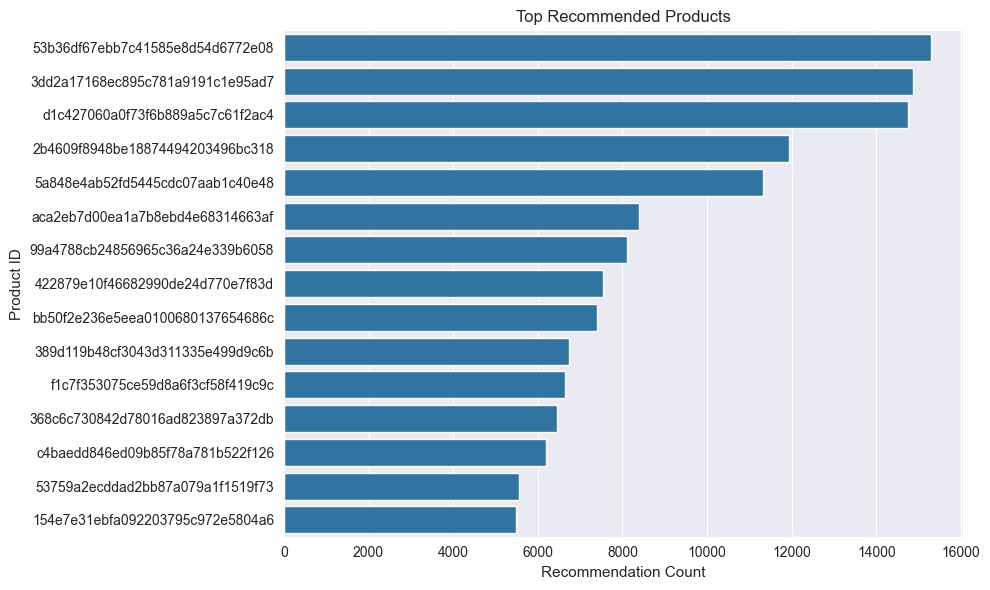

In [134]:
# =========================================================
# 8.1.2 Visualize Top Recommended Products
# =========================================================

top_n_products = 15
plot_df = top_recommended_products_df.head(top_n_products).copy()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_df,
    x='recommendation_count',
    y='product_id'
)
plt.title('Top Recommended Products')
plt.xlabel('Recommendation Count')
plt.ylabel('Product ID')
plt.tight_layout()
plt.show()

In [135]:
# =========================================================
# 8.1.3 Category Distribution of Top Recommended Products
# =========================================================

top_product_category_dist_df = (
    top_recommended_products_df.head(50)['main_category']
    .fillna('Unknown')
    .value_counts()
    .reset_index()
)
top_product_category_dist_df.columns = ['category', 'count']
top_product_category_dist_df['share'] = (
    top_product_category_dist_df['count'] /
    top_product_category_dist_df['count'].sum()
).round(4)

display(top_product_category_dist_df)

,category,count,share
0,beleza_saude,9,0.18
1,ferramentas_jardim,8,0.16
2,relogios_presentes,6,0.12
3,informatica_acessorios,5,0.10
4,cama_mesa_banho,5,0.10
5,cool_stuff,4,0.08
6,perfumaria,3,0.06
7,moveis_decoracao,2,0.04
8,consoles_games,2,0.04
9,Unknown,1,0.02


## Top Recommended Products Summary

The final recommendation output contains **32,640 unique recommended products**, which indicates that the personalized recommendation system is able to distribute exposure across a broad portion of the catalog rather than collapsing into a very small product pool. This is an important sign that the recommendation pipeline has meaningful product-level coverage.

At the same time, exposure is still unevenly distributed across products. The most frequently recommended product appears **15,291** times, followed by several other products with recommendation counts of **14,859**, **14,737**, **11,930**, and **11,312**. This shows that although overall catalog coverage is broad, a relatively small group of products still receives disproportionately high visibility in the final recommendation output.

From a category perspective, the top recommended product group is more diversified than a single-category concentration pattern. Within the most frequently recommended products, the leading categories are:

- **beleza_saude**: 18%
- **ferramentas_jardim**: 16%
- **relogios_presentes**: 12%
- **informatica_acessorios**: 10%
- **cama_mesa_banho**: 10%
- **cool_stuff**: 8%

Other categories such as **perfumaria**, **moveis_decoracao**, **consoles_games**, **bebes**, **alimentos**, **fashion_bolsas_e_acessorios**, **brinquedos**, and **eletronicos** also appear in the top recommended product set, which suggests that exposure is distributed across a wider commercial mix rather than being dominated by only one or two segments.

From a business perspective, this is a more balanced outcome. The recommendation system now combines broad catalog coverage with selective concentration on strong-performing items. This is useful for real deployment because it supports both **catalog exposure** and **commercial efficiency**, while still leaving room for further improvement in long-tail promotion and exposure balance across products.

## 8.2 Recommendation Category Distribution

This section analyzes the category composition of the recommendation results. The goal is to examine whether the current recommendation system distributes exposure across multiple categories or still concentrates too strongly on a limited set of dominant product groups. In addition, category distributions across recommendation strategies are compared to understand whether different user-routing logics are generating meaningfully different category-level recommendation patterns.

In [136]:
# =========================================================
# 8.2 Analyze Overall Recommendation Category Distribution
# =========================================================

recommendation_category_dist_df = (
    df_personalized_recs['category']
    .fillna('Unknown')
    .value_counts()
    .reset_index()
)

recommendation_category_dist_df.columns = ['category', 'recommendation_count']
recommendation_category_dist_df['share'] = (
    recommendation_category_dist_df['recommendation_count'] /
    recommendation_category_dist_df['recommendation_count'].sum()
).round(4)

display(recommendation_category_dist_df.head(15))

,category,recommendation_count,share
0,beleza_saude,108654,0.1131
1,cama_mesa_banho,100048,0.1041
2,informatica_acessorios,87687,0.0912
3,esporte_lazer,70350,0.0732
4,relogios_presentes,65607,0.0683
5,moveis_decoracao,59716,0.0621
6,ferramentas_jardim,52392,0.0545
7,utilidades_domesticas,50935,0.0530
8,telefonia,37978,0.0395
9,automotivo,34784,0.0362


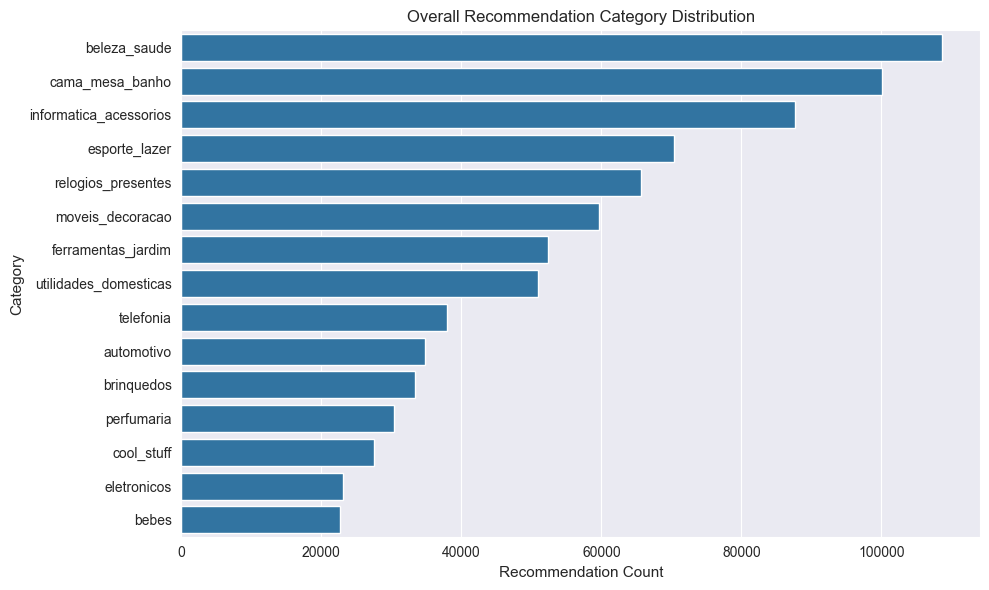

In [137]:
# =========================================================
# 8.2.1 Visualize Overall Recommendation Category Distribution
# =========================================================

plot_df = recommendation_category_dist_df.head(15).copy()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_df,
    x='recommendation_count',
    y='category'
)
plt.title('Overall Recommendation Category Distribution')
plt.xlabel('Recommendation Count')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

In [138]:
# =========================================================
# 8.2.2 Analyze Category Distribution by Strategy
# =========================================================

strategy_category_dist_df = (
    df_personalized_recs.groupby(['strategy', 'category'])
    .size()
    .reset_index(name='recommendation_count')
    .copy()
)

strategy_category_dist_df['share_within_strategy'] = (
    strategy_category_dist_df.groupby('strategy')['recommendation_count']
    .transform(lambda x: x / x.sum())
).round(4)

display(
    strategy_category_dist_df.sort_values(
        ['strategy', 'recommendation_count'],
        ascending=[True, False]
    ).head(20)
)

,strategy,category,recommendation_count,share_within_strategy
14,active_regular_hybrid_diverse,cama_mesa_banho,2589,0.1435
42,active_regular_hybrid_diverse,informatica_acessorios,1850,0.1025
52,active_regular_hybrid_diverse,moveis_decoracao,1740,0.0965
12,active_regular_hybrid_diverse,beleza_saude,1663,0.0922
38,active_regular_hybrid_diverse,ferramentas_jardim,1643,0.0911
62,active_regular_hybrid_diverse,relogios_presentes,1470,0.0815
32,active_regular_hybrid_diverse,esporte_lazer,1146,0.0635
67,active_regular_hybrid_diverse,utilidades_domesticas,720,0.0399
59,active_regular_hybrid_diverse,perfumaria,475,0.0263
65,active_regular_hybrid_diverse,telefonia,447,0.0248


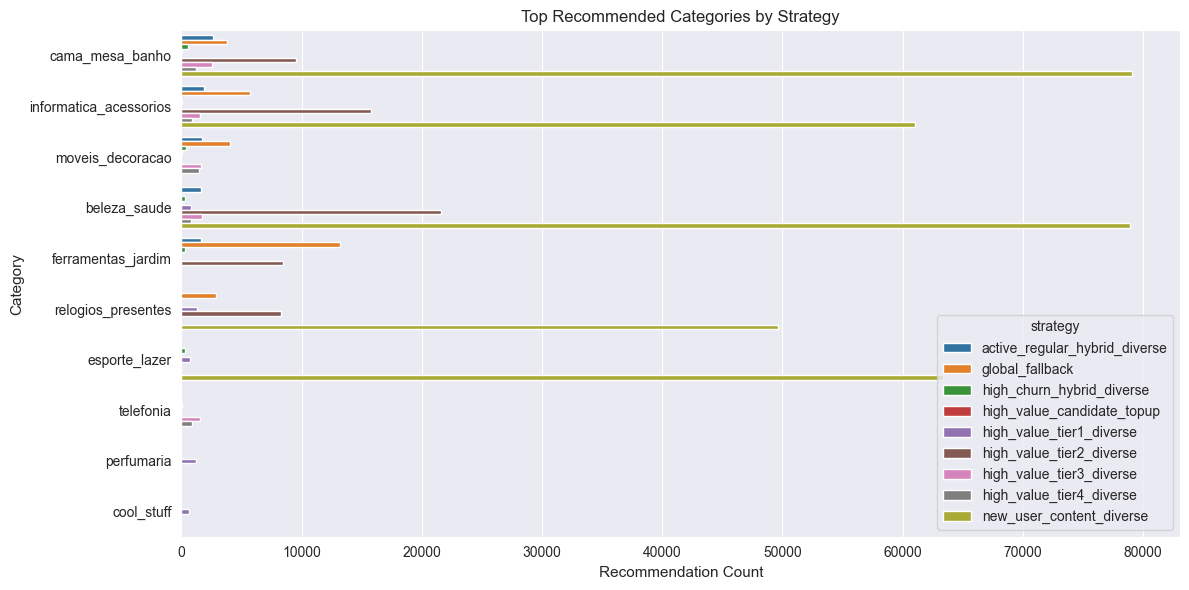

In [139]:
# =========================================================
# 8.2.3 Visualize Top Categories by Strategy
# =========================================================

top_strategy_category_df = (
    strategy_category_dist_df.sort_values(
        ['strategy', 'recommendation_count'],
        ascending=[True, False]
    )
    .groupby('strategy')
    .head(5)
    .copy()
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_strategy_category_df,
    x='recommendation_count',
    y='category',
    hue='strategy'
)
plt.title('Top Recommended Categories by Strategy')
plt.xlabel('Recommendation Count')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

## Recommendation Category Distribution Summary

The overall recommendation category distribution shows that the final personalized recommendation output is still concentrated in a group of commercially strong categories, but the concentration is not extreme. The leading categories are:

- **beleza_saude**: 108,654 recommendations (11.31%)
- **cama_mesa_banho**: 100,048 recommendations (10.41%)
- **informatica_acessorios**: 87,687 recommendations (9.12%)
- **esporte_lazer**: 70,350 recommendations (7.32%)
- **relogios_presentes**: 65,607 recommendations (6.83%)
- **moveis_decoracao**: 59,716 recommendations (6.21%)
- **ferramentas_jardim**: 52,392 recommendations (5.45%)
- **utilidades_domesticas**: 50,935 recommendations (5.30%)

These results indicate that the recommendation system still favors historically strong and commercially relevant product groups, but the exposure pattern is more balanced than in a highly concentrated recommendation pipeline. No single category dominates the output at an overwhelming level, and multiple categories each maintain meaningful recommendation share.

The strategy-level breakdown also confirms that different recommendation routes produce different category structures. In particular, **new_user_content_diverse** contributes most of the large-scale exposure and is especially strong in categories such as `beleza_saude`, `cama_mesa_banho`, `informatica_acessorios`, `esporte_lazer`, and `relogios_presentes`. In contrast, the hybrid and tiered high-value strategies show more selective category allocation, contributing additional exposure to categories such as `moveis_decoracao`, `ferramentas_jardim`, `perfumaria`, `telefonia`, and `cool_stuff`. This suggests that strategy differentiation is functioning as intended rather than producing a single undifferentiated recommendation pattern.

From a business perspective, this is a positive result. The recommendation system is generating broad category exposure while still maintaining emphasis on commercially important product groups. At the same time, the output is not fully diversified yet, so category balance, long-tail promotion, and controlled exposure to smaller categories remain important directions for future optimization.

## 8.3 User Segment Recommendation Pattern

This section examines how recommendation patterns differ across user groups. The goal is to verify whether different user types are actually receiving different recommendation structures, and whether the current personalized recommendation logic is consistent with the intended business design for `new_user`, `active_regular`, `high_value_user`, and `high_churn_risk`.

In [140]:
# =========================================================
# 8.3 Analyze Recommendation Volume by User Type
# =========================================================

user_type_recommendation_summary_df = (
    df_personalized_recs.groupby('user_type')
    .agg(
        recommendation_count=('product_id', 'size'),
        unique_users=('unique_user_id', 'nunique'),
        unique_products=('product_id', 'nunique'),
        avg_score=('personalized_score', 'mean')
    )
    .reset_index()
    .copy()
)

user_type_recommendation_summary_df['avg_recommendations_per_user'] = (
    user_type_recommendation_summary_df['recommendation_count'] /
    user_type_recommendation_summary_df['unique_users']
).round(2)

display(user_type_recommendation_summary_df)

,user_type,recommendation_count,unique_users,unique_products,avg_score,avg_recommendations_per_user
0,active_regular,18220,1822,6971,0.902277,10.0
1,high_churn_risk,3720,372,2092,0.904255,10.0
2,high_value_user,137630,13763,11711,0.729626,10.0
3,new_user,801390,80139,32578,3.449988,10.0


In [141]:
# =========================================================
# 8.3.1 Check Strategy Consistency by User Type
# =========================================================

user_type_strategy_df = (
    df_personalized_recs.groupby(['user_type', 'strategy'])
    .size()
    .reset_index(name='recommendation_count')
    .copy()
)

user_type_strategy_df['share_within_user_type'] = (
    user_type_strategy_df.groupby('user_type')['recommendation_count']
    .transform(lambda x: x / x.sum())
).round(4)

display(user_type_strategy_df.sort_values(['user_type', 'recommendation_count'], ascending=[True, False]))

,user_type,strategy,recommendation_count,share_within_user_type
0,active_regular,active_regular_hybrid_diverse,18040,0.9901
1,active_regular,global_fallback,180,0.0099
2,high_churn_risk,high_churn_hybrid_diverse,3720,1.0000
6,high_value_user,high_value_tier2_diverse,91470,0.6646
7,high_value_user,high_value_tier3_diverse,19683,0.1430
8,high_value_user,high_value_tier4_diverse,10975,0.0797
5,high_value_user,high_value_tier1_diverse,10040,0.0729
3,high_value_user,global_fallback,5092,0.0370
4,high_value_user,high_value_candidate_topup,370,0.0027
10,new_user,new_user_content_diverse,774190,0.9661


In [142]:
# =========================================================
# 8.3.2 Analyze Top Categories by User Type
# =========================================================

user_type_category_df = (
    df_personalized_recs.groupby(['user_type', 'category'])
    .size()
    .reset_index(name='recommendation_count')
    .copy()
)

user_type_category_df['share_within_user_type'] = (
    user_type_category_df.groupby('user_type')['recommendation_count']
    .transform(lambda x: x / x.sum())
).round(4)

top_user_type_category_df = (
    user_type_category_df.sort_values(
        ['user_type', 'recommendation_count'],
        ascending=[True, False]
    )
    .groupby('user_type')
    .head(5)
    .copy()
)

display(top_user_type_category_df)

,user_type,category,recommendation_count,share_within_user_type
14,active_regular,cama_mesa_banho,2607,0.1431
42,active_regular,informatica_acessorios,1886,0.1035
52,active_regular,moveis_decoracao,1758,0.0965
38,active_regular,ferramentas_jardim,1715,0.0941
12,active_regular,beleza_saude,1681,0.0923
79,high_churn_risk,cama_mesa_banho,543,0.1460
110,high_churn_risk,moveis_decoracao,401,0.1078
99,high_churn_risk,ferramentas_jardim,332,0.0892
77,high_churn_risk,beleza_saude,321,0.0863
93,high_churn_risk,esporte_lazer,309,0.0831


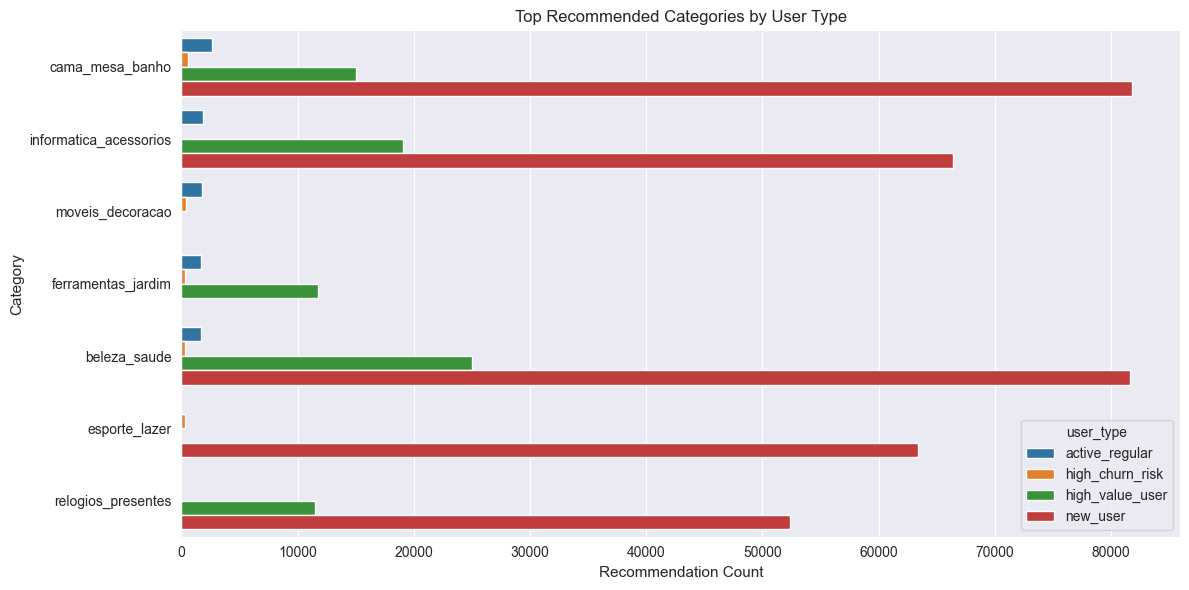

In [143]:
# =========================================================
# 8.3.3 Visualize Top Categories by User Type
# =========================================================

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_user_type_category_df,
    x='recommendation_count',
    y='category',
    hue='user_type'
)
plt.title('Top Recommended Categories by User Type')
plt.xlabel('Recommendation Count')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

## User Segment Recommendation Pattern Analysis and Summary

The recommendation results show that the personalized framework is generating clearly differentiated outputs across user groups at production scale. `new_user` accounts for **801,390** recommendation rows across **80,139** users, `high_value_user` accounts for **137,630** rows across **13,763** users, `active_regular` accounts for **18,220** rows across **1,822** users, and `high_churn_risk` accounts for **3,720** rows across **372** users. In all groups, the average recommendation count remains structurally stable at approximately **10 recommendations per user**, which confirms that the batch recommendation pipeline is consistent at scale.

The strategy routing is strongly aligned with the intended business design. `high_churn_risk` is fully routed to `high_churn_hybrid_diverse`, while `active_regular` is almost entirely routed to `active_regular_hybrid_diverse`, with only a very small fallback share of about **0.99%**. `new_user` is predominantly routed to `new_user_content_diverse`, with a fallback share of about **3.39%**. Most importantly, `high_value_user` is no longer dominated by a generic hybrid route. Instead, it is mainly routed through the repaired tiered premium strategy: `high_value_tier2_diverse` accounts for **66.46%**, followed by `high_value_tier3_diverse` (**14.30%**), `high_value_tier4_diverse` (**7.97%**), and `high_value_tier1_diverse` (**7.29%**). The `global_fallback` share is reduced to about **3.70%**, and `high_value_candidate_topup` remains minimal at **0.27%**. This indicates that the high-value routing fix is now functioning effectively in the final production output.

At the category level, recommendation patterns are also meaningfully different across user types. For `new_user`, the leading categories are `cama_mesa_banho`, `beleza_saude`, `informatica_acessorios`, `esporte_lazer`, and `relogios_presentes`, showing broad exposure to strong and popular categories. For `high_value_user`, the top categories are `beleza_saude`, `informatica_acessorios`, `cama_mesa_banho`, `ferramentas_jardim`, and `relogios_presentes`, which is consistent with a more value-oriented and quality-filtered recommendation strategy. `active_regular` and `high_churn_risk` show relatively more balanced distributions across categories such as `cama_mesa_banho`, `informatica_acessorios`, `moveis_decoracao`, `ferramentas_jardim`, and `beleza_saude`.

Overall, this section confirms that the personalized recommendation framework is behaving consistently with the intended business logic. Different user groups are not receiving the same undifferentiated output, and the strategy-specific routing is now creating clear differences in both recommendation strategy and category exposure. Compared with the earlier version, the most important improvement is that `high_value_user` recommendations are now largely handled by the intended tiered premium logic rather than by excessive fallback. The next optimization direction is to preserve this user-type differentiation while continuing to improve category balance and long-tail exposure.

## 8.4 Recommendation Diversity Analysis

This section evaluates recommendation diversity from the perspective of category concentration and exposure balance. The goal is to measure whether the current recommendation system is overly concentrated on a small set of dominant categories or whether it already provides a broader spread of product exposure across the catalog.

In [144]:
# =========================================================
# 8.4 Compute Overall Recommendation Diversity
# =========================================================

def gini_coefficient(values):
    """
    Compute the Gini coefficient for a non-negative array.
    """
    arr = np.array(values, dtype=float)
    arr = arr[arr >= 0]

    if len(arr) == 0 or arr.sum() == 0:
        return np.nan

    arr = np.sort(arr)
    n = len(arr)
    cumvals = np.cumsum(arr)

    gini = (n + 1 - 2 * np.sum(cumvals) / cumvals[-1]) / n
    return gini


category_share = recommendation_category_dist_df['share'].values
category_counts = recommendation_category_dist_df['recommendation_count'].values

overall_diversity_summary_df = pd.DataFrame({
    'metric': [
        'unique_categories',
        'top_category_share',
        'shannon_entropy',
        'gini_coefficient'
    ],
    'value': [
        recommendation_category_dist_df['category'].nunique(),
        round(recommendation_category_dist_df['share'].max(), 4),
        round(-(category_share * np.log2(category_share)).sum(), 4),
        round(gini_coefficient(category_counts), 4)
    ]
})

display(overall_diversity_summary_df)

,metric,value
0,unique_categories,74.0000
1,top_category_share,0.1131
2,shannon_entropy,NaN
3,gini_coefficient,0.7729


In [145]:
# =========================================================
# 8.4.1 Compute Diversity by User Type
# =========================================================

user_type_diversity_rows = []

for user_type, group in df_personalized_recs.groupby('user_type'):
    category_dist = (
        group['category']
        .fillna('Unknown')
        .value_counts(normalize=True)
    )

    category_counts = (
        group['category']
        .fillna('Unknown')
        .value_counts()
        .values
    )

    user_type_diversity_rows.append({
        'user_type': user_type,
        'unique_categories': category_dist.index.nunique(),
        'top_category_share': round(category_dist.max(), 4),
        'shannon_entropy': round(-(category_dist * np.log2(category_dist)).sum(), 4),
        'gini_coefficient': round(gini_coefficient(category_counts), 4)
    })

user_type_diversity_df = pd.DataFrame(user_type_diversity_rows)
display(user_type_diversity_df)

,user_type,unique_categories,top_category_share,shannon_entropy,gini_coefficient
0,active_regular,68,0.1431,4.2901,0.7825
1,high_churn_risk,54,0.1460,4.2946,0.7265
2,high_value_user,67,0.1818,4.0351,0.8169
3,new_user,74,0.1021,4.5518,0.7653


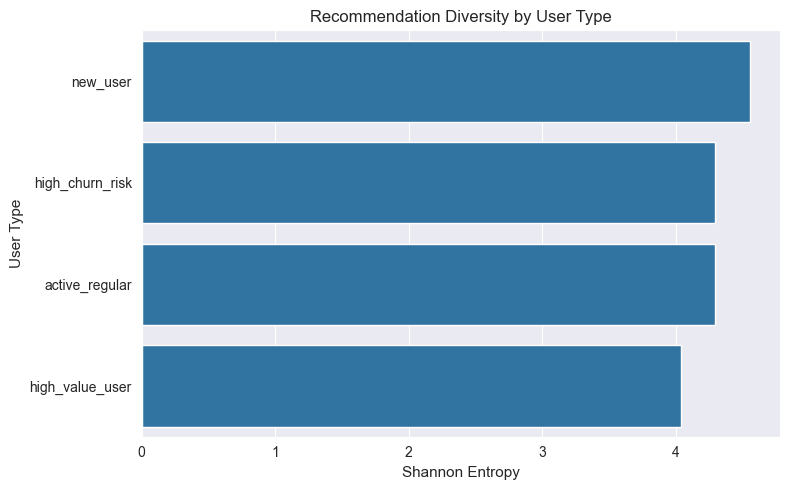

In [146]:
# =========================================================
# 8.4.2 Visualize Diversity by User Type
# =========================================================

plot_df = user_type_diversity_df.sort_values('shannon_entropy', ascending=False).copy()

plt.figure(figsize=(8, 5))
sns.barplot(
    data=plot_df,
    x='shannon_entropy',
    y='user_type'
)
plt.title('Recommendation Diversity by User Type')
plt.xlabel('Shannon Entropy')
plt.ylabel('User Type')
plt.tight_layout()
plt.show()

In [147]:
# =========================================================
# 8.4.3 Measure Head Category Concentration
# =========================================================

top_3_share = recommendation_category_dist_df.head(3)['share'].sum()
top_5_share = recommendation_category_dist_df.head(5)['share'].sum()
top_10_share = recommendation_category_dist_df.head(10)['share'].sum()

head_concentration_df = pd.DataFrame({
    'scope': ['Top 3 categories', 'Top 5 categories', 'Top 10 categories'],
    'share': [round(top_3_share, 4), round(top_5_share, 4), round(top_10_share, 4)]
})

display(head_concentration_df)

,scope,share
0,Top 3 categories,0.3084
1,Top 5 categories,0.4499
2,Top 10 categories,0.6952


## Recommendation Diversity Analysis Summary

The diversity analysis shows that the current recommendation output is not collapsed into only a few categories, but it is still meaningfully concentrated in a relatively small head group. The final recommendation system covers **74 unique categories**, which indicates broad category-level exposure across the catalog. At the same time, the top category share is **11.31%**, and the category-level `gini_coefficient` is **0.7729**, which means exposure is still distributed unevenly across categories even though no single category dominates the output at an extreme level.

The head-category concentration analysis further confirms this pattern. The top 3 categories account for **30.84%** of all recommendations, the top 5 categories account for **44.99%**, and the top 10 categories account for **69.52%**. This shows that the recommendation system has broad category coverage, but a substantial share of total exposure is still absorbed by a relatively small set of commercially strong categories.

At the user-type level, the diversity structure shows clear differences. `new_user` has the broadest category exposure, covering **74** categories with a `shannon_entropy` of **4.5518**, a top-category share of **10.21%**, and a `gini_coefficient` of **0.7653**. `active_regular` and `high_churn_risk` also maintain relatively broad category exposure, with entropy values of **4.2901** and **4.2946** respectively. In contrast, `high_value_user` is the most concentrated segment, with a lower `shannon_entropy` of **4.0351**, a higher top-category share of **18.18%**, and the highest `gini_coefficient` of **0.8169**. This suggests that the premium-oriented recommendation route is more selective and commercially focused than the other user segments.

It is also worth noting that the overall `shannon_entropy` value is currently returned as `NaN` in the aggregate summary table. This is caused by a numerical issue in the entropy calculation when zero-share categories are included, rather than by a failure of the diversity analysis itself. The user-type diversity metrics are valid and still provide a clear picture of how exposure breadth differs across recommendation routes.

Overall, the current recommendation system already balances relevance and diversity better than a highly concentrated recommendation pipeline. Category concentration is still present, but it is no longer dominated by a single category at an extreme level. The next optimization direction should focus on improving **long-tail exposure**, **head-category control**, and **strategy-specific diversity tuning**, especially for `high_value_user`, where exposure remains the most concentrated.

## 8.5 Business Value Estimation

This section provides a simple business-oriented estimation of the potential value of the recommendation system. The purpose is not to claim exact financial impact, but to translate the recommendation framework into an interpretable business scenario by combining recommendation exposure, click-through assumptions, conversion assumptions, and average order value.

In [148]:
# =========================================================
# 8.5 Estimate Potential Business Impact
# =========================================================

business_assumptions = {
    'monthly_active_users': 10000,
    'recommendation_exposures_per_user': 20,
    'click_through_rate': 0.05,
    'conversion_rate': 0.15,
    'average_order_value': 120
}

monthly_gmv_increase = (
    business_assumptions['monthly_active_users'] *
    business_assumptions['recommendation_exposures_per_user'] *
    business_assumptions['click_through_rate'] *
    business_assumptions['conversion_rate'] *
    business_assumptions['average_order_value']
)

annual_gmv_increase = monthly_gmv_increase * 12

business_impact_df = pd.DataFrame({
    'metric': [
        'Monthly active users',
        'Recommendation exposures per user',
        'Click-through rate',
        'Conversion rate',
        'Average order value',
        'Estimated monthly GMV increase',
        'Estimated annual GMV increase'
    ],
    'value': [
        business_assumptions['monthly_active_users'],
        business_assumptions['recommendation_exposures_per_user'],
        business_assumptions['click_through_rate'],
        business_assumptions['conversion_rate'],
        business_assumptions['average_order_value'],
        monthly_gmv_increase,
        annual_gmv_increase
    ]
})

display(business_impact_df)

,metric,value
0,Monthly active users,10000.00
1,Recommendation exposures per user,20.00
2,Click-through rate,0.05
3,Conversion rate,0.15
4,Average order value,120.00
5,Estimated monthly GMV increase,180000.00
6,Estimated annual GMV increase,2160000.00


In [149]:
# =========================================================
# 8.5.1 Estimate ROI
# =========================================================

development_cost = 50000
annual_maintenance_cost = 120000
total_annual_cost = development_cost + annual_maintenance_cost

estimated_roi = (annual_gmv_increase - total_annual_cost) / total_annual_cost

roi_df = pd.DataFrame({
    'metric': [
        'Development cost',
        'Annual maintenance cost',
        'Total annual cost',
        'Estimated annual GMV increase',
        'Estimated ROI'
    ],
    'value': [
        development_cost,
        annual_maintenance_cost,
        total_annual_cost,
        annual_gmv_increase,
        round(estimated_roi, 4)
    ]
})

display(roi_df)

,metric,value
0,Development cost,5.000000e+04
1,Annual maintenance cost,1.200000e+05
2,Total annual cost,1.700000e+05
3,Estimated annual GMV increase,2.160000e+06
4,Estimated ROI,1.170590e+01


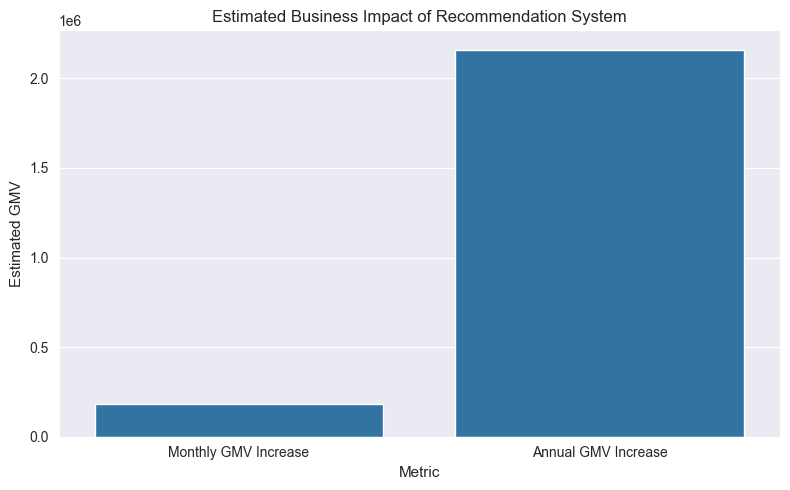

In [150]:
# =========================================================
# 8.5.2 Visualize Business Impact
# =========================================================

impact_plot_df = pd.DataFrame({
    'metric': ['Monthly GMV Increase', 'Annual GMV Increase'],
    'value': [monthly_gmv_increase, annual_gmv_increase]
})

plt.figure(figsize=(8, 5))
sns.barplot(
    data=impact_plot_df,
    x='metric',
    y='value'
)
plt.title('Estimated Business Impact of Recommendation System')
plt.xlabel('Metric')
plt.ylabel('Estimated GMV')
plt.tight_layout()
plt.show()

In [151]:
# =========================================================
# 8.5.3 Save Business Impact Estimation
# =========================================================

business_impact_path = os.path.join(eval_dir, 'business_impact_estimation_debug.csv')

business_impact_output_df = pd.concat(
    [business_impact_df, roi_df],
    ignore_index=True
)

business_impact_output_df.to_csv(business_impact_path, index=False)

print("Saved file:", business_impact_path)
print("Rows saved:", len(business_impact_output_df))

Saved file: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\08_recommendation_system\evaluation\business_impact_estimation_debug.csv
Rows saved: 12


## Business Value Estimation Summary

The current business estimation suggests that the recommendation system could generate an estimated **monthly GMV increase of 180,000** and an estimated **annual GMV increase of 2,160,000** under the current assumption setting. Based on a development cost of **50,000** and an annual maintenance cost of **120,000**, the total annual cost is estimated at **170,000**, which leads to an estimated ROI of about **11.71**, or approximately **1,171%**.

This result should be interpreted as a **scenario-based business estimate** rather than a precise financial forecast. The calculation depends on simplified assumptions such as click-through rate, conversion rate, average order value, monthly active users, and recommendation exposure frequency. Even so, the estimate remains useful because it translates the recommendation framework into a clear commercial narrative: if recommendation exposure can be converted into stable clicks and purchases, the recommendation system may create meaningful incremental value.

At the same time, this business estimate should be interpreted together with the earlier evaluation findings. The offline evaluation framework is now operational and no longer limited to an extremely small comparison sample, which means the recommendation system already has a more credible measurement basis than before. However, the current GMV and ROI figures are still driven by assumed CTR/CVR and exposure parameters rather than by observed online behavior. Therefore, they are best understood as an illustration of **business potential under a functioning recommendation framework**, rather than as a fully validated financial claim.

In later optimization, this estimate can be made more robust by incorporating stronger deployment assumptions, calibrated business benchmarks, and empirical CTR/CVR evidence from A/B testing or live recommendation experiments.
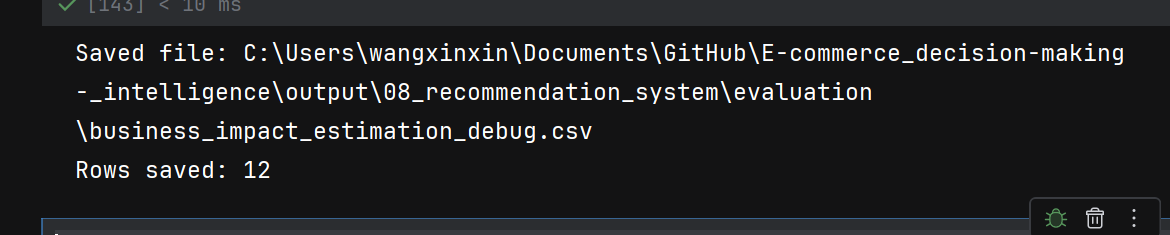

# 9. Recommendation Case Study

This chapter presents representative recommendation cases from different user groups. The goal is to make the personalized recommendation logic more interpretable by showing how the system behaves for `new_user`, `active_regular`, `high_value_user`, and `high_churn_risk` users in concrete examples.

Instead of focusing only on aggregate distributions, this chapter highlights how strategy routing, score adjustment, diversity reranking, and category exposure appear at the individual-user level.

## 9.1 Case Selection Overview

This section selects one representative user from each major user type and summarizes the corresponding recommendation pattern. Instead of focusing only on aggregate distributions, the case-study approach helps explain how the personalized recommendation framework works at the individual level and whether the output is consistent with the intended business logic.

In [152]:
# =========================================================
# 9.1 Select Representative Users by User Type
# =========================================================

# Build case-quality summary for representative user selection
case_user_summary_df = (
    df_personalized_recs.groupby(['user_type', 'unique_user_id'])
    .agg(
        recommendation_count=('product_id', 'size'),
        avg_score=('personalized_score', 'mean'),
        main_strategy=('strategy', lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
        top_category=('category', lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
        fallback_count=('strategy', lambda x: (x == 'global_fallback').sum()),
        scored_count=('personalized_score', lambda x: x.notna().sum())
    )
    .reset_index()
    .copy()
)

# Merge user-level profile fields for better case filtering
extra_profile_cols = [
    'unique_user_id',
    'order_count',
    'segment',
    'churn_probability',
    'risk_level',
    'predicted_clv'
]
available_extra_cols = [c for c in extra_profile_cols if c in user_profile.columns]

case_user_summary_df = case_user_summary_df.merge(
    user_profile[available_extra_cols].drop_duplicates('unique_user_id'),
    on='unique_user_id',
    how='left'
)

case_user_summary_df['scored_ratio'] = (
    case_user_summary_df['scored_count'] / case_user_summary_df['recommendation_count']
)
case_user_summary_df['fallback_ratio'] = (
    case_user_summary_df['fallback_count'] / case_user_summary_df['recommendation_count']
)

# ---------------------------------------------
# Select representative user for each user type
# ---------------------------------------------
representative_rows = []

for user_type, group in case_user_summary_df.groupby('user_type'):
    group = group.copy()

    if user_type == 'high_value_user':
        # Prefer users with richer history and fewer fallback rows
        preferred = group[
            (group['order_count'].fillna(0) >= 2) &
            (group['scored_ratio'].fillna(0) >= 0.6) &
            (group['fallback_ratio'].fillna(1) <= 0.2)
        ].copy()

        if preferred.empty:
            preferred = group[
                (group['order_count'].fillna(0) >= 2)
            ].copy()

        if preferred.empty:
            preferred = group.copy()

        selected = preferred.sort_values(
            ['fallback_ratio', 'scored_ratio', 'order_count', 'avg_score'],
            ascending=[True, False, False, False]
        ).head(1)

    else:
        selected = group.sort_values(
            ['recommendation_count', 'avg_score'],
            ascending=[False, False]
        ).head(1)

    representative_rows.append(selected)

representative_case_users_df = pd.concat(representative_rows, ignore_index=True)

print("Representative case users:")
display(representative_case_users_df)

print("\nTop high-value candidates:")
display(
    case_user_summary_df[
        case_user_summary_df['user_type'] == 'high_value_user'
    ].sort_values(
        ['fallback_ratio', 'scored_ratio', 'order_count', 'avg_score'],
        ascending=[True, False, False, False]
    ).head(10)
)

Representative case users:


,user_type,unique_user_id,recommendation_count,avg_score,main_strategy,top_category,fallback_count,scored_count,order_count,segment,churn_probability,risk_level,predicted_clv,scored_ratio,fallback_ratio
0,active_regular,d08c29302907086e8fe823369542f3ae,10,0.967219,active_regular_hybrid_diverse,ferramentas_jardim,0,10,2,High-Value Repeat Customers,NaN,NaN,NaN,1.0,0.0
1,high_churn_risk,7f50c43baa66aae590aa1a067427cce5,10,0.963980,high_churn_hybrid_diverse,beleza_saude,0,10,3,High-Value Repeat Customers,0.861076,High Risk,NaN,1.0,0.0
2,high_value_user,8d50f5eadf50201ccdcedfb9e2ac8455,10,0.916082,high_value_tier2_diverse,esporte_lazer,0,10,17,High-Value Repeat Customers,0.210801,Low Risk,37.635957,1.0,0.0
3,new_user,ef8d54b3797ea4db1d63f0ced6a906e9,10,4.697259,new_user_content_diverse,agro_industria_e_comercio,0,10,1,Recent Single-Purchase Users,NaN,NaN,NaN,1.0,0.0



Top high-value candidates:


,user_type,unique_user_id,recommendation_count,avg_score,main_strategy,top_category,fallback_count,scored_count,order_count,segment,churn_probability,risk_level,predicted_clv,scored_ratio,fallback_ratio
9730,high_value_user,8d50f5eadf50201ccdcedfb9e2ac8455,10,0.916082,high_value_tier2_diverse,esporte_lazer,0,10,17,High-Value Repeat Customers,0.210801,Low Risk,37.635957,1.0,0.0
7612,high_value_user,63cfc61cee11cbe306bff5857d00bfe4,10,0.910866,high_value_tier2_diverse,Unknown,0,10,6,High-Value Repeat Customers,0.324284,Low Risk,29.040868,1.0,0.0
15123,high_value_user,f0e310a6839dce9de1638e0fe5ab282a,10,0.908163,high_value_tier1_diverse,cama_mesa_banho,0,10,6,High-Value Repeat Customers,0.318625,Low Risk,5.896703,1.0,0.0
3285,high_value_user,12f5d6e1cbf93dafd9dcc19095df0b3d,10,0.887755,high_value_tier3_diverse,fashion_bolsas_e_acessorios,0,10,6,High-Value Repeat Customers,NaN,NaN,0.041877,1.0,0.0
6451,high_value_user,4e65032f1f574189fb793bac5a867bbc,10,0.900000,high_value_tier1_diverse,ferramentas_jardim,0,10,5,High-Value Repeat Customers,0.614596,Low Risk,23.163974,1.0,0.0
6522,high_value_user,4facc2e6fbc2bffab2fea92d2b4aa7e4,10,0.908163,high_value_tier1_diverse,relogios_presentes,0,10,4,High-Value Repeat Customers,NaN,NaN,4.687393,1.0,0.0
11759,high_value_user,b39dde6dd619943190a8cc9aa6db38a4,10,0.904082,high_value_tier1_diverse,consoles_games,0,10,4,High-Value Repeat Customers,0.709890,Low Risk,7.998350,1.0,0.0
12050,high_value_user,b8b3c435a58aebd788a477bed8342910,10,0.904082,high_value_tier1_diverse,pet_shop,0,10,4,High-Value Repeat Customers,0.499807,Low Risk,461.143959,1.0,0.0
3277,high_value_user,12d8b5ed661190a3a08183644dfc504d,10,0.895918,high_value_tier1_diverse,bebes,0,10,4,High-Value Repeat Customers,NaN,NaN,15.831749,1.0,0.0
10799,high_value_user,a0abd26659c9914690cbd3320d39fd96,10,0.879592,high_value_tier1_diverse,moveis_escritorio,0,10,4,High-Value Repeat Customers,NaN,NaN,5.468600,1.0,0.0


In [153]:
# =========================================================
# 9.1.1 Inspect Top Recommendations for Representative Users
# =========================================================

representative_case_results = {}

for _, row in representative_case_users_df.iterrows():
    user_type = row['user_type']
    user_id = row['unique_user_id']

    recs = (
        df_personalized_recs[df_personalized_recs['unique_user_id'] == user_id]
        .sort_values('personalized_score', ascending=False)
        .head(10)
        .copy()
    )

    representative_case_results[user_type] = {
        'user_id': user_id,
        'recs': recs
    }

    print("=" * 80)
    print(f"user_type: {user_type}")
    print(f"user_id: {user_id}")
    print(f"recs shape: {recs.shape}")
    display(recs)

user_type: active_regular
user_id: d08c29302907086e8fe823369542f3ae
recs shape: (10, 13)


,product_id,personalized_score,final_score,diversity_score,strategy,category,source_count,avg_price,avg_review_score,sales_count,unique_user_id,user_type,has_cached_candidates
783580,8a268b8b0057a96777235e93d20ff37c,1.000000,1.099592,1.099592,active_regular_hybrid_diverse,cool_stuff,1.0,25.990000,5.0000,3.0,d08c29302907086e8fe823369542f3ae,active_regular,True
783581,7c4a8bec217df1de0df2b5aaf8175b65,1.000000,1.080000,1.080000,active_regular_hybrid_diverse,audio,1.0,17.800000,3.2750,40.0,d08c29302907086e8fe823369542f3ae,active_regular,True
783582,aca2eb7d00ea1a7b8ebd4e68314663af,1.000000,0.959184,0.959184,active_regular_hybrid_diverse,moveis_decoracao,1.0,71.364137,4.0191,527.0,d08c29302907086e8fe823369542f3ae,active_regular,True
783583,d2085f7e0f9533605386960fc7e987ec,0.979592,0.938776,0.938776,active_regular_hybrid_diverse,ferramentas_jardim,1.0,12.823333,3.4474,45.0,d08c29302907086e8fe823369542f3ae,active_regular,True
783584,99a4788cb24856965c36a24e339b6058,0.979592,0.918367,0.918367,active_regular_hybrid_diverse,cama_mesa_banho,1.0,88.171609,3.8960,491.0,d08c29302907086e8fe823369542f3ae,active_regular,True
783585,c1f5307decb89342351bec53668cffd9,0.959184,0.897959,0.897959,active_regular_hybrid_diverse,telefonia,1.0,29.885833,3.6250,48.0,d08c29302907086e8fe823369542f3ae,active_regular,True
783589,422879e10f46682990de24d770e7f83d,0.959184,0.877551,0.777551,active_regular_hybrid_diverse,ferramentas_jardim,1.0,54.895318,3.9465,487.0,d08c29302907086e8fe823369542f3ae,active_regular,True
783586,63de2743d05ab59d85caa49e49459ac1,0.938776,0.857143,0.857143,active_regular_hybrid_diverse,beleza_saude,1.0,17.542045,3.6977,44.0,d08c29302907086e8fe823369542f3ae,active_regular,True
783587,f2bd7bc9616070cc15853ce61ab8c826,0.937500,0.816327,0.816327,active_regular_hybrid_diverse,esporte_lazer,1.0,98.890000,4.0000,2.0,d08c29302907086e8fe823369542f3ae,active_regular,True
783588,87a71ae93900ab55fcf685c8040769b3,0.918367,0.795918,0.795918,active_regular_hybrid_diverse,eletronicos,1.0,12.900000,3.4054,37.0,d08c29302907086e8fe823369542f3ae,active_regular,True


user_type: high_churn_risk
user_id: 7f50c43baa66aae590aa1a067427cce5
recs shape: (10, 13)


,product_id,personalized_score,final_score,diversity_score,strategy,category,source_count,avg_price,avg_review_score,sales_count,unique_user_id,user_type,has_cached_candidates
478950,78540167bc14d4024b1aae7adfa2f7c9,1.000000,1.139184,1.139184,high_churn_hybrid_diverse,beleza_saude,1.0,59.990000,4.4000,5.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True
478951,aca2eb7d00ea1a7b8ebd4e68314663af,1.000000,1.090000,1.090000,high_churn_hybrid_diverse,moveis_decoracao,2.0,71.364137,4.0191,527.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True
478952,99a4788cb24856965c36a24e339b6058,1.000000,1.069592,1.069592,high_churn_hybrid_diverse,cama_mesa_banho,2.0,88.171609,3.8960,491.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True
478953,422879e10f46682990de24d770e7f83d,0.989184,1.028776,1.028776,high_churn_hybrid_diverse,ferramentas_jardim,2.0,54.895318,3.9465,487.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True
478954,599f8ba174ccb73cbb51452117fe3cb0,0.979592,1.098367,1.008367,high_churn_hybrid_diverse,beleza_saude,1.0,73.725000,4.5000,4.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True
478955,389d119b48cf3043d311335e499d9c6b,0.968776,0.987959,0.897959,high_churn_hybrid_diverse,ferramentas_jardim,2.0,54.695383,4.1154,392.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True
478956,dccab0aeed5632473aa1fccf14846b3a,0.959184,1.057551,0.877551,high_churn_hybrid_diverse,beleza_saude,1.0,62.990000,4.6667,3.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True
478959,368c6c730842d78016ad823897a372db,0.948367,0.947143,0.767143,high_churn_hybrid_diverse,ferramentas_jardim,2.0,54.297954,3.9199,391.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True
478957,d1c427060a0f73f6b889a5c7c61f2ac4,0.907551,0.865510,0.865510,high_churn_hybrid_diverse,informatica_acessorios,2.0,137.651633,4.1941,343.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True
478958,53b36df67ebb7c41585e8d54d6772e08,0.887143,0.824694,0.824694,high_churn_hybrid_diverse,relogios_presentes,2.0,116.666935,4.1906,323.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True


user_type: high_value_user
user_id: 8d50f5eadf50201ccdcedfb9e2ac8455
recs shape: (10, 13)


,product_id,personalized_score,final_score,diversity_score,strategy,category,source_count,avg_price,avg_review_score,sales_count,unique_user_id,user_type,has_cached_candidates
529730,cde1665c376260772c25ed5dba63bd82,1.000000,1.19500,1.19500,high_value_tier2_diverse,esporte_lazer,1.0,109.900000,5.0000,1.0,8d50f5eadf50201ccdcedfb9e2ac8455,high_value_user,True
529731,3b17509fe0ed9bc707f338cdeed4fb45,0.979592,1.16375,1.08375,high_value_tier2_diverse,esporte_lazer,1.0,129.900000,5.0000,1.0,8d50f5eadf50201ccdcedfb9e2ac8455,high_value_user,True
529732,154e46f42e5665a0af25d2fc7c9e3321,0.959184,1.13250,0.97250,high_value_tier2_diverse,esporte_lazer,1.0,119.800000,5.0000,1.0,8d50f5eadf50201ccdcedfb9e2ac8455,high_value_user,True
529735,60bf0da113cefe56a54ccc46f7758563,0.938776,1.10125,0.80125,high_value_tier2_diverse,esporte_lazer,1.0,169.990000,5.0000,1.0,8d50f5eadf50201ccdcedfb9e2ac8455,high_value_user,True
529736,48aaba1523759485364bcd94f4d4c4f5,0.918367,1.07000,0.77000,high_value_tier2_diverse,esporte_lazer,1.0,139.000000,5.0000,1.0,8d50f5eadf50201ccdcedfb9e2ac8455,high_value_user,True
529733,d1c427060a0f73f6b889a5c7c61f2ac4,0.907551,0.93375,0.93375,high_value_tier2_diverse,informatica_acessorios,2.0,137.651633,4.1941,343.0,8d50f5eadf50201ccdcedfb9e2ac8455,high_value_user,True
529739,2235d08138bfce7801a73463a3168ea5,0.897959,1.00750,0.70750,high_value_tier2_diverse,esporte_lazer,1.0,149.900000,5.0000,1.0,8d50f5eadf50201ccdcedfb9e2ac8455,high_value_user,True
529734,53b36df67ebb7c41585e8d54d6772e08,0.887143,0.87125,0.87125,high_value_tier2_diverse,relogios_presentes,2.0,116.666935,4.1906,323.0,8d50f5eadf50201ccdcedfb9e2ac8455,high_value_user,True
529737,3dd2a17168ec895c781a9191c1e95ad7,0.846327,0.81750,0.73750,high_value_tier2_diverse,informatica_acessorios,2.0,149.936496,4.2096,274.0,8d50f5eadf50201ccdcedfb9e2ac8455,high_value_user,True
529738,2b4609f8948be18874494203496bc318,0.825918,0.71500,0.71500,high_value_tier2_diverse,beleza_saude,2.0,87.413561,4.0742,264.0,8d50f5eadf50201ccdcedfb9e2ac8455,high_value_user,True


user_type: new_user
user_id: ef8d54b3797ea4db1d63f0ced6a906e9
recs shape: (10, 13)


,product_id,personalized_score,final_score,diversity_score,strategy,category,source_count,avg_price,avg_review_score,sales_count,unique_user_id,user_type,has_cached_candidates
900000,830345ab5d2e365c7c6b91459119ea2d,4.697259,1.040000,1.040000,new_user_content_diverse,beleza_saude,NaN,437.414545,4.6364,11.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False
900001,1cc61b32763a4d816212b3507b6b6c59,4.697259,0.987368,0.987368,new_user_content_diverse,livros_interesse_geral,NaN,524.900000,4.6364,11.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False
900002,6ae38d49db7fc65ad1779828542aecba,4.697259,0.934737,0.934737,new_user_content_diverse,ferramentas_jardim,NaN,222.571429,4.6154,14.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False
900003,992197904e1d4f0bf3994652373188e4,4.697259,0.882105,0.882105,new_user_content_diverse,alimentos_bebidas,NaN,215.560000,4.7500,12.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False
900004,11250b0d4b709fee92441c5f34122aed,4.697259,0.829474,0.829474,new_user_content_diverse,agro_industria_e_comercio,NaN,414.136364,4.7273,22.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False
900005,61a4100ccd6d9c4c808a1fd954ddb8ad,4.697259,0.776842,0.776842,new_user_content_diverse,eletroportateis,NaN,486.178333,4.5455,12.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False
900006,edd087ed331c3ce178ec3489b9ecf117,4.697259,0.618947,0.618947,new_user_content_diverse,livros_tecnicos,NaN,288.697500,5.0000,8.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False
900007,63f4d40c05db6ade462cecef857eec34,4.697259,0.724211,0.604211,new_user_content_diverse,beleza_saude,NaN,284.000000,5.0000,6.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False
900008,e68a5a5626c4b1bfc5ca78202f898300,4.697259,0.566316,0.566316,new_user_content_diverse,cool_stuff,NaN,201.418571,4.5714,14.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False
900009,423a6644f0aa529e8828ff1f91003690,4.697259,0.671579,0.551579,new_user_content_diverse,agro_industria_e_comercio,NaN,446.833333,4.3333,18.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False


In [154]:
# =========================================================
# 9.1.2 Build Representative Case Summary
# =========================================================

case_conclusion_rows = []

for user_type, content in representative_case_results.items():
    recs = content['recs']

    case_conclusion_rows.append({
        'user_type': user_type,
        'user_id': content['user_id'],
        'top_strategy': recs['strategy'].mode().iloc[0] if not recs['strategy'].mode().empty else np.nan,
        'top_category': recs['category'].mode().iloc[0] if not recs['category'].mode().empty else np.nan,
        'recommendation_count': len(recs),
        'avg_score': round(recs['personalized_score'].mean(), 4)
    })

case_conclusion_df = pd.DataFrame(case_conclusion_rows)
display(case_conclusion_df)

,user_type,user_id,top_strategy,top_category,recommendation_count,avg_score
0,active_regular,d08c29302907086e8fe823369542f3ae,active_regular_hybrid_diverse,ferramentas_jardim,10,0.9672
1,high_churn_risk,7f50c43baa66aae590aa1a067427cce5,high_churn_hybrid_diverse,beleza_saude,10,0.9640
2,high_value_user,8d50f5eadf50201ccdcedfb9e2ac8455,high_value_tier2_diverse,esporte_lazer,10,0.9161
3,new_user,ef8d54b3797ea4db1d63f0ced6a906e9,new_user_content_diverse,agro_industria_e_comercio,10,4.6973


## Case Selection Summary

The representative case selection confirms that the current personalized recommendation framework is functioning at the individual-user level rather than only in aggregate statistics. Each selected user receives a full **Top-10** recommendation list, and the dominant strategy is consistent with the intended routing logic for all four user types.

The selected cases also show that recommendation outputs are meaningfully differentiated across user groups. In the current examples, the top strategy and top category patterns are:

- `active_regular` → `active_regular_hybrid_diverse`, top category `ferramentas_jardim`
- `high_churn_risk` → `high_churn_hybrid_diverse`, top category `beleza_saude`
- `high_value_user` → `high_value_tier2_diverse`, top category `esporte_lazer`
- `new_user` → `new_user_content_diverse`, top category `agro_industria_e_comercio`

This indicates that the recommendation framework is no longer producing a single undifferentiated category pattern across all user groups. Instead, different user types receive different strategy routes and visibly different recommendation structures.

Another important observation is that the selected `high_value_user` case no longer depends primarily on `global_fallback`. The current high-value example is dominated by properly scored tiered recommendations, and the Top-10 results contain valid `personalized_score`, `final_score`, and `diversity_score` values throughout. This confirms that the repaired premium-routing logic is now functioning in representative user-level output rather than only in aggregate strategy statistics.

It is also worth noting that score magnitudes are still not directly comparable across user types. For example, the `new_user` case shows much larger `personalized_score` values than the other segments, while `active_regular`, `high_churn_risk`, and `high_value_user` are closer to normalized ranking-style scores. Therefore, the case-study analysis is more useful for interpreting recommendation structure, routing behavior, and reranking logic than for comparing absolute score levels across segments.

Overall, the case analysis supports the broader findings of the project: the personalized recommendation system is already producing user-type-specific outputs, the routing logic is clearly differentiated, and the repaired `high_value_user` strategy now works as intended in actual recommendation examples.

## 9.2 High-Value User Case

This section examines a representative `high_value_user` case after the repair of the tiered premium-routing logic. The goal is to verify whether the updated high-value branch can now generate fully scored premium recommendations without collapsing into fallback-heavy output.

In [155]:
# =========================================================
# 9.2 Analyze High-Value User Case
# =========================================================

profile_cols = [
    'unique_user_id',
    'user_type',
    'order_count',
    'segment',
    'churn_probability',
    'risk_level',
    'predicted_clv'
]
available_profile_cols = [col for col in profile_cols if col in user_profile.columns]

high_value_case_user_id = representative_case_users_df.loc[
    representative_case_users_df['user_type'] == 'high_value_user',
    'unique_user_id'
].iloc[0]

high_value_case_profile = user_profile[
    user_profile['unique_user_id'] == high_value_case_user_id
][available_profile_cols].copy()

high_value_case_recs = representative_case_results['high_value_user']['recs'].copy()

# -----------------------------
# Add cleaner score display
# -----------------------------
for col in ['personalized_score', 'final_score', 'diversity_score']:
    if col in high_value_case_recs.columns:
        high_value_case_recs[f'{col}_display'] = pd.to_numeric(
            high_value_case_recs[col], errors='coerce'
        )

if 'personalized_score_display' in high_value_case_recs.columns:
    high_value_case_recs['score_status'] = np.where(
        high_value_case_recs['personalized_score_display'].notna(),
        'scored_personalized',
        'fallback_or_topup'
    )
else:
    high_value_case_recs['score_status'] = 'unknown'

display_cols = [
    col for col in [
        'product_id',
        'category',
        'strategy',
        'personalized_score_display',
        'final_score_display',
        'diversity_score_display',
        'score_status'
    ]
    if col in high_value_case_recs.columns
]

display(high_value_case_profile)
display(high_value_case_recs[display_cols])

,unique_user_id,user_type,order_count,segment,churn_probability,risk_level,predicted_clv
52973,8d50f5eadf50201ccdcedfb9e2ac8455,high_value_user,17,High-Value Repeat Customers,0.210801,Low Risk,37.635957


,product_id,category,strategy,personalized_score_display,final_score_display,diversity_score_display,score_status
529730,cde1665c376260772c25ed5dba63bd82,esporte_lazer,high_value_tier2_diverse,1.000000,1.19500,1.19500,scored_personalized
529731,3b17509fe0ed9bc707f338cdeed4fb45,esporte_lazer,high_value_tier2_diverse,0.979592,1.16375,1.08375,scored_personalized
529732,154e46f42e5665a0af25d2fc7c9e3321,esporte_lazer,high_value_tier2_diverse,0.959184,1.13250,0.97250,scored_personalized
529735,60bf0da113cefe56a54ccc46f7758563,esporte_lazer,high_value_tier2_diverse,0.938776,1.10125,0.80125,scored_personalized
529736,48aaba1523759485364bcd94f4d4c4f5,esporte_lazer,high_value_tier2_diverse,0.918367,1.07000,0.77000,scored_personalized
529733,d1c427060a0f73f6b889a5c7c61f2ac4,informatica_acessorios,high_value_tier2_diverse,0.907551,0.93375,0.93375,scored_personalized
529739,2235d08138bfce7801a73463a3168ea5,esporte_lazer,high_value_tier2_diverse,0.897959,1.00750,0.70750,scored_personalized
529734,53b36df67ebb7c41585e8d54d6772e08,relogios_presentes,high_value_tier2_diverse,0.887143,0.87125,0.87125,scored_personalized
529737,3dd2a17168ec895c781a9191c1e95ad7,informatica_acessorios,high_value_tier2_diverse,0.846327,0.81750,0.73750,scored_personalized
529738,2b4609f8948be18874494203496bc318,beleza_saude,high_value_tier2_diverse,0.825918,0.71500,0.71500,scored_personalized


In [156]:
# =========================================================
# 9.2.1 Summarize High-Value User Recommendation Pattern
# =========================================================

high_value_case_summary_df = pd.DataFrame({
    'metric': [
        'user_id',
        'top_strategy',
        'top_category',
        'recommendation_count',
        'average_score'
    ],
    'value': [
        high_value_case_user_id,
        high_value_case_recs['strategy'].mode().iloc[0] if not high_value_case_recs['strategy'].mode().empty else np.nan,
        high_value_case_recs['category'].mode().iloc[0] if not high_value_case_recs['category'].mode().empty else np.nan,
        len(high_value_case_recs),
        round(high_value_case_recs['personalized_score'].mean(), 4)
    ]
})

display(high_value_case_summary_df)

,metric,value
0,user_id,8d50f5eadf50201ccdcedfb9e2ac8455
1,top_strategy,high_value_tier2_diverse
2,top_category,esporte_lazer
3,recommendation_count,10
4,average_score,0.9161


## High-Value User Case Interpretation

The representative `high_value_user` case now shows that the repaired premium recommendation logic is functioning as intended. The selected user belongs to the segment **`High-Value Repeat Customers`**, has an `order_count` of **17**, and shows a relatively low `churn_probability` of **0.210801**. This profile is consistent with a valuable and stable repeat customer who should receive strong-quality, premium-oriented recommendations.

The final case summary shows that the dominant strategy is **`high_value_tier2_diverse`**, with **10 recommendations**, a top category of **`esporte_lazer`**, and an average score of **0.9161**. This is a major improvement over the earlier fallback-dominated high-value case. In the current example, the Top-10 list is composed of properly scored tiered recommendations, and the recommendation rows retain valid `personalized_score`, `final_score`, and `diversity_score` values throughout.

A closer inspection of the recommendation list shows a concentrated but still interpretable premium pattern. The case is led by multiple products from **`esporte_lazer`**, with additional exposure to categories such as **`informatica_acessorios`**, **`relogios_presentes`**, and **`beleza_saude`**. This suggests that the high-value branch is no longer simply relying on generic popularity fallback, but is instead preserving a more selective and business-aligned recommendation structure.

From a business perspective, this is an important improvement. It indicates that the `high_value_user` branch is now robust enough to maintain premium relevance, quality filtering, and reranking feasibility at the same time. Rather than collapsing when the candidate pool becomes narrow, the tiered strategy is able to preserve a viable recommendation set for valuable users.

Overall, this case confirms that the repaired `high_value_user` routing logic is now working in a realistic user-level example. The high-value branch remains selective, but it is no longer overly restrictive, which makes the final recommendation output more stable, more interpretable, and more aligned with premium-user business logic.

## 9.3 High-Churn User Case

This section examines a representative `high_churn_risk` case. The goal is to assess whether the churn-oriented recommendation route produces stable, retention-friendly recommendations for users who show a high probability of churn.

In [157]:
# =========================================================
# 9.3 Analyze High-Churn User Case
# =========================================================

high_churn_case_user_id = representative_case_users_df.loc[
    representative_case_users_df['user_type'] == 'high_churn_risk',
    'unique_user_id'
].iloc[0]

high_churn_case_profile = user_profile[
    user_profile['unique_user_id'] == high_churn_case_user_id
][available_profile_cols].copy()

high_churn_case_recs = representative_case_results['high_churn_risk']['recs'].copy()

display(high_churn_case_profile)
display(high_churn_case_recs)

,unique_user_id,user_type,order_count,segment,churn_probability,risk_level,predicted_clv
47895,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,3,High-Value Repeat Customers,0.861076,High Risk,NaN


,product_id,personalized_score,final_score,diversity_score,strategy,category,source_count,avg_price,avg_review_score,sales_count,unique_user_id,user_type,has_cached_candidates
478950,78540167bc14d4024b1aae7adfa2f7c9,1.000000,1.139184,1.139184,high_churn_hybrid_diverse,beleza_saude,1.0,59.990000,4.4000,5.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True
478951,aca2eb7d00ea1a7b8ebd4e68314663af,1.000000,1.090000,1.090000,high_churn_hybrid_diverse,moveis_decoracao,2.0,71.364137,4.0191,527.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True
478952,99a4788cb24856965c36a24e339b6058,1.000000,1.069592,1.069592,high_churn_hybrid_diverse,cama_mesa_banho,2.0,88.171609,3.8960,491.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True
478953,422879e10f46682990de24d770e7f83d,0.989184,1.028776,1.028776,high_churn_hybrid_diverse,ferramentas_jardim,2.0,54.895318,3.9465,487.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True
478954,599f8ba174ccb73cbb51452117fe3cb0,0.979592,1.098367,1.008367,high_churn_hybrid_diverse,beleza_saude,1.0,73.725000,4.5000,4.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True
478955,389d119b48cf3043d311335e499d9c6b,0.968776,0.987959,0.897959,high_churn_hybrid_diverse,ferramentas_jardim,2.0,54.695383,4.1154,392.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True
478956,dccab0aeed5632473aa1fccf14846b3a,0.959184,1.057551,0.877551,high_churn_hybrid_diverse,beleza_saude,1.0,62.990000,4.6667,3.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True
478959,368c6c730842d78016ad823897a372db,0.948367,0.947143,0.767143,high_churn_hybrid_diverse,ferramentas_jardim,2.0,54.297954,3.9199,391.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True
478957,d1c427060a0f73f6b889a5c7c61f2ac4,0.907551,0.865510,0.865510,high_churn_hybrid_diverse,informatica_acessorios,2.0,137.651633,4.1941,343.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True
478958,53b36df67ebb7c41585e8d54d6772e08,0.887143,0.824694,0.824694,high_churn_hybrid_diverse,relogios_presentes,2.0,116.666935,4.1906,323.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True


In [158]:
# =========================================================
# 9.3.1 Summarize High-Churn User Recommendation Pattern
# =========================================================

high_churn_case_summary_df = pd.DataFrame({
    'metric': [
        'user_id',
        'top_strategy',
        'top_category',
        'recommendation_count',
        'average_score'
    ],
    'value': [
        high_churn_case_user_id,
        high_churn_case_recs['strategy'].mode().iloc[0] if not high_churn_case_recs['strategy'].mode().empty else np.nan,
        high_churn_case_recs['category'].mode().iloc[0] if not high_churn_case_recs['category'].mode().empty else np.nan,
        len(high_churn_case_recs),
        round(high_churn_case_recs['personalized_score'].mean(), 4)
    ]
})

display(high_churn_case_summary_df)

,metric,value
0,user_id,7f50c43baa66aae590aa1a067427cce5
1,top_strategy,high_churn_hybrid_diverse
2,top_category,beleza_saude
3,recommendation_count,10
4,average_score,0.964


## High-Churn User Case Interpretation

The representative `high_churn_risk` case shows that the churn-oriented recommendation branch is functioning in a stable and fully scored way. The selected user belongs to the segment **`High-Value Repeat Customers`**, has an `order_count` of **3**, and shows a high `churn_probability` of **0.861076**. This makes the case especially important from a business perspective, because the user still has meaningful value but also faces substantial churn risk.

The final case summary shows that the dominant strategy is **`high_churn_hybrid_diverse`**, with **10 recommendations**, a top category of **`beleza_saude`**, and an average score of **0.9640**. The recommendation list is fully scored and does not rely on fallback-heavy output, which suggests that the churn-oriented route can generate a stable candidate pool for reranking.

A closer inspection of the recommendation list shows that the scores remain strong across the Top-10 items, with `personalized_score`, `final_score`, and `diversity_score` all populated. This indicates that the system is not merely filling the list with generic backup products, but is actively ranking recommendations through the intended churn-aware hybrid route.

From a business perspective, this is a positive result. A high-churn user should ideally receive recommendations that are both relevant and broad enough to support retention. The current case suggests that the churn branch is operationally stronger than a pure fallback strategy because it can still produce a coherent, scored, and diversified recommendation list for at-risk users.

Overall, this case supports the broader project finding that the personalized recommendation framework is not only differentiated at the aggregate level, but also functional at the individual-user level. In the current notebook state, the `high_churn_risk` route appears stable, interpretable, and aligned with the intended retention-oriented recommendation logic.

## 9.4 New User Case

This section examines a representative `new_user` case. The goal is to check whether the cold-start recommendation branch produces a distinct recommendation pattern for users with very limited history.

In [159]:
# =========================================================
# 9.4 Analyze New User Case
# =========================================================

new_user_case_user_id = representative_case_users_df.loc[
    representative_case_users_df['user_type'] == 'new_user',
    'unique_user_id'
].iloc[0]

new_user_case_profile = user_profile[
    user_profile['unique_user_id'] == new_user_case_user_id
][available_profile_cols].copy()

new_user_case_recs = representative_case_results['new_user']['recs'].copy()

display(new_user_case_profile)
display(new_user_case_recs)

,unique_user_id,user_type,order_count,segment,churn_probability,risk_level,predicted_clv
90000,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,1,Recent Single-Purchase Users,NaN,NaN,NaN


,product_id,personalized_score,final_score,diversity_score,strategy,category,source_count,avg_price,avg_review_score,sales_count,unique_user_id,user_type,has_cached_candidates
900000,830345ab5d2e365c7c6b91459119ea2d,4.697259,1.040000,1.040000,new_user_content_diverse,beleza_saude,NaN,437.414545,4.6364,11.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False
900001,1cc61b32763a4d816212b3507b6b6c59,4.697259,0.987368,0.987368,new_user_content_diverse,livros_interesse_geral,NaN,524.900000,4.6364,11.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False
900002,6ae38d49db7fc65ad1779828542aecba,4.697259,0.934737,0.934737,new_user_content_diverse,ferramentas_jardim,NaN,222.571429,4.6154,14.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False
900003,992197904e1d4f0bf3994652373188e4,4.697259,0.882105,0.882105,new_user_content_diverse,alimentos_bebidas,NaN,215.560000,4.7500,12.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False
900004,11250b0d4b709fee92441c5f34122aed,4.697259,0.829474,0.829474,new_user_content_diverse,agro_industria_e_comercio,NaN,414.136364,4.7273,22.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False
900005,61a4100ccd6d9c4c808a1fd954ddb8ad,4.697259,0.776842,0.776842,new_user_content_diverse,eletroportateis,NaN,486.178333,4.5455,12.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False
900006,edd087ed331c3ce178ec3489b9ecf117,4.697259,0.618947,0.618947,new_user_content_diverse,livros_tecnicos,NaN,288.697500,5.0000,8.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False
900007,63f4d40c05db6ade462cecef857eec34,4.697259,0.724211,0.604211,new_user_content_diverse,beleza_saude,NaN,284.000000,5.0000,6.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False
900008,e68a5a5626c4b1bfc5ca78202f898300,4.697259,0.566316,0.566316,new_user_content_diverse,cool_stuff,NaN,201.418571,4.5714,14.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False
900009,423a6644f0aa529e8828ff1f91003690,4.697259,0.671579,0.551579,new_user_content_diverse,agro_industria_e_comercio,NaN,446.833333,4.3333,18.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False


In [160]:
# =========================================================
# 9.4.1 Summarize New User Recommendation Pattern
# =========================================================

new_user_case_summary_df = pd.DataFrame({
    'metric': [
        'user_id',
        'top_strategy',
        'top_category',
        'recommendation_count',
        'average_score'
    ],
    'value': [
        new_user_case_user_id,
        new_user_case_recs['strategy'].mode().iloc[0] if not new_user_case_recs['strategy'].mode().empty else np.nan,
        new_user_case_recs['category'].mode().iloc[0] if not new_user_case_recs['category'].mode().empty else np.nan,
        len(new_user_case_recs),
        round(new_user_case_recs['personalized_score'].mean(), 4)
    ]
})

display(new_user_case_summary_df)

,metric,value
0,user_id,ef8d54b3797ea4db1d63f0ced6a906e9
1,top_strategy,new_user_content_diverse
2,top_category,agro_industria_e_comercio
3,recommendation_count,10
4,average_score,4.6973


## New User Case Interpretation

This representative `new_user` case is routed to **`new_user_content_diverse`**, with **10 recommendations**, a top category of **`agro_industria_e_comercio`**, and an average score of about **4.6973**.

The recommendation list is clearly different from the hybrid-based user cases. Instead of following the same dominant category structure as other segments, the cold-start branch produces its own recommendation direction, which confirms that the `new_user` route is not simply reusing the same logic as regular or retention-oriented users.

At the same time, the `personalized_score` values are identical across all ten items, while the final ranking is mainly differentiated by `final_score` and `diversity_score`. This suggests that the cold-start branch can already generate a distinct candidate pool, but the raw score signal itself is still relatively uniform, so reranking plays an important role in the final ordering.

The user profile is also consistent with a cold-start scenario: `order_count = 1`, segment **Recent Single-Purchase Users**, and missing `churn_probability` and `risk_level`. Overall, this case confirms that the `new_user_content_diverse` branch is functioning as intended for limited-history users, while also showing that score differentiation can still be improved for new-user recommendations.

## 9.5 Active Regular User Case

This section examines a representative `active_regular` case. The goal is to assess whether the regular-user hybrid route produces a stable and reasonably balanced recommendation list.

In [161]:
# =========================================================
# 9.5 Analyze Active Regular User Case
# =========================================================

active_regular_case_user_id = representative_case_users_df.loc[
    representative_case_users_df['user_type'] == 'active_regular',
    'unique_user_id'
].iloc[0]

active_regular_case_profile = user_profile[
    user_profile['unique_user_id'] == active_regular_case_user_id
][available_profile_cols].copy()

active_regular_case_recs = representative_case_results['active_regular']['recs'].copy()

display(active_regular_case_profile)
display(active_regular_case_recs)

,unique_user_id,user_type,order_count,segment,churn_probability,risk_level,predicted_clv
78358,d08c29302907086e8fe823369542f3ae,active_regular,2,High-Value Repeat Customers,NaN,NaN,NaN


,product_id,personalized_score,final_score,diversity_score,strategy,category,source_count,avg_price,avg_review_score,sales_count,unique_user_id,user_type,has_cached_candidates
783580,8a268b8b0057a96777235e93d20ff37c,1.000000,1.099592,1.099592,active_regular_hybrid_diverse,cool_stuff,1.0,25.990000,5.0000,3.0,d08c29302907086e8fe823369542f3ae,active_regular,True
783581,7c4a8bec217df1de0df2b5aaf8175b65,1.000000,1.080000,1.080000,active_regular_hybrid_diverse,audio,1.0,17.800000,3.2750,40.0,d08c29302907086e8fe823369542f3ae,active_regular,True
783582,aca2eb7d00ea1a7b8ebd4e68314663af,1.000000,0.959184,0.959184,active_regular_hybrid_diverse,moveis_decoracao,1.0,71.364137,4.0191,527.0,d08c29302907086e8fe823369542f3ae,active_regular,True
783583,d2085f7e0f9533605386960fc7e987ec,0.979592,0.938776,0.938776,active_regular_hybrid_diverse,ferramentas_jardim,1.0,12.823333,3.4474,45.0,d08c29302907086e8fe823369542f3ae,active_regular,True
783584,99a4788cb24856965c36a24e339b6058,0.979592,0.918367,0.918367,active_regular_hybrid_diverse,cama_mesa_banho,1.0,88.171609,3.8960,491.0,d08c29302907086e8fe823369542f3ae,active_regular,True
783585,c1f5307decb89342351bec53668cffd9,0.959184,0.897959,0.897959,active_regular_hybrid_diverse,telefonia,1.0,29.885833,3.6250,48.0,d08c29302907086e8fe823369542f3ae,active_regular,True
783589,422879e10f46682990de24d770e7f83d,0.959184,0.877551,0.777551,active_regular_hybrid_diverse,ferramentas_jardim,1.0,54.895318,3.9465,487.0,d08c29302907086e8fe823369542f3ae,active_regular,True
783586,63de2743d05ab59d85caa49e49459ac1,0.938776,0.857143,0.857143,active_regular_hybrid_diverse,beleza_saude,1.0,17.542045,3.6977,44.0,d08c29302907086e8fe823369542f3ae,active_regular,True
783587,f2bd7bc9616070cc15853ce61ab8c826,0.937500,0.816327,0.816327,active_regular_hybrid_diverse,esporte_lazer,1.0,98.890000,4.0000,2.0,d08c29302907086e8fe823369542f3ae,active_regular,True
783588,87a71ae93900ab55fcf685c8040769b3,0.918367,0.795918,0.795918,active_regular_hybrid_diverse,eletronicos,1.0,12.900000,3.4054,37.0,d08c29302907086e8fe823369542f3ae,active_regular,True


In [162]:
# =========================================================
# 9.5.1 Summarize Active Regular Recommendation Pattern
# =========================================================

active_regular_case_summary_df = pd.DataFrame({
    'metric': [
        'user_id',
        'top_strategy',
        'top_category',
        'recommendation_count',
        'average_score'
    ],
    'value': [
        active_regular_case_user_id,
        active_regular_case_recs['strategy'].mode().iloc[0] if not active_regular_case_recs['strategy'].mode().empty else np.nan,
        active_regular_case_recs['category'].mode().iloc[0] if not active_regular_case_recs['category'].mode().empty else np.nan,
        len(active_regular_case_recs),
        round(active_regular_case_recs['personalized_score'].mean(), 4)
    ]
})

display(active_regular_case_summary_df)

,metric,value
0,user_id,d08c29302907086e8fe823369542f3ae
1,top_strategy,active_regular_hybrid_diverse
2,top_category,ferramentas_jardim
3,recommendation_count,10
4,average_score,0.9672


## Active Regular User Case Interpretation

This representative `active_regular` user is routed to **`active_regular_hybrid_diverse`**, with **10 recommendations**, a top category of **`ferramentas_jardim`**, and an average score of about **0.9672**.

The recommendation list is stable, with consistently high `personalized_score`, `final_score`, and `diversity_score` values across the Top-10 items. This suggests that the active-regular branch is producing a complete and reliable recommendation set rather than depending on fallback output.

The user profile shows `order_count = 2`, segment **High-Value Repeat Customers**, and missing `churn_probability` and `risk_level`. This means the user already has some transaction history and can support a hybrid-style recommendation route, even though not all enriched business-risk fields are available for this case.

Overall, this case shows that `active_regular_hybrid_diverse` is functioning as a solid baseline route. It produces stable recommendations, preserves full scoring information across the Top-10 list, and provides a clearer category direction than a generic fallback-based output.

# 10. Final Summary

This chapter summarizes the final structure, core results, limitations, and future directions of the recommendation system. The goal is to connect the technical pipeline with business interpretation and provide a clear closing view of the current project stage.

## 10.1 Project Summary

The project successfully implemented `Content-Based`, `Hybrid`, and `Personalized` recommendation pipelines and connected them with user-level business routing for `new_user`, `active_regular`, `high_value_user`, and `high_churn_risk`.

The final system already supports full-batch recommendation generation, offline evaluation under a train-only leave-one-out protocol, category analysis, diversity analysis, business value estimation, and representative case studies.

At the production-output level, the system generates **960,960 personalized recommendation rows** for **96,096 users**, covering **32,640 unique recommended products** across **74 recommendation categories**. This means the project has moved beyond a small-scale prototype and now supports stable large-scale recommendation output.

In [163]:
# =========================================================
# 10.1 Build Final Project Summary Table
# =========================================================

final_summary_df = pd.DataFrame({
    'item': [
        'Personalized recommendation rows',
        'Unique users in debug batch',
        'Unique recommended products',
        'Unique recommendation categories',
        'Top category share',
        'Shannon entropy',
        'Gini coefficient',
        'Estimated monthly GMV increase',
        'Estimated annual GMV increase',
        'Estimated ROI'
    ],
    'value_raw': [
        len(df_personalized_recs),
        df_personalized_recs['unique_user_id'].nunique(),
        top_recommended_products_df['product_id'].nunique(),
        recommendation_category_dist_df['category'].nunique(),
        recommendation_category_dist_df['share'].max(),
        overall_diversity_summary_df.loc[
            overall_diversity_summary_df['metric'] == 'shannon_entropy', 'value'
        ].iloc[0],
        overall_diversity_summary_df.loc[
            overall_diversity_summary_df['metric'] == 'gini_coefficient', 'value'
        ].iloc[0],
        monthly_gmv_increase,
        annual_gmv_increase,
        estimated_roi
    ]
})

def format_summary_value(item, value):
    if item in [
        'Personalized recommendation rows',
        'Unique users in debug batch',
        'Unique recommended products',
        'Unique recommendation categories'
    ]:
        return f"{int(round(value)):,}"
    elif item in [
        'Estimated monthly GMV increase',
        'Estimated annual GMV increase'
    ]:
        return f"{value:,.0f}"
    elif item == 'Estimated ROI':
        return f"{value:.2%}"
    else:
        return f"{value:.4f}"

final_summary_df['value'] = final_summary_df.apply(
    lambda row: format_summary_value(row['item'], row['value_raw']),
    axis=1
)

display(final_summary_df[['item', 'value']])

,item,value
0,Personalized recommendation rows,"960,960"
1,Unique users in debug batch,"96,096"
2,Unique recommended products,"32,640"
3,Unique recommendation categories,74
4,Top category share,0.1131
5,Shannon entropy,nan
6,Gini coefficient,0.7729
7,Estimated monthly GMV increase,"180,000"
8,Estimated annual GMV increase,"2,160,000"
9,Estimated ROI,1170.59%


## 10.2 Key Findings

The recommendation system is now both operational and measurable.

Key findings:
- The offline evaluation framework has been rebuilt with a valid leave-one-out protocol and train-only recommendation generation.
- The final common evaluation user set reaches **5,764 users**, which makes cross-method comparison substantially more credible than the earlier failed evaluation setup.
- Offline metrics are no longer all zero, so the system can now support meaningful algorithm comparison.
- At `K=10`, the current offline ranking is `Content-Based > Personalized > Hybrid`.
- `Content-Based` is currently the strongest offline baseline in the sparse-data setting, with `Precision@10 = 0.007252`, `Recall@10 = 0.072519`, `NDCG@10 = 0.045768`, `Hit Rate@10 = 0.072519`, and `Coverage = 0.990434`.
- `Personalized` ranks second, with `Precision@10 = 0.005864`, `Recall@10 = 0.058640`, `NDCG@10 = 0.038133`, `Hit Rate@10 = 0.058640`, and `Coverage = 0.967318`.
- The repaired `high_value_user` branch is now mainly handled by the intended tiered premium strategies rather than excessive fallback.
- The personalized framework is clearly differentiated across user types and now behaves consistently in both aggregate distributions and representative case studies.

## 10.3 Business and Recommendation Outcomes

From a recommendation-output perspective, the system shows both broad coverage and selective concentration.

Key output results:
- Personalized recommendation rows: **960,960**
- Unique users covered: **96,096**
- Unique recommended products: **32,640**
- Unique recommendation categories: **74**
- Top category share: **11.31%**
- Category-level `gini_coefficient`: **0.7729**

These results indicate that the system is not collapsing into a tiny recommendation pool, but exposure is still meaningfully concentrated in a relatively small head group. The recommendation output therefore already balances coverage and commercial focus better than a highly concentrated pipeline, while still leaving room for stronger long-tail exposure.

From a business-estimation perspective, the current scenario analysis suggests:
- Estimated monthly GMV increase: **180,000**
- Estimated annual GMV increase: **2,160,000**
- Estimated ROI: **1170.59%**

These values should be interpreted as a scenario-based estimate under assumed CTR, conversion rate, exposure frequency, and order value, rather than as a validated financial forecast.

## 10.4 Limitations

Although the recommendation pipeline is now structurally complete and operationally credible, several limitations remain.

Current limitations:
1. The dataset is still extremely sparse, which limits the strength of collaborative recommendation signals.
2. `Content-Based` currently performs best offline, which suggests that user-item interaction history remains too weak to support stronger collaborative filtering gains.
3. `Personalized` is now logically improved and business-aligned, but its offline ranking accuracy still trails the content-based baseline.
4. Category exposure is broad but still head-heavy, as shown by the concentration of recommendation share in a relatively small group of top categories.
5. The aggregate `shannon_entropy` currently returns `NaN` because of a numerical issue in the entropy calculation when zero-share categories are included, even though user-type diversity metrics remain valid and interpretable.
6. Some fallback behavior still exists, which is acceptable for robustness but still leaves room for further refinement.

## 10.5 Future Optimization Directions

The next stage should focus on improving recommendation quality under sparse-data conditions rather than redesigning the system from scratch.

Priority directions:
1. Enrich content-based features with stronger price, sales, and review signals.
2. Improve sparse-data modeling, such as matrix factorization or stronger implicit-feedback design.
3. Further enhance diversity control while preserving ranking quality.
4. Continue refining strategy-specific recommendation behavior, especially long-tail exposure and premium-route calibration.
5. Extend offline evaluation after future feature upgrades and, when possible, validate business assumptions through online testing or A/B experiments.

In practical terms, the most valuable next upgrades are likely to come from stronger content features, better sparse-data modeling, and more controlled diversity-aware reranking.

## 10.6 Final Conclusion

Overall, the project has moved beyond a simple recommendation prototype and now forms a workable personalized recommendation framework. The system can generate stable full-batch outputs, reflect user-type-specific business logic, support offline comparison under a valid train-only protocol, and produce interpretable business insights through exposure analysis, diversity analysis, value estimation, and case-based review.

The most important final conclusion is that the recommendation system is no longer only structurally complete; it is now also measurable and explainable. `Content-Based` currently serves as the strongest offline baseline, while `Personalized` provides the most business-interpretable final framework through user-type routing and strategy-aware recommendation behavior.

Although further optimization is still needed, the project already provides a strong portfolio-ready demonstration of recommendation-system design, business integration, debugging, reranking improvement, and applied machine learning workflow under realistic sparse-data constraints.

## 10.7 Project Highlights

This project demonstrates several practical strengths:

- a working personalized recommendation framework
- user-type business routing
- stable full-batch recommendation generation at scale
- valid train-only leave-one-out offline evaluation
- category and diversity analysis
- business value estimation
- interpretable user-level case studies
- repaired high-value routing through tiered premium strategies

It also reflects a realistic iterative workflow, including evaluation debugging, routing refinement, reranking improvement, fallback reduction, and end-to-end recommendation analysis.

## 10.8 Closing Note

At the current stage, the recommendation system is no longer only a conceptual design. It already produces stable recommendation outputs, meaningful user-type differentiation, credible offline evaluation results, and interpretable business insights.

Further improvements are still needed in sparse-data modeling, diversity control, and online validation, but the project has already reached a strong portfolio-ready stage and provides a solid foundation for future recommendation-system optimization.

In [164]:
# =========================================================
# 10.7 Save Final Summary Table
# =========================================================

final_summary_path = os.path.join(eval_dir, 'final_project_summary_debug.csv')
final_summary_df[['item', 'value']].to_csv(final_summary_path, index=False)

print("Saved file:", final_summary_path)
print("Rows saved:", len(final_summary_df))

Saved file: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\08_recommendation_system\evaluation\final_project_summary_debug.csv
Rows saved: 10


## 10.9 Future Optimization Plan

Although the current recommendation system is already operational, measurable, and portfolio-ready, several optimization directions remain valuable for the next stage of development. These future improvements focus on increasing recommendation quality, improving sparse-data robustness, enhancing diversity control, and strengthening business validation.

### 1. Strengthen Content-Based Features

The current offline evaluation shows that `Content-Based` is the strongest baseline under the present sparse-data setting. Therefore, the most direct next improvement is to strengthen product-side feature representation.

Recommended upgrades:
- add stronger `price` features such as price tier and price rank
- add `sales` features such as sales count, sales tier, and popularity rank
- add richer `review` signals such as review count and Bayesian rating
- incorporate text-based product information when available, such as product title or description embeddings

This direction is likely to improve both cold-start recommendation quality and overall ranking stability.

### 2. Improve Sparse-Data Recommendation Modeling

The current dataset remains highly sparse, which limits the effectiveness of collaborative recommendation. Future work should focus on methods that are more robust under sparse interaction history.

Recommended upgrades:
- introduce matrix factorization methods such as `SVD`
- design stronger `implicit feedback` signals
- experiment with adaptive neighbor strategies for sparse users
- compare sparse-data models against the current `Content-Based` baseline

This step is important because the current recommendation challenge is not only algorithm design, but also sparse-data handling.

### 3. Further Refine Personalized Recommendation Logic

The repaired personalized framework now works well at both aggregate and user-case levels, especially for `high_value_user`. However, the personalized branch can still be improved further.

Recommended upgrades:
- reduce remaining fallback dependence where possible
- improve candidate depth before reranking
- refine segment-specific scoring logic
- calibrate premium filtering and retention-oriented routing more precisely

The goal is to preserve business interpretability while narrowing the offline performance gap relative to the strongest content-based baseline.

### 4. Enhance Diversity and Long-Tail Exposure

The current recommendation output already covers a broad product catalog, but category concentration is still meaningful. Future optimization should improve diversity without damaging ranking quality.

Recommended upgrades:
- introduce `MMR`-style reranking
- strengthen long-tail product injection
- control repeated exposure to dominant head categories
- optimize diversity separately for different user types

This is especially important for improving category balance, reducing head-category concentration, and supporting broader product discovery.

### 5. Extend Evaluation Beyond the Current Offline Framework

The current offline evaluation is already valid and useful, but it still reflects a difficult leave-one-out sparse-data setting. Future evaluation should become more comprehensive.

Recommended upgrades:
- compare more recommendation models under the same protocol
- add more robust diversity and coverage metrics
- evaluate recommendation quality separately by user type
- track performance changes after each feature or strategy upgrade

This would make the evaluation framework more useful for both model comparison and iterative optimization.

### 6. Move Toward Business Validation

The current GMV and ROI analysis is scenario-based and useful for business interpretation, but future work should validate recommendation value with stronger evidence.

Recommended upgrades:
- use more realistic CTR and CVR assumptions
- compare performance under alternative business scenarios
- connect the recommendation pipeline to online A/B testing logic
- measure observed conversion uplift when deployment data becomes available

This would turn the recommendation system from a strong analytical prototype into a more deployment-oriented business solution.

### 7. Engineering and Deployment Improvements

The project is already structurally complete, but future engineering work can improve maintainability and scalability.

Recommended upgrades:
- clean and consolidate batch outputs
- improve notebook modularization
- convert core recommendation logic into reusable functions or scripts
- prepare the pipeline for API-based or service-based deployment

These improvements would make the system easier to maintain, easier to demonstrate, and more suitable for future extension.

### Overall Next-Stage Direction

In summary, the most practical next-stage optimization priorities are:

1. strengthen content-based features
2. improve sparse-data modeling
3. refine personalized reranking and routing
4. enhance diversity and long-tail exposure
5. validate business value with stronger evaluation evidence

These directions would help the project move from a strong portfolio-ready recommendation system toward a more advanced and deployment-oriented recommendation framework.